In [2]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
# load in appropriate packages
%load_ext autoreload
%autoreload 2
import pyreadstat
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os, sys
from scipy.stats import norm, bernoulli, beta, expon
from ppi_py.datasets import load_dataset
import matplotlib.patheffects as pe
from utils import make_width_coverage_plot, make_width_coverage_split_plot, make_budget_plot
import warnings; warnings.simplefilter('ignore')
import cvxpy as cp
from structuremap.processing import get_smooth_score
from IPython.display import clear_output
from patsy import dmatrix # For generating spline basis
import time
from matplotlib.lines import Line2D

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### spline CVXPY optimization

In [3]:
# compute optimal sampling probabilites 
# given a set of clusters and corresponding uncertainty scores, size of each group, and budget
# counts for group 1 are first in Ns (concatenate N1's and then N0's here)
def sampling_probs_constant(u1s, u0s, mu1, mu0, Ns, n_budget):
    
    # Variables
    n_var = len(Ns)
    n_groups1 = len(u1s)
    n_groups0 = len(u0s)
    xs = cp.Variable(n_var, pos=True)  # Sampling probabilities
    ys = cp.Variable(n_var, pos=True)  # Auxiliary variables
    q = cp.Variable(pos=True)      # Product of all xs

    # Parameters
    n1 = np.sum(Ns[:n_groups1])            # Total for the first group
    n0 = np.sum(Ns[n_groups1:])            # Total for the second group
    coeffs = np.ones(n_var)
    coeffs[:n_groups1] = np.multiply(Ns[:n_groups1], u1s) / (n1**2 * (mu1**2) * (1 - mu1)**2)
    coeffs[n_groups1:] = np.multiply(Ns[n_groups1:], u0s) / (n0**2 * (mu0**2) * (1 - mu0)**2)

    # Objective function: Minimize weighted sum of xs
    objective = cp.Minimize(cp.sum(cp.multiply(coeffs, xs)))

    # Constraints
    constraints = [
        cp.sum(cp.multiply(Ns, ys)) <= n_budget * q,  # Budget constraint
        q == cp.prod(xs),  # q represents the product of all xs
        xs >= 1,  # Ensure xs are >= 1
    ]
    # Add auxiliary constraints for ys
    for i in range(n_var):
        constraints.append(ys[i] == cp.prod(xs[:i]) * cp.prod(xs[i+1:]))

    # Problem definition
    problem = cp.Problem(objective, constraints)

    # Solve the problem in GP mode
    problem.solve(solver=cp.SCS, gp=True)

    # Check for solution
    if problem.status in ["optimal", "optimal_inaccurate"]:
        # Compute sampling probabilities
        probs = np.array([1 / xs[i].value for i in range(n_var)])
        probs1 = probs[:n_groups1]
        probs0 = probs[n_groups1:]
        return probs1, probs0
    else:
        raise ValueError(f"Problem not solved: {problem.status}")

In [4]:
# setup_spline_basis
def setup_spline_basis(uncertainties, num_knots=5, degree=3, name='u'):
    """
    Sets up B-spline basis functions for given uncertainties. 
    """
    if len(uncertainties) == 0:
        return np.zeros((0, 0)), None # Handle empty input
        
    # Ensure enough unique points relative to knots/degree
    unique_uncertainties = np.unique(uncertainties)
    required_unique = degree + 1 
    if len(unique_uncertainties) < required_unique:
         print(f"Warning: Need at least {required_unique} unique uncertainty points for degree {degree} spline, "
               f"found {len(unique_uncertainties)}. Reducing degree or complexity might be needed.")

    if len(unique_uncertainties) < num_knots + 1:
        num_knots = max(0, len(unique_uncertainties) - degree - 1) # Try to leave enough points between knots


    # Define knot locations (e.g., quantiles)
    knot_quantiles = np.linspace(0, 1, num_knots + 2)[1:-1] 
    
    # Handle case where all uncertainties are the same
    if len(unique_uncertainties) == 1:
         knots = np.array([]) # No internal knots
         num_knots = 0 # Force num_knots to 0
         # Use df instead of knots for constant case
         formula = f"bs({name}, df={degree+1}, degree={degree}, include_intercept=True) - 1"
         data = {name: uncertainties}
         try:
              basis_matrix = dmatrix(formula, data, return_type='dataframe')
              return basis_matrix.values, None
         except Exception as e:
             print(f"Patsy error even with df for constant uncertainty: {e}. Returning basic constant basis.")
             # Fallback to a truly constant basis (vector of ones)
             return np.ones((len(uncertainties), 1)), None


    # Proceed with knot calculation for non-constant cases
    if num_knots > 0:
         knots = np.quantile(uncertainties, knot_quantiles)
         knots = np.unique(knots) # Ensure knots are unique
         # Check if knots collapsed or are too close to boundaries
         min_u, max_u = np.min(uncertainties), np.max(uncertainties)
         # Remove knots too close to the boundary? Sometimes helps patsy.
         # knots = knots[(knots > min_u) & (knots < max_u)] 
         if len(knots) < num_knots:
              # print(f"Warning: Number of unique knots reduced to {len(knots)}.")
              pass # Let patsy handle fewer knots
         if len(knots) == 0 and num_knots > 0:
              print("Warning: All internal knots collapsed. Proceeding without internal knots.")
              num_knots = 0 # Update num_knots if they vanished

    else: # num_knots is 0
         knots = np.array([])

    # Create the design matrix using patsy
    # Use bs() for B-splines
    if num_knots > 0:
        formula = f"bs({name}, knots=knots, degree=degree, include_intercept=True) - 1"
    else: # No internal knots, use df
         df = degree + 1 # Number of basis functions for degree d, no internal knots
         formula = f"bs({name}, df={df}, degree={degree}, include_intercept=True) - 1"

    data = {name: uncertainties}
    
    try:
        basis_matrix = dmatrix(formula, data, return_type='dataframe')
    except Exception as e:
         print(f"Patsy error: {e}. Trying simpler df if knots were used.")
         try:
             # Fallback if specific knot creation failed
             df = num_knots + degree + 1 # Total degrees of freedom expected
             formula = f"bs({name}, df={df}, degree={degree}, include_intercept=True) - 1"
             basis_matrix = dmatrix(formula, data, return_type='dataframe')
             knots = None # Knots aren't explicitly defined in this case
         except Exception as e2:
             print(f"Patsy fallback failed: {e2}. Returning basic constant basis.")
             return np.ones((len(uncertainties), 1)), None


    # Check if basis matrix has expected shape
    expected_cols = num_knots + degree + 1 # Intercept is included in the count here
    if basis_matrix.shape[1] == 0 and expected_cols > 0 :
         print(f"Warning: Patsy generated an empty basis matrix ({basis_matrix.shape}). Check inputs/parameters. Returning constant basis.")
         return np.ones((len(uncertainties), 1)), None
         
    return basis_matrix.values, knots # Return as numpy array



In [5]:
def test_setup_spline_basis():
    test_cases = {
        "normal_case": np.linspace(0, 1, 50),
        "few_unique_points": np.array([0.1, 0.1, 0.5, 0.5, 0.9]),
        "constant_values": np.full(10, 0.5),
        "empty_input": np.array([]),
        "nan_input": np.array([0.2, np.nan, 0.5, 0.8, np.nan]),
        "ties_at_boundaries": np.concatenate([np.zeros(10), np.linspace(0, 1, 30), np.ones(10)])
    }

    for name, uncertainties in test_cases.items():
        print(f"\n--- Testing {name} ---")
        
        # Drop NaNs for now (your code doesn't handle NaNs internally)
        uncertainties = uncertainties[~np.isnan(uncertainties)]
        
        basis_matrix, knots = setup_spline_basis(uncertainties, num_knots=5, degree=3, name='u')
        
        print(f"Input size: {len(uncertainties)}")
        print(f"Basis shape: {basis_matrix.shape}")
        print(f"Knots: {knots}")

test_setup_spline_basis()



--- Testing normal_case ---
Input size: 50
Basis shape: (50, 9)
Knots: [0.16666667 0.33333333 0.5        0.66666667 0.83333333]

--- Testing few_unique_points ---
Input size: 5
Basis shape: (5, 4)
Knots: []

--- Testing constant_values ---
Input size: 10
Basis shape: (10, 4)
Knots: None

--- Testing empty_input ---
Input size: 0
Basis shape: (0, 0)
Knots: None

--- Testing nan_input ---
Input size: 3
Basis shape: (3, 4)
Knots: []

--- Testing ties_at_boundaries ---
Input size: 50
Basis shape: (50, 9)
Knots: [0.        0.2183908 0.5       0.7816092 1.       ]


In [6]:
def sampling_probs_spline_inv(u1_all, u0_all, mu1, mu0, n_budget, num_knots=5, degree=3, verbose_solver=False):
    """
    Compute optimal sampling probabilities parametrized by splines on INVERSE probabilities.
    MODIFIED TO PRIORITIZE MOSEK SOLVER.

    Models log(1/p_i) = B(u_i) @ theta, such that 1/p_i >= 1.

    Args:
        u1_all (np.ndarray): Individual uncertainty scores for group 1 points.
        u0_all (np.ndarray): Individual uncertainty scores for group 0 points.
        mu1 (float): Estimated mean for group 1 (used for scaling objective).
        mu0 (float): Estimated mean for group 0 (used for scaling objective).
        n_budget (float): Total expected sample budget.
        num_knots (int): Number of internal knots for the splines.
        degree (int): Degree of the spline polynomials.
        verbose_solver (bool): If True, show detailed solver output.

    Returns:
        tuple: (probs1, probs0, spline_params1, spline_params0)
               probs1 (np.ndarray): Sampling probabilities for group 1 points.
               probs0 (np.ndarray): Sampling probabilities for group 0 points.
               spline_params1 (dict): Info about group 1 spline (coeffs, knots, degree).
               spline_params0 (dict): Info about group 0 spline (coeffs, knots, degree).
        Returns (None, None, None, None) if optimization fails.
    """
    overall_start_time = time.perf_counter()
    n1 = len(u1_all)
    n0 = len(u0_all)

    if n1 == 0 and n0 == 0:
        print("Warning: Both groups are empty.")
        return np.array([]), np.array([]), None, None
    if n_budget <= 0:
         print("Warning: Budget is non-positive. Returning zero probabilities.")
         return np.zeros(n1), np.zeros(n0), None, None

    # --- Setup Spline Basis (Same as before) ---
    B1, knots1 = np.zeros((n1, 0)), None
    B0, knots0 = np.zeros((n0, 0)), None
    n_basis1 = 0
    n_basis0 = 0

    if n1 > 0:
        try:
             B1, knots1 = setup_spline_basis(u1_all, num_knots, degree, name='u1')
             n_basis1 = B1.shape[1]
             if n_basis1 == 0: raise ValueError("Basis matrix is empty")
        except Exception as e:
            print(f"Could not create spline basis for group 1: {e}. Check uncertainty values.")
            n_basis1 = 0 # Ensure it's zero
    if n0 > 0:
        try:
            B0, knots0 = setup_spline_basis(u0_all, num_knots, degree, name='u0')
            n_basis0 = B0.shape[1]
            if n_basis0 == 0: raise ValueError("Basis matrix is empty")
        except Exception as e:
             print(f"Could not create spline basis for group 0: {e}. Check uncertainty values.")
             n_basis0 = 0 # Ensure it's zero

    if n_basis1 == 0 and n_basis0 == 0 and (n1 > 0 or n0 > 0):
         print("Error: Could not create spline basis for either group. Cannot optimize.")
         return None, None, None, None

    # --- CVXPY Optimization
    theta1 = cp.Variable(n_basis1, name="theta1") if n_basis1 > 0 else None
    theta0 = cp.Variable(n_basis0, name="theta0") if n_basis0 > 0 else None

    log_x1, log_x0 = None, None
    x1, x0 = None, None
    p1, p0 = None, None

    constraints = []
    objective_terms = []
    budget_terms = []

    # Group 1 calculations
    if n1 > 0 and n_basis1 > 0 and theta1 is not None and mu1 > 0 and mu1 < 1:
        w1 = u1_all / (n1**2 * (mu1**2) * (1 - mu1)**2)
        log_x1 = B1 @ theta1
        x1 = cp.exp(log_x1)
        p1 = cp.exp(-log_x1)
        objective_terms.append(cp.sum(cp.multiply(w1, x1)))
        budget_terms.append(cp.sum(p1))
        #budget_terms.append(-log_x1)
        constraints.append(log_x1 >= 0)
    elif n1 > 0:
         print(f"Warning: Skipping group 1 contributions (n1={n1}, n_basis1={n_basis1}, mu1={mu1})")

    # Group 0 calculations
    if n0 > 0 and n_basis0 > 0 and theta0 is not None and mu0 > 0 and mu0 < 1:
        w0 = u0_all / (n0**2 * (mu0**2) * (1 - mu0)**2)
        log_x0 = B0 @ theta0
        x0 = cp.exp(log_x0)
        p0 = cp.exp(-log_x0)
        objective_terms.append(cp.sum(cp.multiply(w0, x0)))
        budget_terms.append(cp.sum(p0))
        #budget_terms.append(-log_x0)
        constraints.append(log_x0 >= 0)
    elif n0 > 0:
        print(f"Warning: Skipping group 0 contributions (n0={n0}, n_basis0={n_basis0}, mu0={mu0})")

    if not objective_terms:
         print("Error: No valid objective terms could be constructed.")
         return None, None, None, None

    # Objective function: Minimize sum of weighted inverse probabilities (w_i * x_i)
    objective = cp.Minimize(cp.sum(objective_terms))

    # Budget Constraint: sum(p_i) <= n_budget
    if budget_terms: # Only add budget constraint if there are probabilities to sum
        constraints.append(cp.sum(budget_terms) <= n_budget)
        #log_xs = cp.multiply(np.ones(len(budget_terms), budget_terms))
        #constraints.append(cp.log_sum_exp(-cp.hstack(budget_terms)) <= cp.log(n_budget))
    else:
         print("Warning: No variables to constrain budget.")

    problem = cp.Problem(objective, constraints)

    # --- Solve the problem with MOSEK, falling back to ECOS, then SCS ---
    # Define solver priority list
    solver_list = [cp.MOSEK, cp.ECOS, cp.SCS]
    solved = False

    for solver_name in solver_list: # solver_name is 'MOSEK', 'ECOS', or 'SCS'

        print(f"Attempting to solve with {solver_name}...")
        try:
            # --- Solver Specific Arguments & Options ---
            # Start with common arguments
            solver_kwargs = {
                'gp': False,
                'verbose': verbose_solver,
                # General tolerance arguments might be added here,
                # but specific ones are often better handled below.
            }

            # --- Configure solver-specific arguments ---

            if solver_name == cp.ECOS: # Or just 'ECOS'
                 # ECOS takes arguments directly
                 solver_kwargs['max_iters'] = 200
                 solver_kwargs['abstol'] = 1e-8 # Example specific tolerances
                 solver_kwargs['reltol'] = 1e-7

            elif solver_name == cp.SCS: # Or just 'SCS'
                 # SCS takes arguments directly
                 solver_kwargs['eps'] = 1e-5 # Example specific tolerance

            # --- Solve ---
            # Unpack the prepared kwargs dictionary. If solver is MOSEK,
            # this will now directly pass MSK_DPAR... arguments.
            print(f"Passing kwargs to {solver_name}: {solver_kwargs}") # Debug print
            problem.solve(solver=solver_name, **solver_kwargs)
            final_status = problem.status

            # --- Check Status ---
            # If solved optimally or inaccurately, stop trying other solvers
            if problem.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
                print(f"{solver_name} finished with status: {problem.status}")
                solved = True
                break # Exit the loop
            else:
                print(f"{solver_name} failed with status: {problem.status}")
                # Continue to the next solver in the list

        except (cp.SolverError, ValueError, ImportError) as e:
             # ImportError can happen if solver seems installed but has runtime issues (e.g., MOSEK license)
            print(f"{solver_name} solver encountered an error: {e}")
            # Continue to the next solver in the list

    if not solved:
        print("All attempted solvers failed to find an optimal or inaccurate solution.")
        # Ensure problem status reflects the failure if loop finishes without success
        if problem.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
             problem.status = "solver_error"


    # --- Check for solution (rest of the code is the same) ---
    overall_end_time = time.perf_counter()
    if problem.status in ["optimal", "optimal_inaccurate"]:
        print(f"Optimization successful (Final Status: {problem.status}). Objective value: {problem.value}")
        print(f"Total Time: {overall_end_time - overall_start_time:.4f} seconds") # Added total time

        final_probs1 = np.zeros(n1)
        final_probs0 = np.zeros(n0)
        final_theta1 = None
        final_theta0 = None

        # Retrieve results safely (check if variables and .value exist)
        if p1 is not None and theta1 is not None and hasattr(theta1, 'value') and theta1.value is not None:
            final_theta1 = theta1.value
            try:
                 log_x1_opt = B1 @ final_theta1
                 final_probs1 = np.exp(-log_x1_opt)
                 final_probs1 = np.clip(final_probs1, 0, 1)
            except Exception as calc_e:
                 print(f"Error calculating final probabilities for group 1: {calc_e}")
                 final_probs1 = np.zeros(n1) # Fallback
                 final_theta1 = None # Invalidate theta if calc failed

        if p0 is not None and theta0 is not None and hasattr(theta0, 'value') and theta0.value is not None:
            final_theta0 = theta0.value
            try:
                log_x0_opt = B0 @ final_theta0
                final_probs0 = np.exp(-log_x0_opt)
                final_probs0 = np.clip(final_probs0, 0, 1)
            except Exception as calc_e:
                 print(f"Error calculating final probabilities for group 0: {calc_e}")
                 final_probs0 = np.zeros(n0) # Fallback
                 final_theta0 = None # Invalidate theta if calc failed

        # Store spline parameters
        spline_params1 = {'coeffs': final_theta1, 'knots': knots1, 'degree': degree, 'n_basis': n_basis1} if n_basis1 > 0 and final_theta1 is not None else None
        spline_params0 = {'coeffs': final_theta0, 'knots': knots0, 'degree': degree, 'n_basis': n_basis0} if n_basis0 > 0 and final_theta0 is not None else None

        # Sanity check budget constraint
        actual_expected_samples = np.sum(final_probs1) + np.sum(final_probs0)
        # Use a slightly larger tolerance for feasibility checks after solve
        # Check against 1% deviation or a small absolute value
        upper_bound = max(n_budget * 1.01, n_budget + 1e-4)
        lower_bound = min(n_budget * 0.99, n_budget - 1e-4)

        if actual_expected_samples > upper_bound:
             print(f"Warning: Calculated expected samples ({actual_expected_samples:.4f}) "
                   f"significantly exceed budget ({n_budget:.4f}). Status: {problem.status}")
        # Check for underutilization only if budget likely should have been tight (objective > 0)
        elif actual_expected_samples < lower_bound and abs(problem.value) > 1e-6:
              print(f"Warning: Calculated expected samples ({actual_expected_samples:.4f}) "
                   f"is significantly under budget ({n_budget:.4f}). Solution might be suboptimal if budget wasn't tight.")


        return final_probs1, final_probs0, spline_params1, spline_params0

    else:
        print(f"Problem not solved optimally. Final Status: {problem.status}")
        print(f"Total Time: {overall_end_time - overall_start_time:.4f} seconds")
        return None, None, None, None

Total points: 9800
Budget Fraction: 0.1000, Absolute Budget: 980.00
Group 1: n=7827, mu=0.7, mean(u)=0.0416, range(u)=[0.0001, 0.1503]
Group 0: n=1973, mu=0.3, mean(u)=0.1249, range(u)=[0.0086, 0.2418]

Running Spline Optimization (Inverse Parametrization)...
Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.006751451400489097
Total Time: 1.2348 seconds

Spline Optimization Results (Inverse Param):
Group 1 Probs: Min=0.0091, Max=0.0900, Mean=0.0450
Group 0 Probs: Min=0.1021, Max=0.4512, Mean=0.3183
Expected Samples: 980.00 (Budget was 980.00)
Correlation between u1 and p1: 0.980
Correlation between u0 and p0: 0.991


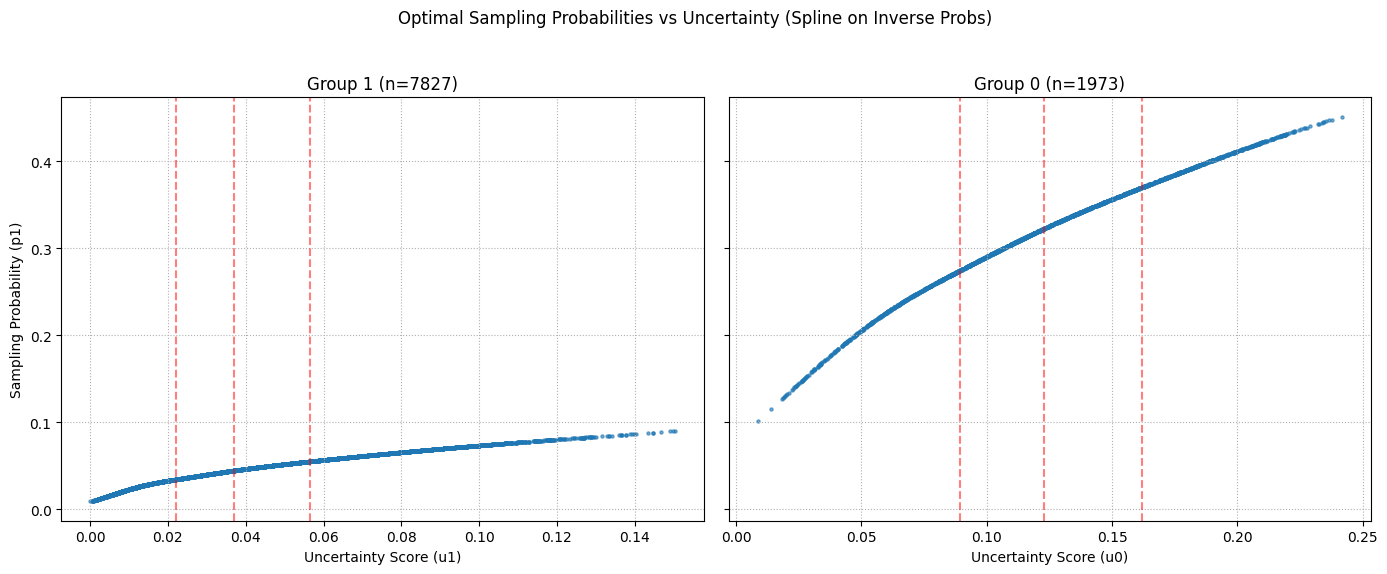

In [7]:
# --- Example Usage (Same as before) ---
if __name__ == '__main__':
    # Generate some synthetic data
    np.random.seed(42)
    n1_total = 7827 # Use numbers similar to your plots/problem
    n0_total = 1973
    n_total = n1_total + n0_total
    # Generate uncertainties such that they might have different ranges/distributions
    u1_all = np.random.beta(a=2, b=10, size=n1_total) * 0.25 # Skewed towards lower values
    u0_all = np.random.beta(a=3, b=3, size=n0_total) * 0.25 # More centered
    mu1_true = 0.7 # Hypothetical means
    mu0_true = 0.3

    # --- Set a budget that previously failed (example: 0.0863 * n_total) ---
    # budget_fraction = 0.0863
    budget_fraction = 0.1 # Try a standard fraction
    total_budget = budget_fraction * n_total

    print(f"Total points: {n_total}")
    print(f"Budget Fraction: {budget_fraction:.4f}, Absolute Budget: {total_budget:.2f}")
    print(f"Group 1: n={n1_total}, mu={mu1_true}, mean(u)={np.mean(u1_all):.4f}, range(u)=[{np.min(u1_all):.4f}, {np.max(u1_all):.4f}]")
    print(f"Group 0: n={n0_total}, mu={mu0_true}, mean(u)={np.mean(u0_all):.4f}, range(u)=[{np.min(u0_all):.4f}, {np.max(u0_all):.4f}]")

    # --- Run the spline-based optimization (inverse parametrization) ---
    print("\nRunning Spline Optimization (Inverse Parametrization)...")
    probs1_spline_inv, probs0_spline_inv, params1_inv, params0_inv = sampling_probs_spline_inv(
        u1_all, u0_all, mu1_true, mu0_true, total_budget,
        num_knots=3, degree=3, # Try fewer knots for potentially smoother result
        verbose_solver=False # Set to True to see detailed solver logs
    )

    # --- Process and Plot Results (Same as before) ---
    if probs1_spline_inv is not None and probs0_spline_inv is not None:
        print("\nSpline Optimization Results (Inverse Param):")
        if n1_total > 0: print(f"Group 1 Probs: Min={np.min(probs1_spline_inv):.4f}, Max={np.max(probs1_spline_inv):.4f}, Mean={np.mean(probs1_spline_inv):.4f}")
        if n0_total > 0: print(f"Group 0 Probs: Min={np.min(probs0_spline_inv):.4f}, Max={np.max(probs0_spline_inv):.4f}, Mean={np.mean(probs0_spline_inv):.4f}")

        expected_samples_inv = np.sum(probs1_spline_inv) + np.sum(probs0_spline_inv)
        print(f"Expected Samples: {expected_samples_inv:.2f} (Budget was {total_budget:.2f})")

        if n1_total > 1:
             corr1_inv = np.corrcoef(u1_all, probs1_spline_inv)[0, 1]
             print(f"Correlation between u1 and p1: {corr1_inv:.3f}")
        if n0_total > 1:
             corr0_inv = np.corrcoef(u0_all, probs0_spline_inv)[0, 1]
             print(f"Correlation between u0 and p0: {corr0_inv:.3f}")

        # Plot results
        fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True) # Adjusted size

        if n1_total>0:
            order1 = np.argsort(u1_all)
            axs[0].scatter(u1_all[order1], probs1_spline_inv[order1], s=5, alpha=0.6, label='Calculated Probs') # Smaller points
            axs[0].set_title(f'Group 1 (n={n1_total})')
            axs[0].set_xlabel('Uncertainty Score (u1)')
            axs[0].set_ylabel('Sampling Probability (p1)')
            axs[0].grid(True, linestyle=':')
            if params1_inv and params1_inv.get('knots') is not None and len(params1_inv['knots']) > 0:
                 for i, knot in enumerate(params1_inv['knots']):
                      axs[0].axvline(knot, color='red', linestyle='--', alpha=0.5, label='knot' if i == 0 else "")
            # axs[0].legend() # Optional: legend can get crowded

        if n0_total>0:
            order0 = np.argsort(u0_all)
            axs[1].scatter(u0_all[order0], probs0_spline_inv[order0], s=5, alpha=0.6, label='Calculated Probs') # Smaller points
            axs[1].set_title(f'Group 0 (n={n0_total})')
            axs[1].set_xlabel('Uncertainty Score (u0)')
            # axs[1].set_ylabel('Sampling Probability (p0)') # Shared y-axis
            axs[1].grid(True, linestyle=':')
            if params0_inv and params0_inv.get('knots') is not None and len(params0_inv['knots']) > 0:
                 for i, knot in enumerate(params0_inv['knots']):
                      axs[1].axvline(knot, color='red', linestyle='--', alpha=0.5, label='knot' if i == 0 else "")
            # axs[1].legend()

        plt.suptitle('Optimal Sampling Probabilities vs Uncertainty (Spline on Inverse Probs)')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    else:
        print("Spline optimization (inverse param) failed.")

### confidence interval construction

In [51]:
def sample_ci(Y0, Yhat0, Y1, Yhat1, probs0_A, probs1_A, probs0_B, probs1_B, alpha, budget, tau, lhat0=None, lhat1=None):
    n0 = Y0.shape[0]
    n1 = Y1.shape[0]    
    probs0_A = np.clip(tau*probs0_A + (1-tau)*budget, 0, 1)
    probs1_A = np.clip(tau*probs1_A + (1-tau)*budget, 0, 1)
    probs0_B = np.clip(tau*probs0_B + (1-tau)*budget, 0, 1)
    probs1_B = np.clip(tau*probs1_B + (1-tau)*budget, 0, 1)
    
    # draw uniforms for coupling
    U0, U1 = np.random.rand(n0), np.random.rand(n1)
    xi0_A, xi0_B = U0 <= probs0_A, U0 <= probs0_B
    xi1_A, xi1_B = U1 <= probs1_A, U1 <= probs1_B

    # compute estimates
    mu0_hatA = np.mean(lhat0*Yhat0 + (Y0 - lhat0*Yhat0)*xi0_A/probs0_A)
    mu1_hatA = np.mean(lhat1*Yhat1 + (Y1 - lhat1*Yhat1)*xi1_A/probs1_A)
    mu0_hatB = np.mean(lhat0*Yhat0 + (Y0 - lhat0*Yhat0)*xi0_B/probs0_B)
    mu1_hatB = np.mean(lhat1*Yhat1 + (Y1 - lhat1*Yhat1)*xi1_B/probs1_B)
    pointest_logA = np.log(mu1_hatA/(1-mu1_hatA)) - np.log(mu0_hatA/(1-mu0_hatA))
    pointest_logB = np.log(mu1_hatB/(1-mu1_hatB)) - np.log(mu0_hatB/(1-mu0_hatB))
    
    # compute variances
    var_mu0_hatA = np.var(lhat0*Yhat0 + (Y0 - lhat0*Yhat0)*xi0_A/probs0_A)
    var_mu1_hatA = np.var(lhat1*Yhat1 + (Y1 - lhat1*Yhat1)*xi1_A/probs1_A)
    var_mu0_hatB = np.var(lhat0*Yhat0 + (Y0 - lhat0*Yhat0)*xi0_B/probs0_B)
    var_mu1_hatB = np.var(lhat1*Yhat1 + (Y1 - lhat1*Yhat1)*xi1_B/probs1_B)
    var0_A = var_mu0_hatA/((mu0_hatA*(1-mu0_hatA))**2)
    var1_A = var_mu1_hatA/((mu1_hatA*(1-mu1_hatA))**2)
    var0_B = var_mu0_hatB/((mu0_hatB*(1-mu0_hatB))**2)
    var1_B = var_mu1_hatB/((mu1_hatB*(1-mu1_hatB))**2)
    p0 = n0/(n0+n1)
    p1 = n1/(n0+n1)
    var_A = 1/p0*var0_A + 1/p1*var1_A
    var_B = 1/p0*var0_B + 1/p1*var1_B
    width_logA = norm.ppf(1-alpha/2)*np.sqrt(var_A/(n0+n1))
    width_logB = norm.ppf(1-alpha/2)*np.sqrt(var_B/(n0+n1))
    l_A, u_A = np.exp(pointest_logA - width_logA), np.exp(pointest_logA + width_logA)
    l_B, u_B = np.exp(pointest_logB - width_logB), np.exp(pointest_logB + width_logB)
    return l_A, u_A, var_A, probs0_A, probs1_A, np.where(xi0_A == 1), np.where(xi1_A == 1), l_B, u_B, var_B, probs0_B, probs1_B, np.where(xi0_B == 1), np.where(xi1_B == 1)

In [89]:
def sample_ci_mixture(Y0, Yhat0, Y1, Yhat1, probs0_A, probs1_A, probs0_B, probs1_B, alpha, budget, lhat0=None, lhat1=None, lambda_tune = 0.5):
    n0 = Y0.shape[0]
    n1 = Y1.shape[0]    
    #probs0_A = np.clip((1-tau0)*probs0_A + tau0*budget, 0, 1)
    #probs1_A = np.clip((1-tau1)*probs1_A + tau1*budget, 0, 1)
    #probs0_B = np.clip((1-tau0)*probs0_B + tau0*budget, 0, 1)
    #probs1_B = np.clip((1-tau1)*probs1_B + tau1*budget, 0, 1)
    
    # Construct mixed probabilities
    probs0_mixed = lambda_tune * probs0_A + (1 - lambda_tune) * probs0_B
    probs1_mixed = lambda_tune * probs1_A + (1 - lambda_tune) * probs1_B

    # Apply tau shrinkage and clip
    #probs0_mixed = np.clip(tau * probs0_mixed + (1- tau) * budget, 0, 1)
    #probs1_mixed = np.clip(tau * probs1_mixed + (1 - tau) * budget, 0, 1)
    #potentially a different lambda_tune for probs0 and probs1
    
    # draw uniforms for coupling
    U0, U1 = np.random.rand(n0), np.random.rand(n1)
    xi0 = U0 <= probs0_mixed
    xi1 = U1 <= probs1_mixed

    # Estimation
    mu0_hat = np.mean(lhat0 * Yhat0 + (Y0 - lhat0 * Yhat0) * xi0 / probs0_mixed)
    mu1_hat = np.mean(lhat1 * Yhat1 + (Y1 - lhat1 * Yhat1) * xi1 / probs1_mixed)
    pointest_log = np.log(mu1_hat / (1 - mu1_hat)) - np.log(mu0_hat / (1 - mu0_hat))

    # Variance
    var_mu0 = np.var(lhat0 * Yhat0 + (Y0 - lhat0 * Yhat0) * xi0 / probs0_mixed)
    var_mu1 = np.var(lhat1 * Yhat1 + (Y1 - lhat1 * Yhat1) * xi1 / probs1_mixed)
    var0 = var_mu0 / ((mu0_hat * (1 - mu0_hat)) ** 2)
    var1 = var_mu1 / ((mu1_hat * (1 - mu1_hat)) ** 2)
    p0 = n0 / (n0 + n1)
    p1 = n1 / (n0 + n1)
    var_total = 1 / p0 * var0 + 1 / p1 * var1
    width_log = norm.ppf(1 - alpha / 2) * np.sqrt(var_total / (n0 + n1))

     # Confidence interval on odds ratio scale
    l, u = np.exp(pointest_log - width_log), np.exp(pointest_log + width_log)
    return l, u, var_total / (n0 + n1)
    #return l_A, u_A, var_A, probs0_A, probs1_A, np.where(xi0_A == 1), np.where(xi1_A == 1), l_B, u_B, var_B, probs0_B, probs1_B, np.where(xi0_B == 1), np.where(xi1_B == 1)

In [53]:
# sampling scheme
def odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, probs0, probs1, alpha, budget, tau, lhat0=None, lhat1=None):
    n0 = Y0.shape[0]
    n1 = Y1.shape[0]    
    probs0 = np.clip(tau*probs0 + (1 - tau)*budget, 0, 1)
    probs1 = np.clip(tau*probs1 + (1 - tau)*budget, 0, 1)
    xi0 = bernoulli.rvs(probs0)
    mu0_hat = np.mean(lhat0*Yhat0 + (Y0 - lhat0*Yhat0)*xi0/probs0)
    xi1 = bernoulli.rvs(probs1)
    mu1_hat = np.mean(lhat1*Yhat1 + (Y1 - lhat1*Yhat1)*xi1/probs1)

    pointest_log = np.log(mu1_hat/(1-mu1_hat)) - np.log(mu0_hat/(1-mu0_hat))
    var_mu0_hat = np.var(lhat0*Yhat0 + (Y0 - lhat0*Yhat0)*xi0/probs0)
    var_mu1_hat = np.var(lhat1*Yhat1 + (Y1 - lhat1*Yhat1)*xi1/probs1)
    var0 = var_mu0_hat/((mu0_hat*(1-mu0_hat))**2)
    var1 = var_mu1_hat/((mu1_hat*(1-mu1_hat))**2)
    p0 = n0/(n0+n1)
    p1 = n1/(n0+n1)
    var = 1/p0*var0 + 1/p1*var1
    width_log = norm.ppf(1-alpha/2)*np.sqrt(var/(n0+n1))
    return np.exp(pointest_log - width_log), np.exp(pointest_log + width_log), var, probs0, probs1, np.where(xi0 == 1), np.where(xi1 == 1)

In [54]:
# construct confidence intervals with cross-fitting

def sample_ci_cross(X0_train, Y0_train, X0, Y0, X1_train, Y1_train, X1, Y1, probs0_A, probs1_A, probs0_B, probs1_B, alpha, budget, tau, lhat0=None, lhat1=None):
    tau0 = 0.5
    tau1 = 0.5
    n0 = Y0.shape[0]
    n1 = Y1.shape[0]
    # mix with uniform sampling rule
    probs0_A = np.clip(tau*probs0_A + (1-tau)*budget, 0, 1)
    probs1_A = np.clip(tau*probs1_A + (1-tau)*budget, 0, 1)
    probs0_B = np.clip(tau*probs0_B + (1-tau)*budget, 0, 1)
    probs1_B = np.clip(tau*probs1_B + (1-tau)*budget, 0, 1)
    
    # Draw uniforms for coupling
    U0, U1 = np.random.rand(n0), np.random.rand(n1)
    xi0_A, xi0_B = U0 <= probs0_A, U0 <= probs0_B
    xi1_A, xi1_B = U1 <= probs1_A, U1 <= probs1_B
    # (Y0 - lhat0*Yhat0)*xi0_A/probs0_A
    # (Y1 - lhat1*Yhat1)*xi1_A/probs1_A
    # (Y0 - lhat0*Yhat0)*xi0_B/probs0_B
    # (Y1 - lhat1*Yhat1)*xi1_B/probs1_B

    # Random split of data -- maybe try a non-even split next (see how this does first)
    idx0 = np.arange(n0)
    idx1 = np.arange(n1)
    np.random.shuffle(idx0)
    np.random.shuffle(idx1)
    split0, split1 = n0 // 2, n1 // 2

    idx0_split1, idx0_split2 = idx0[:split0], idx0[split0:]
    idx1_split1, idx1_split2 = idx1[:split1], idx1[split1:]

    cov0_split2 = np.column_stack([X0[idx0_split2], np.zeros(len(idx0_split2))])
    cov1_split2 = np.column_stack([X1[idx1_split2], np.ones(len(idx1_split2))])
    cov0_split1 = np.column_stack([X0[idx0_split1], np.zeros(len(idx0_split1))])
    cov1_split1 = np.column_stack([X1[idx1_split1], np.ones(len(idx1_split1))])

    # train on split 2
    # get labelled data from split 2
    idx0_split2_labelledA = idx0_split2[np.where(xi0_A[idx0_split2] == 1)]
    idx0_split2_labelledB = idx0_split2[np.where(xi0_B[idx0_split2] == 1)]
    idx1_split2_labelledA = idx1_split2[np.where(xi1_A[idx1_split2] == 1)]
    idx1_split2_labelledB = idx1_split2[np.where(xi1_B[idx1_split2] == 1)]

    # Map original indices to local indices within the splits
    idx0_split2_labelledA_local = np.where(np.isin(idx0_split2, idx0_split2_labelledA))[0]
    idx1_split2_labelledA_local = np.where(np.isin(idx1_split2, idx1_split2_labelledA))[0]
    idx0_split2_labelledB_local = np.where(np.isin(idx0_split2, idx0_split2_labelledB))[0]
    idx1_split2_labelledB_local = np.where(np.isin(idx1_split2, idx1_split2_labelledB))[0]

    cov0_train = np.column_stack([X0_train, np.zeros(X0_train.shape[0])])
    cov1_train = np.column_stack([X1_train, np.ones(X1_train.shape[0])])

    # Correctly construct training sets with the local indices
    cov_splittrainA = np.vstack([
        cov0_train, cov1_train,
        cov0_split2[idx0_split2_labelledA_local, :],
        cov1_split2[idx1_split2_labelledA_local, :]
    ])

    cov_splittrainB = np.vstack([
        cov0_train, cov1_train,
        cov0_split2[idx0_split2_labelledB_local, :],
        cov1_split2[idx1_split2_labelledB_local, :]
    ])  

    # Correct Y_splittrainA and Y_splittrainB
    Y_splittrainA = np.concatenate([
        Y0_train, Y1_train,
        Y0[idx0_split2_labelledA_local],
        Y1[idx1_split2_labelledA_local]
    ])

    Y_splittrainB = np.concatenate([
        Y0_train, Y1_train,
        Y0[idx0_split2_labelledB_local],
        Y1[idx1_split2_labelledB_local]
    ])
    #cov_splittrainA = np.vstack([cov0_train, cov1_train, cov0_split2[idx0_split2_labelledA, :], cov1_split2[idx1_split2_labelledA, :]])
    #cov_splittrainB = np.vstack([cov0_train, cov1_train, cov0_split2[idx0_split2_labelledB, :], cov1_split2[idx1_split2_labelledB, :]])
    # Y_splittrainA = np.vstack([Y0_train, Y1_train, Y0[idx0_split2_labelledA], Y1[idx1_split2_labelledA]])
    # Y_splittrainB = np.vstack([Y0_train, Y1_train, Y0[idx0_split2_labelledB], Y1[idx1_split2_labelledB]])
    # finetune models based on split 2
    model_split2trainA = LogisticRegression(random_state=0).fit(cov_splittrainA, Y_splittrainA)
    model_split2trainB = LogisticRegression(random_state=0).fit(cov_splittrainB, Y_splittrainB)

    # predictions for split 1
    Yhat1_split1A = model_split2trainA.predict_proba(cov1_split1)[:, 1]
    Yhat0_split1A = model_split2trainA.predict_proba(cov0_split1)[:, 1]
    Yhat1_split1B = model_split2trainB.predict_proba(cov1_split1)[:, 1]
    Yhat0_split1B = model_split2trainB.predict_proba(cov0_split1)[:, 1]

    xi0_A1, xi1_A1 = xi0_A[idx0_split1], xi1_A[idx1_split1]
    xi0_B1, xi1_B1 = xi0_B[idx0_split1], xi1_B[idx1_split1]
    xi0_A2, xi1_A2 = xi0_A[idx0_split2], xi1_A[idx1_split2]
    xi0_B2, xi1_B2 = xi0_B[idx0_split2], xi1_B[idx1_split2]

    probs0_A1, probs1_A1 = probs0_A[idx0_split1], probs1_A[idx1_split1]
    probs0_B1, probs1_B1 = probs0_B[idx0_split1], probs1_B[idx1_split1]
    probs0_A2, probs1_A2 = probs0_A[idx0_split2], probs1_A[idx1_split2]
    probs0_B2, probs1_B2 = probs0_B[idx0_split2], probs1_B[idx1_split2]

    # Compute estimates for split 1 based on split 2 fine-tuned models
    mu0_split1_hatA = np.mean(lhat0 * Yhat0_split1A + (Y0[idx0_split1] - lhat0 * Yhat0_split1A) * xi0_A1 / probs0_A1)
    mu1_split1_hatA = np.mean(lhat1 * Yhat1_split1A + (Y1[idx1_split1] - lhat1 * Yhat1_split1A) * xi1_A1 / probs1_A1)
    mu0_split1_hatB = np.mean(lhat0 * Yhat0_split1B + (Y0[idx0_split1] - lhat0 * Yhat0_split1B) * xi0_B1 / probs0_B1)
    mu1_split1_hatB = np.mean(lhat1 * Yhat1_split1B + (Y1[idx1_split1] - lhat1 * Yhat1_split1B) * xi1_B1 / probs1_B1)
    #######
    # train on split 1
    # get labelled data from split 2
    idx0_split1_labelledA = idx0_split1[np.where(xi0_A[idx0_split1] == 1)]
    idx0_split1_labelledB = idx0_split1[np.where(xi0_B[idx0_split1] == 1)]
    idx1_split1_labelledA = idx1_split1[np.where(xi1_A[idx1_split1] == 1)]
    idx1_split1_labelledB = idx1_split1[np.where(xi1_B[idx1_split1] == 1)]

    # Map original indices to local indices within split 1
    idx0_split1_labelledA_local = np.where(np.isin(idx0_split1, idx0_split1_labelledA))[0]
    idx1_split1_labelledA_local = np.where(np.isin(idx1_split1, idx1_split1_labelledA))[0]
    idx0_split1_labelledB_local = np.where(np.isin(idx0_split1, idx0_split1_labelledB))[0]
    idx1_split1_labelledB_local = np.where(np.isin(idx1_split1, idx1_split1_labelledB))[0]

    # Correct cov_splittrainA and cov_splittrainB for split 1
    cov_splittrainA = np.vstack([
        cov0_train, cov1_train,
        cov0_split1[idx0_split1_labelledA_local, :],
        cov1_split1[idx1_split1_labelledA_local, :]
    ])

    cov_splittrainB = np.vstack([
        cov0_train, cov1_train,
        cov0_split1[idx0_split1_labelledB_local, :],
        cov1_split1[idx1_split1_labelledB_local, :]
    ])
    # Correct Y_splittrainA and Y_splittrainB for split 1
    Y_splittrainA = np.concatenate([
        Y0_train, Y1_train,
        Y0[idx0_split1_labelledA_local],
        Y1[idx1_split1_labelledA_local]
    ])

    Y_splittrainB = np.concatenate([
        Y0_train, Y1_train,
        Y0[idx0_split1_labelledB_local],
        Y1[idx1_split1_labelledB_local]
    ])

    # cov_splittrainA = np.vstack([cov0_train, cov1_train, cov0_split1[idx0_split1_labelledA, :], cov1_split1[idx1_split1_labelledA, :]])
    # cov_splittrainB = np.vstack([cov0_train, cov1_train, cov0_split1[idx0_split1_labelledB, :], cov1_split1[idx1_split1_labelledB, :]])
    # Y_splittrainA = np.vstack([Y0_train, Y1_train, Y0[idx0_split1_labelledA], Y1[idx1_split1_labelledA]])
    # Y_splittrainB = np.vstack([Y0_train, Y1_train, Y0[idx0_split1_labelledB], Y1[idx1_split1_labelledB]])
    # finetune models based on split 1
    model_split1trainA = LogisticRegression(random_state=0).fit(cov_splittrainA, Y_splittrainA)
    model_split1trainB = LogisticRegression(random_state=0).fit(cov_splittrainB, Y_splittrainB)

    # predictions for split 2
    Yhat1_split2A = model_split1trainA.predict_proba(cov1_split2)[:, 1]
    Yhat0_split2A = model_split1trainA.predict_proba(cov0_split2)[:, 1]
    Yhat1_split2B = model_split1trainB.predict_proba(cov1_split2)[:, 1]
    Yhat0_split2B = model_split1trainB.predict_proba(cov0_split2)[:, 1]

    # Compute estimates for split 1 based on split 2 fine-tuned models
    mu0_split2_hatA = np.mean(lhat0 * Yhat0_split2A + (Y0[idx0_split2] - lhat0 * Yhat0_split2A) * xi0_A2 / probs0_A2)
    mu1_split2_hatA = np.mean(lhat1 * Yhat1_split2A + (Y1[idx1_split2] - lhat1 * Yhat1_split2A) * xi1_A2 / probs1_A2)
    mu0_split2_hatB = np.mean(lhat0 * Yhat0_split2B + (Y0[idx0_split2] - lhat0 * Yhat0_split2B) * xi0_B2 / probs0_B2)
    mu1_split2_hatB = np.mean(lhat1 * Yhat1_split2B + (Y1[idx1_split2] - lhat1 * Yhat1_split2B) * xi1_B2 / probs1_B2)

    # combine estimators
    mu0_hatA = len(idx0_split2) / n0 * mu0_split2_hatA + len(idx0_split1) / n0 * mu0_split1_hatA
    mu1_hatA = len(idx1_split2) / n1 * mu1_split2_hatA + len(idx1_split1) / n1 * mu1_split1_hatA
    mu0_hatB = len(idx0_split2) / n0 * mu0_split2_hatB + len(idx0_split1) / n0 * mu0_split1_hatB
    mu1_hatB = len(idx1_split2) / n1 * mu1_split2_hatB + len(idx1_split1) / n1 * mu1_split1_hatB

    pointest_logA = np.log(mu1_hatA / (1 - mu1_hatA)) - np.log(mu0_hatA / (1 - mu0_hatA))
    pointest_logB = np.log(mu1_hatB / (1 - mu1_hatB)) - np.log(mu0_hatB / (1 - mu0_hatB))

    # Compute variances
    var_mu0_hatA = 1 / (n0 - 1) * np.sum(np.square(lhat0 * Yhat0_split2A + (Y0[idx0_split2] - lhat0 * Yhat0_split2A) * xi0_A2 / probs0_A2 - mu0_hatA)) + 1 / (n0 - 1) * np.sum(np.square(lhat0 * Yhat0_split1A + (Y0[idx0_split1] - lhat0 * Yhat0_split1A) * xi0_A1 / probs0_A1 - mu0_hatA))
    var_mu1_hatA = 1 / (n1 - 1) * np.sum(np.square(lhat1 * Yhat1_split2A + (Y1[idx1_split2] - lhat1 * Yhat1_split2A) * xi1_A2 / probs1_A2 - mu1_hatA)) + 1 / (n1 - 1) * np.sum(np.square(lhat1 * Yhat1_split1A + (Y1[idx1_split1] - lhat1 * Yhat1_split1A) * xi1_A1 / probs1_A1 - mu1_hatA))
    var_mu0_hatB = 1 / (n0 - 1) * np.sum(np.square(lhat0 * Yhat0_split2B + (Y0[idx0_split2] - lhat0 * Yhat0_split2B) * xi0_B2 / probs0_B2 - mu0_hatB)) + 1 / (n0 - 1) * np.sum(np.square(lhat0 * Yhat0_split1B + (Y0[idx0_split1] - lhat0 * Yhat0_split1B) * xi0_B1 / probs0_B1 - mu0_hatB))
    var_mu1_hatB = 1 / (n1 - 1) * np.sum(np.square(lhat1 * Yhat1_split2B + (Y1[idx1_split2] - lhat1 * Yhat1_split2B) * xi1_B2 / probs1_B2 - mu1_hatB)) + 1 / (n1 - 1) * np.sum(np.square(lhat1 * Yhat1_split1B + (Y1[idx1_split1] - lhat1 * Yhat1_split1B) * xi1_B1 / probs1_B1 - mu1_hatB))

    var0_A = var_mu0_hatA / ((mu0_hatA * (1 - mu0_hatA)) ** 2)
    var1_A = var_mu1_hatA / ((mu1_hatA * (1 - mu1_hatA)) ** 2)
    var0_B = var_mu0_hatB / ((mu0_hatB * (1 - mu0_hatB)) ** 2)
    var1_B = var_mu1_hatB / ((mu1_hatB * (1 - mu1_hatB)) ** 2)

    p0, p1 = n0 / (n0 + n1), n1 / (n0 + n1)
    var_A = 1 / p0 * var0_A + 1 / p1 * var1_A
    var_B = 1 / p0 * var0_B + 1 / p1 * var1_B

    width_logA = norm.ppf(1 - alpha / 2) * np.sqrt(var_A / (n0 + n1))
    width_logB = norm.ppf(1 - alpha / 2) * np.sqrt(var_B / (n0 + n1))

    l_A, u_A = np.exp(pointest_logA - width_logA), np.exp(pointest_logA + width_logA)
    l_B, u_B = np.exp(pointest_logB - width_logB), np.exp(pointest_logB + width_logB)
    
    return l_A, u_A, var_A, probs0_A, probs1_A, np.where(xi0_A == 1), np.where(xi1_A == 1), l_B, u_B, var_B, probs0_B, probs1_B, np.where(xi0_B == 1), np.where(xi1_B == 1)

In [12]:
def tune_lambda(Y0, Yhat0, Y1, Yhat1, probs0_A, probs1_A, probs0_B, probs1_B,
                alpha, budget, lhat0, lhat1, lambdas=np.linspace(0, 1, 21), K=1000):
    avg_vars = []
    for lam in lambdas:
        vars_lam = []
        for _ in range(K):
            _, _, var = sample_ci_mixture(Y0, Yhat0, Y1, Yhat1, probs0_A, probs1_A, probs0_B, probs1_B, alpha, budget, lhat0, lhat1, lam)
            vars_lam.append(var)
        avg_var = np.mean(vars_lam)
        avg_vars.append(avg_var)
        #print(f"λ = {lam:.2f}, Avg Var = {avg_var:.6f}")
    
    best_idx = np.argmin(avg_vars)
    best_lambda = lambdas[best_idx]
    print(f"Best λ = {best_lambda:.2f} with Avg Var = {avg_vars[best_idx]:.6f}")
    
    return best_lambda, avg_vars


### Loading AlphaFold Data

In [16]:
dataset_folder = "./data/"
data = load_dataset(dataset_folder, "alphafold")
Y_total = data["Y"]
#Yhat_total = data["Yhat"]
Z = data["phosphorylated"].astype(bool)

In [17]:
# Split into two subgroups for odds ratio calculation
Y0, Y1 = Y_total[~Z], Y_total[Z]
#Yhat0, Yhat1 = Yhat_total[~Z], Yhat_total[Z]
n0 = Y0.shape[0]
n1 = Y1.shape[0]
n = len(Y_total)

In [19]:
accessibility_df = pd.read_csv('data/accessibility_df.csv')
rsa_df = pd.read_csv('data/RSA_data.csv')
# combine accessibility and RSA scores (both Alphafold-based scores that are correlated with disorder)
# into one dataframe
scores_df = accessibility_df.merge(
    rsa_df, how='inner', on=['protein_id', 'position', 'AA']
)
# need dummy protein_number column to run get_smooth_score
protein_ids = sorted(scores_df.protein_id.unique())
id2number = {pid: i for i, pid in enumerate(protein_ids)}
protein_number_col = [id2number[pid] for pid in scores_df.protein_id]
scores_df['protein_number'] = protein_number_col
scores_to_smooth = np.array(
    ['neg_RSA', 'nAA_12_180_pae', 'nAA_16_180_pae', 'nAA_20_180_pae', 'nAA_24_180_pae', 'nAA_28_180_pae']
)
smoothedscores_df = get_smooth_score(scores_df, scores_to_smooth, [5, 10, 15, 20, 25, 30, 35])
idr_df = pd.read_csv('data/idr-groundtruth.csv')
idr_scores_df = smoothedscores_df.merge(idr_df, how='inner', on=['protein_id', 'position'])
ptm_df = pd.read_csv('data/phosphositeplus_annotation.csv')
ptm_idr_df = ptm_df.merge(
    idr_scores_df, how='inner', on=['protein_id', 'position', 'AA']
)

100%|██████████| 3062/3062 [00:25<00:00, 120.16it/s]


In [20]:
score_name = 'neg_RSA_smooth30'
X1 = ptm_idr_df[Z][score_name]
X0 = ptm_idr_df[~Z][score_name]

In [21]:
n_tr = 500
X1_train, X1_test, Y1_train, Y1_test = train_test_split(X1, Y1, train_size = n_tr)
X0_train, X0_test, Y0_train, Y0_test = train_test_split(X0, Y0, train_size = n_tr)
mu1_init, mu0_init = np.mean(Y1_train), np.mean(Y0_train)
X_train = np.concatenate((X1_train, X0_train))
Y_train = np.concatenate((Y1_train, Y0_train))
X_test = np.concatenate((X1_test, X0_test))
Y_test = np.concatenate((Y1_test, Y0_test))

In [22]:
# True odds ratio
mu0_true = Y0_test.mean()
mu1_true = Y1_test.mean()
OR_true = (mu1_true / (1 - mu1_true)) / (mu0_true / (1 - mu0_true))
true_var = (1 / np.sum(Y0_test == 0) + 1 / np.sum(Y0_test == 1) + 1 / np.sum(Y1_test == 0) + 1 / np.sum(Y1_test == 1)) * n

In [59]:
X1_test = np.array(X1_test)
X0_test = np.array(X0_test)
X_train = np.array(X_train)
Z_train = np.concatenate((np.ones(len(X1_train)), np.zeros(len(X0_train))))
features_train = np.column_stack((X_train, Z_train))  # Combine X and Z into 2D array

# Train model on both X and Z
model = LogisticRegression(random_state=0).fit(features_train, Y_train)
#model = LogisticRegression(random_state=0).fit(X_train.reshape(-1,1), Y_train)

# For predictions, need to include Z
features1_test = np.column_stack((X1_test, np.ones(len(X1_test))))  # Z=1 for group 1
features0_test = np.column_stack((X0_test, np.zeros(len(X0_test))))  # Z=0 for group 0
features1_train = np.column_stack((X1_train, np.ones(len(X1_train))))
features0_train = np.column_stack((X0_train, np.ones(len(X0_train))))

# Get predictions
Yhat1_test = model.predict_proba(features1_test)[:, 1]                                                                                
Yhat0_test = model.predict_proba(features0_test)[:, 1]
Yhat_test = np.hstack((Yhat1_test, Yhat0_test))
Yhat1_train = model.predict_proba(features1_train)[:, 1]
Yhat0_train = model.predict_proba(features0_train)[:, 1]

ce1_test = Yhat1_test
ce0_test = Yhat0_test

### Experiments

#### piecewise constant probabilities

In [34]:
def create_bins(vec1, vec0, n_bins1, n_bins0):
    labels0 = pd.qcut(vec0, q = n_bins0, labels = np.arange(0, n_bins0))
    labels1 = pd.qcut(vec1, q = n_bins1, labels = np.arange(0,n_bins1))
    v0s = [vec0[labels0 == cluster].mean() for cluster in np.unique(labels0)]
    v1s = [vec1[labels1 == cluster].mean() for cluster in np.unique(labels1)]
    unique0, counts0 = np.unique(labels0, return_counts=True)
    unique1, counts1 = np.unique(labels1, return_counts=True)
    Ns = np.concatenate([counts1, counts0])
    v0_binned = np.array(v0s)[labels0]
    v1_binned = np.array(v1s)[labels1]
    return Ns, v1_binned, v0_binned, labels1, labels0

In [35]:
u0_test = Yhat0_test * (1 - Yhat0_test)
u1_test = Yhat1_test * (1 - Yhat1_test)
n_bins0 = 6
n_bins1 = 6
Ns, u0_binned, u1_binned, labels1, labels0 = create_bins(u1_test, u0_test, n_bins1, n_bins1)

In [36]:
Ns

array([920, 919, 920, 919, 919, 920, 714, 714, 715, 713, 714, 715])

(array([ 85.,  75.,  61.,  63.,  60.,  56.,  61.,  72.,  53., 129.]),
 array([0.13381057, 0.14542951, 0.15704845, 0.16866739, 0.18028634,
        0.19190528, 0.20352422, 0.21514316, 0.22676211, 0.23838105,
        0.24999999]),
 <BarContainer object of 10 artists>)

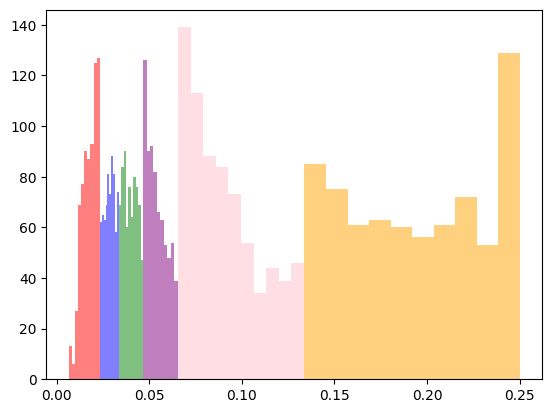

In [37]:
plt.hist(u0_test[labels0 == np.unique(labels0)[0]], bins=10, alpha=0.5, label='Group 0, subgroup 1', color = "red")
plt.hist(u0_test[labels0 == np.unique(labels0)[1]], bins=10, alpha=0.5, label='Group 0, subgroup 2', color = "blue")
plt.hist(u0_test[labels0 == np.unique(labels0)[2]], bins=10, alpha=0.5, label='Group 0, subgroup 3', color = "green")
plt.hist(u0_test[labels0 == np.unique(labels0)[3]], bins=10, alpha=0.5, label='Group 0, subgroup 1', color = "purple")
plt.hist(u0_test[labels0 == np.unique(labels0)[4]], bins=10, alpha=0.5, label='Group 0, subgroup 2', color = "pink")
plt.hist(u0_test[labels0 == np.unique(labels0)[5]], bins=10, alpha=0.5, label='Group 0, subgroup 3', color = "orange")

(array([ 61.,  72.,  81.,  85.,  66.,  66.,  63.,  86., 109., 231.]),
 array([0.18709783, 0.19338802, 0.19967822, 0.20596842, 0.21225862,
        0.21854882, 0.22483901, 0.23112921, 0.23741941, 0.24370961,
        0.24999981]),
 <BarContainer object of 10 artists>)

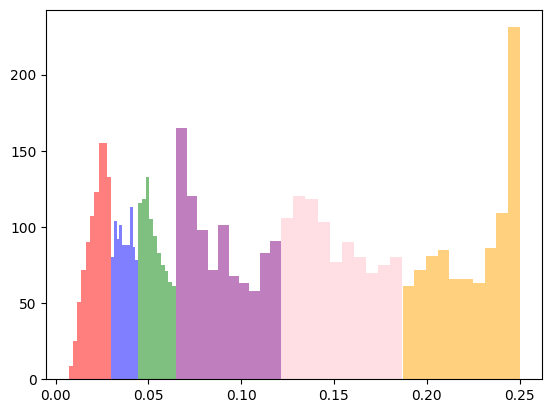

In [39]:
plt.hist(u1_test[labels1 == np.unique(labels1)[0]], bins=10, alpha=0.5, label='Group 1, subgroup 1', color = "red")
plt.hist(u1_test[labels1 == np.unique(labels1)[1]], bins=10, alpha=0.5, label='Group 1, subgroup 2', color = "blue")
plt.hist(u1_test[labels1 == np.unique(labels1)[2]], bins=10, alpha=0.5, label='Group 1, subgroup 3', color = "green")
plt.hist(u1_test[labels1 == np.unique(labels1)[3]], bins=10, alpha=0.5, label='Group 1, subgroup 1', color = "purple")
plt.hist(u1_test[labels1 == np.unique(labels1)[4]], bins=10, alpha=0.5, label='Group 1, subgroup 2', color = "pink")
plt.hist(u1_test[labels1 == np.unique(labels1)[5]], bins=10, alpha=0.5, label='Group 1, subgroup 3', color = "orange")

In [42]:
u1s, u0s = np.unique(u1_binned), np.unique(u0_binned)

In [43]:
budget = 0.2
n1, n0 = len(Yhat1_test), len(Yhat0_test)
n = n1 + n0
p1_bin, p0_bin = sampling_probs_constant(u1s, u0s, mu1_init, mu0_init, Ns, budget * n)
p1_constant = p1_bin[labels1]
p0_constant = p0_bin[labels0]
uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
eta0 = budget / np.mean(uncertainty0)
eta1 = budget / np.mean(uncertainty1)
p0_active = eta0 * uncertainty0
p1_active = eta1 * uncertainty1

In [44]:
p1_bin, p0_bin

(array([0.0668226 , 0.08530946, 0.10060643, 0.11760153, 0.15248807,
        0.22269841]),
 array([0.15270242, 0.19853145, 0.23755963, 0.30794042, 0.40019285,
        0.48802085]))

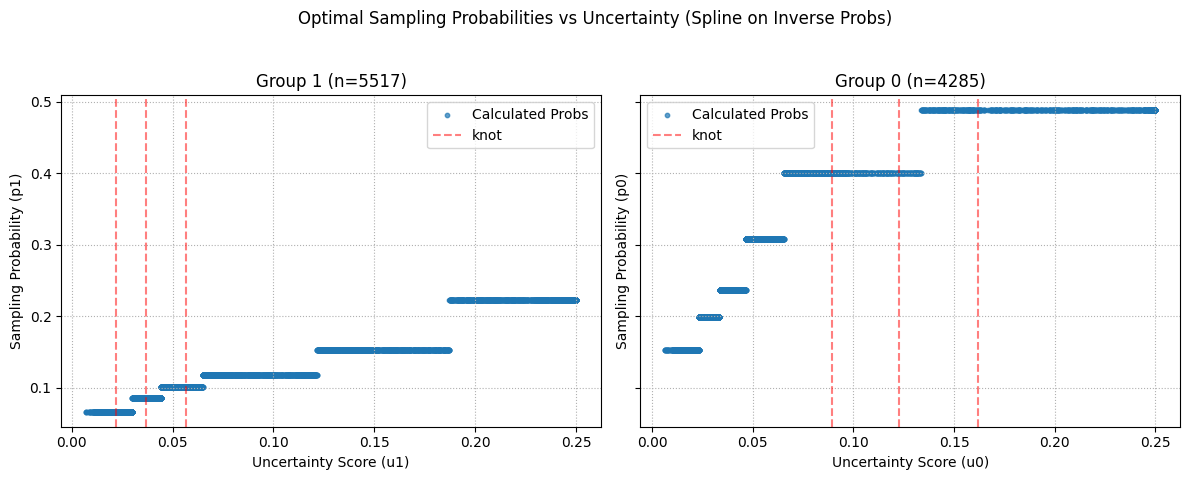

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        
if len(u1_test)>0:
    order1 = np.argsort(u1_test)
    axs[0].scatter(u1_test[order1], p1_constant[order1], s=10, alpha=0.7, label='Calculated Probs')
    axs[0].set_title(f'Group 1 (n={n1})')
    axs[0].set_xlabel('Uncertainty Score (u1)')
    axs[0].set_ylabel('Sampling Probability (p1)')
    axs[0].grid(True, linestyle=':')
    if params1_inv and params1_inv['knots'] is not None:
            for knot in params1_inv['knots']:
                axs[0].axvline(knot, color='red', linestyle='--', alpha=0.5, label='knot' if 'knot' not in axs[0].get_legend_handles_labels()[1] else "")
    axs[0].legend()

if len(u0_test)>0:
    order0 = np.argsort(u0_test)
    axs[1].scatter(u0_test[order0], p0_constant[order0], s=10, alpha=0.7, label='Calculated Probs')
    axs[1].set_title(f'Group 0 (n={n0})')
    axs[1].set_xlabel('Uncertainty Score (u0)')
    axs[1].set_ylabel('Sampling Probability (p0)')
    axs[1].grid(True, linestyle=':')
    if params0_inv and params0_inv['knots'] is not None:
            for knot in params0_inv['knots']:
                axs[1].axvline(knot, color='red', linestyle='--', alpha=0.5, label='knot' if 'knot' not in axs[1].get_legend_handles_labels()[1] else "")
    axs[1].legend()

plt.suptitle('Optimal Sampling Probabilities vs Uncertainty (Spline on Inverse Probs)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()


In [55]:
# 6 bins
budgets = np.linspace(0.02, 0.2, 20)
alpha = 0.1
num_trials = 1000
results = []
results_corrsampling = []
columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_b$"] # number labeled in group 1
temp_df_corrsampling = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
n1, n0 = Yhat1_test.shape[0], Yhat0_test.shape[0]
n = n1 + n0
p1_G_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_G_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_T_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_T_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_M_sim1  = np.zeros((len(budgets), ce1_test.shape[0])) #mixture
p0_M_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))

for j in range(len(budgets)):
    budget = budgets[j]
    # active
    uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
    uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
    eta0 = budget / np.mean(uncertainty0)
    eta1 = budget / np.mean(uncertainty1)
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1

    p1_bin, p0_bin = sampling_probs_constant(u1s, u0s, mu1_init, mu0_init, Ns, budget * n)
    p1_constant = p1_bin[labels1]
    p0_constant = p0_bin[labels0]
    # need to fix the power tuning implementation: relies on estimating quantities we don't know...can just use the train set to pick lambda
    # lambda_star, vars_avg = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_constant, p1_constant,
    #                                 alpha, budget, 1, 1)
    
    tau = 1

    for k in tqdm(range(num_trials)):
        l_A, u_A, v_A, p0_a, p1_a, label0_A, label1_A, l_S, u_S, v_S, p0_m, p1_m, label0_V, label1_V  = sample_ci(Y0_test.ravel(), Yhat0_test.ravel(), Y1_test.ravel(), Yhat1_test.ravel(), p0_active, p1_active, p0_constant, p1_constant, alpha, budget, tau, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l_A)*(OR_true <= u_A)   
        temp_df_corrsampling.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(budget*n)  
        coverage_var = (OR_true >= l_S)*(OR_true <= u_S)   
        temp_df_corrsampling.loc[1] = l_S, u_S, u_S-l_S, coverage_var, "var. min.", int(budget*n)  

        # l_M, u_M, var_M = sample_ci_mixture(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_constant, p1_constant, alpha, budget, 1, 1, lambda_star)
        # coverage_mix = (OR_true >= l_M) * (OR_true <= u_M)
        # temp_df_corrsampling.loc[2] = l_M, u_M, u_M - l_M, coverage_mix, "power tuning", int(budget * n)

        p1_unif, p0_unif = budget * np.ones(n1), budget * np.ones(n0)
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, tau, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l)*(OR_true <= u)  
        temp_df_corrsampling.loc[3] = l, u, u-l, coverage_active, "uniform", int(budget*n)  
        
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, tau, lhat0=0, lhat1=0)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        temp_df_corrsampling.loc[4] = l, u, u-l, coverage_active, "classical", int(budget*n)  
        results_corrsampling += [temp_df_corrsampling.copy()]
        
df_sim1_corrsampling = pd.concat(results_corrsampling, ignore_index = True)

100%|██████████| 1000/1000 [00:03<00:00, 256.28it/s]


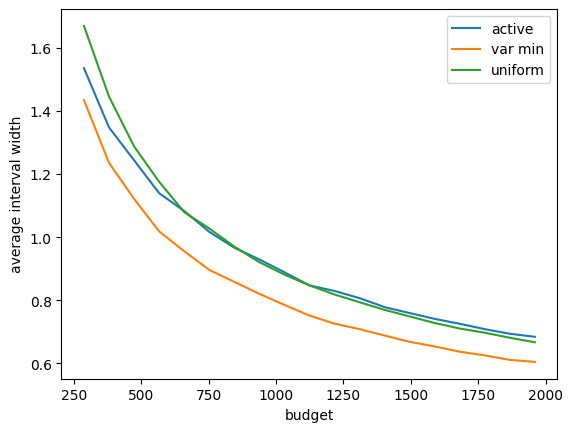

In [56]:
# May 3
# analysis/summary of results
df_sim1_corrsampling['coverage'] = df_sim1_corrsampling['coverage'] * 1.0
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_b$']
active_df = df_sim1_corrsampling[(df_sim1_corrsampling["estimator"] == "active")][relevant_columns].groupby('$n_b$').mean()
varmin_df = df_sim1_corrsampling[(df_sim1_corrsampling["estimator"] == "var. min.")][relevant_columns].groupby('$n_b$').mean()
uniform_df = df_sim1_corrsampling[(df_sim1_corrsampling["estimator"] == "uniform")][relevant_columns].groupby('$n_b$').mean()

plt.plot(np.array(active_df.index)[1:], np.array(active_df["interval width"])[1:], label = "active")
plt.plot(np.array(varmin_df.index)[1:], np.array(varmin_df["interval width"])[1:], label = "var min")
plt.plot(np.array(uniform_df.index)[1:], np.array(uniform_df["interval width"])[1:], label = "uniform")

#plt.axhline(1, color= "black")
plt.xlabel("budget")
plt.ylabel("average interval width")
plt.legend()
plt.show()


In [57]:
# spline
budgets = np.linspace(0.02, 0.2, 20)
alpha = 0.1
num_trials = 1000
results = []
results_corrsampling = []
columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_b$"] # number labeled in group 1
temp_df_corrsampling = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
n1, n0 = Yhat1_test.shape[0], Yhat0_test.shape[0]
n = n1 + n0
p1_G_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_G_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_T_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_T_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_M_sim1  = np.zeros((len(budgets), ce1_test.shape[0])) #mixture
p0_M_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))

for j in range(len(budgets)):
    budget = budgets[j]
    # active
    uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
    uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
    eta0 = budget / np.mean(uncertainty0)
    eta1 = budget / np.mean(uncertainty1)
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1

    # spline
    p1_spline, p0_spline, params1_inv, params0_inv = sampling_probs_spline_inv(
        u1_test, u0_test, mu1_init, mu0_init, n * budget, num_knots=5, degree=3
    )
    # need to fix the power tuning implementation: relies on estimating quantities we don't know...can just use the train set to pick lambda
    # lambda_star, vars_avg = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_constant, p1_constant,
    #                                 alpha, budget, 1, 1)
    
    tau = 1

    for k in tqdm(range(num_trials)):
        l_A, u_A, v_A, p0_a, p1_a, label0_A, label1_A, l_S, u_S, v_S, p0_m, p1_m, label0_V, label1_V  = sample_ci(Y0_test.ravel(), Yhat0_test.ravel(), Y1_test.ravel(), Yhat1_test.ravel(), p0_active, p1_active, p0_spline, p1_spline, alpha, budget, tau, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l_A)*(OR_true <= u_A)   
        temp_df_corrsampling.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(budget*n)  
        coverage_var = (OR_true >= l_S)*(OR_true <= u_S)   
        temp_df_corrsampling.loc[1] = l_S, u_S, u_S-l_S, coverage_var, "var. min.", int(budget*n)  

        # l_M, u_M, var_M = sample_ci_mixture(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_constant, p1_constant, alpha, budget, 1, 1, lambda_star)
        # coverage_mix = (OR_true >= l_M) * (OR_true <= u_M)
        # temp_df_corrsampling.loc[2] = l_M, u_M, u_M - l_M, coverage_mix, "power tuning", int(budget * n)

        p1_unif, p0_unif = budget * np.ones(n1), budget * np.ones(n0)
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, tau, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l)*(OR_true <= u)  
        temp_df_corrsampling.loc[3] = l, u, u-l, coverage_active, "uniform", int(budget*n)  
        
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, tau, lhat0=0, lhat1=0)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        temp_df_corrsampling.loc[4] = l, u, u-l, coverage_active, "classical", int(budget*n)  
        results_corrsampling += [temp_df_corrsampling.copy()]
        
df_spline_corrsampling = pd.concat(results_corrsampling, ignore_index = True)

Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.08599241298204988
Total Time: 1.2513 seconds


100%|██████████| 1000/1000 [00:03<00:00, 265.29it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.05835199502969416
Total Time: 0.9262 seconds


100%|██████████| 1000/1000 [00:07<00:00, 140.36it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.04415828266756351
Total Time: 1.0306 seconds


...

100%|██████████| 1000/1000 [00:03<00:00, 250.15it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.009026829488484869
Total Time: 0.8465 seconds


100%|██████████| 1000/1000 [00:03<00:00, 260.04it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.008599242468060314
Total Time: 0.7891 seconds


100%|██████████| 1000/1000 [00:04<00:00, 238.37it/s]


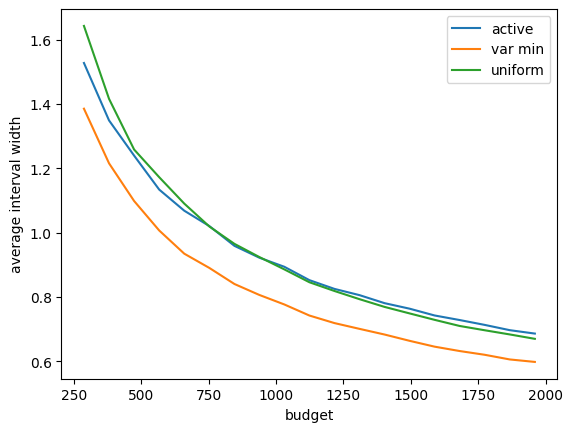

In [58]:
# May 3
# analysis/summary of results
df_spline_corrsampling['coverage'] = df_spline_corrsampling['coverage'] * 1.0
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_b$']
active_df = df_spline_corrsampling[(df_spline_corrsampling["estimator"] == "active")][relevant_columns].groupby('$n_b$').mean()
varmin_df = df_spline_corrsampling[(df_spline_corrsampling["estimator"] == "var. min.")][relevant_columns].groupby('$n_b$').mean()
uniform_df = df_spline_corrsampling[(df_spline_corrsampling["estimator"] == "uniform")][relevant_columns].groupby('$n_b$').mean()

plt.plot(np.array(active_df.index)[1:], np.array(active_df["interval width"])[1:], label = "active")
plt.plot(np.array(varmin_df.index)[1:], np.array(varmin_df["interval width"])[1:], label = "var min")
plt.plot(np.array(uniform_df.index)[1:], np.array(uniform_df["interval width"])[1:], label = "uniform")

#plt.axhline(1, color= "black")
plt.xlabel("budget")
plt.ylabel("average interval width")
plt.legend()
plt.show()



In [60]:
uncertainty0_train = np.minimum(Yhat0_train, 1 - Yhat0_train)
uncertainty1_train = np.minimum(Yhat1_train, 1 - Yhat1_train)

In [67]:
B_train, knots = setup_spline_basis(uncertainty0_train)

In [68]:
budget = 0.2
p1_spline, p0_spline, params1_inv, params0_inv = sampling_probs_spline_inv(
        u1_test, u0_test, mu1_init, mu0_init, n * budget, num_knots=5, degree=3
    )

Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.008599242468060314
Total Time: 1.5191 seconds


In [70]:
params0_inv['coeffs']

array([2.43785453, 2.08600541, 1.8363804 , 1.60668395, 1.43409912,
       1.15113092, 0.84956128, 0.70253963, 0.62504751])

In [72]:
probs = np.exp(-B_train @ params0_inv['coeffs'])

In [73]:
probs

array([0.20280181, 0.18394083, 0.23225239, 0.3479418 , 0.50978447,
       0.17910837, 0.15759631, 0.12074679, 0.35216874, 0.15585009,
       0.20227924, 0.37326274, 0.45666111, 0.2096187 , 0.18289397,
       0.22310801, 0.21697188, 0.17042422, 0.23718166, 0.20567883,
       0.34657166, 0.28547094, 0.21389596, 0.2330317 , 0.18653258,
       0.32711275, 0.14551758, 0.26081479, 0.25170651, 0.2011311 ,
       0.22472521, 0.24025705, 0.23924183, 0.26266459, 0.2167838 ,
       0.42791562, 0.19351134, 0.24077424, 0.15629818, 0.24419839,
       0.20841795, 0.22912678, 0.14495192, 0.34498647, 0.3402761 ,
       0.45249777, 0.32741578, 0.19485484, 0.16611678, 0.26055464,
       0.26231741, 0.38740192, 0.3818283 , 0.23089701, 0.2302352 ,
       0.5100459 , 0.17545029, 0.14061837, 0.26095126, 0.22637851,
       0.28144207, 0.19367936, 0.19046359, 0.23891813, 0.34536725,
       0.19444859, 0.27266371, 0.25587284, 0.22777479, 0.27809291,
       0.23191434, 0.12786533, 0.29684719, 0.2160622 , 0.16776

In [81]:
n_train = len(Y1_train) + len(Y0_train)
# p0_active, p1_active, p0_constant, p1_constant need to be adjusted
p0_active_temp = eta0 * uncertainty0_train
p1_active_temp = eta1 * uncertainty1_train
p0_active_train = p0_active_temp * n_train * budget / (np.sum(p0_active_temp) + np.sum(p1_active_temp))
p1_active_train = p1_active_temp * n_train * budget / (np.sum(p0_active_temp) + np.sum(p1_active_temp))
B0_train, _ = setup_spline_basis(uncertainty0_train)
B1_train, _ = setup_spline_basis(uncertainty1_train)
p0_spline_temp = np.exp(-B0_train @ params0_inv['coeffs'])
p1_spline_temp = np.exp(-B1_train @ params1_inv['coeffs'])
p0_spline_train = p0_spline_temp * n_train * budget / (np.sum(p0_spline_temp) + np.sum(p1_spline_temp))
p1_spline_train = p1_spline_temp * n_train * budget / (np.sum(p0_spline_temp) + np.sum(p1_spline_temp))
lambda_active, vars_avgA = tune_lambda(Y0_train, Yhat0_train, Y1_train, Yhat1_train, p0_active_train, p1_active_train, budget * np.ones(len(Y0_train)),
                                        budget * np.ones(len(Y1_train)), alpha, budget, 1, 1)

Best λ = 1.00 with Avg Var = 0.071827


In [80]:
np.sum(p1_active_train) + np.sum(p0_active_train)

200.0

In [82]:
lambda_varmin, vars_avgV = tune_lambda(Y0_train, Yhat0_train, Y1_train, Yhat1_train, p0_spline_train, p1_spline_train, budget * np.ones(len(Y0_train)),
                                           budget * np.ones(len(Y1_train)), alpha, budget, 1, 1)

Best λ = 1.00 with Avg Var = 0.077550


In [94]:
# spline
budgets = np.linspace(0.02, 0.2, 20)
alpha = 0.1
num_trials = 1000
results = []
results_corrsampling = []
columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_b$"] # number labeled in group 1
temp_df_corrsampling = pd.DataFrame(np.zeros((6, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
n1, n0 = Yhat1_test.shape[0], Yhat0_test.shape[0]
n = n1 + n0
p1_G_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_G_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_T_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_T_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_M_sim1  = np.zeros((len(budgets), ce1_test.shape[0])) #mixture
p0_M_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
lambdas_active = np.zeros(len(budgets))
lambdas_varmin = np.zeros(len(budgets))

for j in range(len(budgets)):
    budget = budgets[j]
    # active
    uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
    uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
    u0_train = np.minimum(Yhat0_train, 1 - Yhat0_train)
    u1_train = np.minimum(Yhat1_train, 1 - Yhat1_train)
    eta0 = budget / np.mean(uncertainty0)
    eta1 = budget / np.mean(uncertainty1)
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1

    # spline
    p1_spline, p0_spline, params1_inv, params0_inv = sampling_probs_spline_inv(
        u1_test, u0_test, mu1_init, mu0_init, n * budget, num_knots=5, degree=3
    )

    # how to calculate the probabilities with train data: need p1_spline, p1_active based on train size (but with the same budget? diff budget?)
    n_train = len(Y1_train) + len(Y0_train)
    print(f"Budget = {n_train * budget}")
    # p0_active, p1_active, p0_constant, p1_constant need to be adjusted
    p0_active_temp = eta0 * u0_train
    p1_active_temp = eta1 * u1_train
    p0_active_train = np.clip(p0_active_temp * n_train * budget / (np.sum(p0_active_temp) + np.sum(p1_active_temp)), 0, 1)
    p1_active_train = np.clip(p1_active_temp * n_train * budget / (np.sum(p0_active_temp) + np.sum(p1_active_temp)), 0, 1)
    print(f"Active sum = {np.sum(p0_active_train) + np.sum(p1_active_train)}")
    uncertainty0_train = np.minimum(Yhat0_train, 1 - Yhat0_train)
    uncertainty1_train = np.minimum(Yhat1_train, 1 - Yhat1_train)
    B0_train, _ = setup_spline_basis(uncertainty0_train)
    B1_train, _ = setup_spline_basis(uncertainty1_train)
    p0_spline_temp = np.exp(-B0_train @ params0_inv['coeffs'])
    p1_spline_temp = np.exp(-B1_train @ params1_inv['coeffs'])
    p0_spline_train = np.clip(p0_spline_temp * n_train * budget / (np.sum(p0_spline_temp) + np.sum(p1_spline_temp)), 0, 1)
    p1_spline_train = np.clip(p1_spline_temp * n_train * budget / (np.sum(p0_spline_temp) + np.sum(p1_spline_temp)), 0, 1)
    print(f"Spline sum = {np.sum(p0_spline_train) + np.sum(p1_spline_train)}")
    lambda_active, vars_avgA = tune_lambda(Y0_train, Yhat0_train, Y1_train, Yhat1_train, p0_active_train, p1_active_train, budget * np.ones(len(Y0_train)),
                                           budget * np.ones(len(Y1_train)), alpha, budget, 1, 1)
    lambda_varmin, vars_avgV = tune_lambda(Y0_train, Yhat0_train, Y1_train, Yhat1_train, p0_spline_train, p1_spline_train, budget * np.ones(len(Y0_train)),
                                           budget * np.ones(len(Y1_train)), alpha, budget, 1, 1)
    lambdas_active[j] = lambda_active
    lambdas_varmin[j] = lambda_varmin
    tau = 1

    for k in tqdm(range(num_trials)):
        l_A, u_A, v_A, p0_a, p1_a, label0_A, label1_A, l_S, u_S, v_S, p0_m, p1_m, label0_V, label1_V  = sample_ci(Y0_test.ravel(), Yhat0_test.ravel(), Y1_test.ravel(), Yhat1_test.ravel(), p0_active, p1_active, p0_spline, p1_spline, alpha, budget, tau, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l_A)*(OR_true <= u_A)   
        temp_df_corrsampling.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(budget*n)  
        coverage_var = (OR_true >= l_S)*(OR_true <= u_S)   
        temp_df_corrsampling.loc[1] = l_S, u_S, u_S-l_S, coverage_var, "var. min.", int(budget*n)  

        p1_unif, p0_unif = budget * np.ones(n1), budget * np.ones(n0)
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, tau, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l)*(OR_true <= u)  
        temp_df_corrsampling.loc[2] = l, u, u-l, coverage_active, "uniform", int(budget*n)  

        l_M, u_M, var_M = sample_ci_mixture(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_unif, p1_unif, alpha, budget, 1, 1, lambda_active)
        coverage_mix = (OR_true >= l_M) * (OR_true <= u_M)
        temp_df_corrsampling.loc[3] = l_M, u_M, u_M - l_M, coverage_mix, "active uniform mix", int(budget * n)

        l_M, u_M, var_M = sample_ci_mixture(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_spline, p1_spline, p0_unif, p1_unif, alpha, budget, 1, 1, lambda_varmin)
        coverage_mix = (OR_true >= l_M) * (OR_true <= u_M)
        temp_df_corrsampling.loc[4] = l_M, u_M, u_M - l_M, coverage_mix, "spline uniform mix", int(budget * n)

        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, tau, lhat0=0, lhat1=0)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        temp_df_corrsampling.loc[5] = l, u, u-l, coverage_active, "classical", int(budget*n)  
        results_corrsampling += [temp_df_corrsampling.copy()]
        
df_tuning_corrsampling = pd.concat(results_corrsampling, ignore_index = True)

Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.08599241298204988
Total Time: 2.3935 seconds
Budget = 20.0
Active sum = 20.0
Spline sum = 20.000000000000004
Best λ = 0.85 with Avg Var = 0.947176
Best λ = 0.55 with Avg Var = 2.352729


100%|██████████| 1000/1000 [00:06<00:00, 163.01it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.05835199502969416
Total Time: 1.2229 seconds
Budget = 29.47368421052632
Active sum = 29.473684210526315
Spline sum = 29.473684210526322
Best λ = 0.85 with Avg Var = 0.359991
Best λ = 0.90 with Avg Var = 0.461735


100%|██████████| 1000/1000 [00:04<00:00, 201.66it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.04415828266756351
Total Time: 0.9064 seconds
Budget = 38.94736842105263
Active sum = 38.94736842105264
Spline sum = 38.94736842105263
Best λ = 0.85 with Avg Var = 0.273222
Best λ = 1.00 with Avg Var = 0.303583


...

100%|██████████| 1000/1000 [00:12<00:00, 81.04it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.009026829488484869
Total Time: 1.0172 seconds
Budget = 190.52631578947367
Active sum = 190.5263157894737
Spline sum = 190.52631578947367
Best λ = 0.55 with Avg Var = 0.074702
Best λ = 0.95 with Avg Var = 0.077893


100%|██████████| 1000/1000 [00:06<00:00, 165.73it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.008599242468060314
Total Time: 1.3660 seconds
Budget = 200.0
Active sum = 199.97517491548916
Spline sum = 200.0
Best λ = 0.50 with Avg Var = 0.072113
Best λ = 0.90 with Avg Var = 0.074952


100%|██████████| 1000/1000 [00:06<00:00, 164.87it/s]


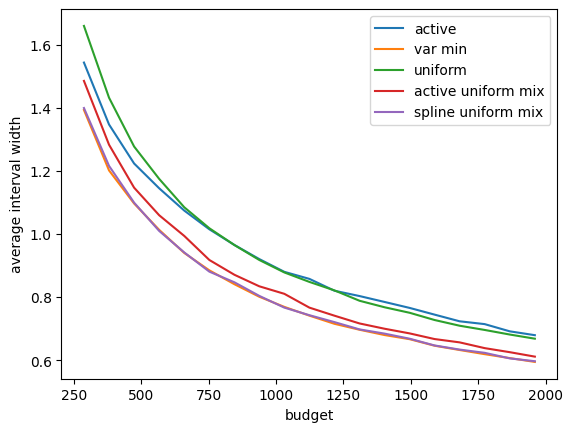

In [95]:
# May 4
# analysis/summary of results
df_tuning_corrsampling['coverage'] = df_tuning_corrsampling['coverage'] * 1.0
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_b$']
active_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "active")][relevant_columns].groupby('$n_b$').mean()
varmin_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "var. min.")][relevant_columns].groupby('$n_b$').mean()
uniform_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "uniform")][relevant_columns].groupby('$n_b$').mean()
activetune_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "active uniform mix")][relevant_columns].groupby('$n_b$').mean()
varmintune_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "spline uniform mix")][relevant_columns].groupby('$n_b$').mean()

plt.plot(np.array(active_df.index)[1:], np.array(active_df["interval width"])[1:], label = "active")
plt.plot(np.array(varmin_df.index)[1:], np.array(varmin_df["interval width"])[1:], label = "var min")
plt.plot(np.array(uniform_df.index)[1:], np.array(uniform_df["interval width"])[1:], label = "uniform")
plt.plot(np.array(activetune_df.index)[1:], np.array(activetune_df["interval width"])[1:], label = "active uniform mix")
plt.plot(np.array(varmintune_df.index)[1:], np.array(varmintune_df["interval width"])[1:], label = "spline uniform mix")

#plt.axhline(1, color= "black")
plt.xlabel("budget")
plt.ylabel("average interval width")
plt.legend()
plt.show()



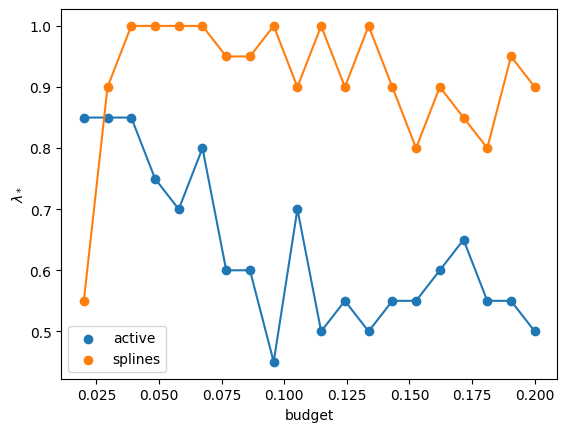

In [100]:
# May 4
plt.scatter(budgets, lambdas_active, label = "active")
plt.plot(budgets, lambdas_active)
plt.scatter(budgets, lambdas_varmin, label = "splines")
plt.plot(budgets, lambdas_varmin)

plt.xlabel("budget")
plt.ylabel(r'$\lambda_*$')
plt.legend()
plt.show()

In [101]:
# spline
budgets = np.linspace(0.02, 0.2, 20)
alpha = 0.1
num_trials = 1000
results = []
results_corrsampling = []
columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_b$"] # number labeled in group 1
temp_df_corrsampling = pd.DataFrame(np.zeros((8, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
n1, n0 = Yhat1_test.shape[0], Yhat0_test.shape[0]
n = n1 + n0
p1_G_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_G_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_T_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_T_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_M_sim1  = np.zeros((len(budgets), ce1_test.shape[0])) #mixture
p0_M_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
lambdas_active = np.zeros(len(budgets))
lambdas_varmin = np.zeros(len(budgets))

for j in range(len(budgets)):
    budget = budgets[j]
    # active
    uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
    uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
    u0_train = np.minimum(Yhat0_train, 1 - Yhat0_train)
    u1_train = np.minimum(Yhat1_train, 1 - Yhat1_train)
    eta0 = budget / np.mean(uncertainty0)
    eta1 = budget / np.mean(uncertainty1)
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1

    # spline
    p1_spline, p0_spline, params1_inv, params0_inv = sampling_probs_spline_inv(
        u1_test, u0_test, mu1_init, mu0_init, n * budget, num_knots=5, degree=3
    )

    # how to calculate the probabilities with train data: need p1_spline, p1_active based on train size (but with the same budget? diff budget?)
    n_train = len(Y1_train) + len(Y0_train)
    print(f"Budget = {n_train * budget}")
    # p0_active, p1_active, p0_constant, p1_constant need to be adjusted
    p0_active_temp = eta0 * u0_train
    p1_active_temp = eta1 * u1_train
    p0_active_train = np.clip(p0_active_temp * n_train * budget / (np.sum(p0_active_temp) + np.sum(p1_active_temp)), 0, 1)
    p1_active_train = np.clip(p1_active_temp * n_train * budget / (np.sum(p0_active_temp) + np.sum(p1_active_temp)), 0, 1)
    print(f"Active sum = {np.sum(p0_active_train) + np.sum(p1_active_train)}")
    uncertainty0_train = np.minimum(Yhat0_train, 1 - Yhat0_train)
    uncertainty1_train = np.minimum(Yhat1_train, 1 - Yhat1_train)
    B0_train, _ = setup_spline_basis(uncertainty0_train)
    B1_train, _ = setup_spline_basis(uncertainty1_train)
    p0_spline_temp = np.exp(-B0_train @ params0_inv['coeffs'])
    p1_spline_temp = np.exp(-B1_train @ params1_inv['coeffs'])
    p0_spline_train = np.clip(p0_spline_temp * n_train * budget / (np.sum(p0_spline_temp) + np.sum(p1_spline_temp)), 0, 1)
    p1_spline_train = np.clip(p1_spline_temp * n_train * budget / (np.sum(p0_spline_temp) + np.sum(p1_spline_temp)), 0, 1)
    print(f"Spline sum = {np.sum(p0_spline_train) + np.sum(p1_spline_train)}")
    lambda_active, vars_avgA = tune_lambda(Y0_train, Yhat0_train, Y1_train, Yhat1_train, p0_active_train, p1_active_train, budget * np.ones(len(Y0_train)),
                                           budget * np.ones(len(Y1_train)), alpha, budget, 1, 1)
    lambda_varmin, vars_avgV = tune_lambda(Y0_train, Yhat0_train, Y1_train, Yhat1_train, p0_spline_train, p1_spline_train, budget * np.ones(len(Y0_train)),
                                           budget * np.ones(len(Y1_train)), alpha, budget, 1, 1)
    lambdas_active[j] = lambda_active
    lambdas_varmin[j] = lambda_varmin
    tau = 1

    for k in tqdm(range(num_trials)):
        l_A, u_A, v_A, p0_a, p1_a, label0_A, label1_A, l_S, u_S, v_S, p0_m, p1_m, label0_V, label1_V  = sample_ci(Y0_test.ravel(), Yhat0_test.ravel(), Y1_test.ravel(), Yhat1_test.ravel(), p0_active, p1_active, p0_spline, p1_spline, alpha, budget, tau, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l_A)*(OR_true <= u_A)   
        temp_df_corrsampling.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(budget*n)  
        coverage_var = (OR_true >= l_S)*(OR_true <= u_S)   
        temp_df_corrsampling.loc[1] = l_S, u_S, u_S-l_S, coverage_var, "var. min.", int(budget*n)  

        p1_unif, p0_unif = budget * np.ones(n1), budget * np.ones(n0)
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, tau, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l)*(OR_true <= u)  
        temp_df_corrsampling.loc[2] = l, u, u-l, coverage_active, "uniform", int(budget*n)  

        l_M, u_M, var_M = sample_ci_mixture(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_unif, p1_unif, alpha, budget, 1, 1, lambda_active)
        coverage_mix = (OR_true >= l_M) * (OR_true <= u_M)
        temp_df_corrsampling.loc[3] = l_M, u_M, u_M - l_M, coverage_mix, "active uniform mix", int(budget * n)

        l_M, u_M, var_M = sample_ci_mixture(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_spline, p1_spline, p0_unif, p1_unif, alpha, budget, 1, 1, lambda_varmin)
        coverage_mix = (OR_true >= l_M) * (OR_true <= u_M)
        temp_df_corrsampling.loc[4] = l_M, u_M, u_M - l_M, coverage_mix, "spline uniform mix", int(budget * n)

        l_M, u_M, var_M = sample_ci_mixture(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_unif, p1_unif, alpha, budget, 1, 1, 0.5)
        coverage_mix = (OR_true >= l_M) * (OR_true <= u_M)
        temp_df_corrsampling.loc[5] = l_M, u_M, u_M - l_M, coverage_mix, "active uniform 0.5", int(budget * n)

        l_M, u_M, var_M = sample_ci_mixture(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_spline, p1_spline, p0_unif, p1_unif, alpha, budget, 1, 1, 0.5)
        coverage_mix = (OR_true >= l_M) * (OR_true <= u_M)
        temp_df_corrsampling.loc[6] = l_M, u_M, u_M - l_M, coverage_mix, "spline uniform 0.5", int(budget * n)

        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, tau, lhat0=0, lhat1=0)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        temp_df_corrsampling.loc[7] = l, u, u-l, coverage_active, "classical", int(budget*n)  
        results_corrsampling += [temp_df_corrsampling.copy()]
        
df_tuning_corrsampling = pd.concat(results_corrsampling, ignore_index = True)

Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.08599241298204988
Total Time: 1.7904 seconds
Budget = 20.0
Active sum = 20.0
Spline sum = 20.000000000000004
Best λ = 0.75 with Avg Var = 0.615665
Best λ = 1.00 with Avg Var = 1.751337


100%|██████████| 1000/1000 [00:06<00:00, 155.51it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.05835199502969416
Total Time: 0.9514 seconds
Budget = 29.47368421052632
Active sum = 29.473684210526315
Spline sum = 29.473684210526322
Best λ = 0.65 with Avg Var = 0.370800
Best λ = 1.00 with Avg Var = 0.496123


100%|██████████| 1000/1000 [00:07<00:00, 137.64it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.04415828266756351
Total Time: 0.9334 seconds
Budget = 38.94736842105263
Active sum = 38.94736842105264
Spline sum = 38.94736842105263
Best λ = 1.00 with Avg Var = 0.280902
Best λ = 0.80 with Avg Var = 0.312460


...

100%|██████████| 1000/1000 [00:06<00:00, 151.39it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.009026829488484869
Total Time: 0.8739 seconds
Budget = 190.52631578947367
Active sum = 190.5263157894737
Spline sum = 190.52631578947367
Best λ = 0.55 with Avg Var = 0.074113
Best λ = 0.85 with Avg Var = 0.077984


100%|██████████| 1000/1000 [00:06<00:00, 153.10it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.008599242468060314
Total Time: 0.8849 seconds
Budget = 200.0
Active sum = 199.97517491548916
Spline sum = 200.0
Best λ = 0.60 with Avg Var = 0.071994
Best λ = 0.75 with Avg Var = 0.075174


100%|██████████| 1000/1000 [00:06<00:00, 154.83it/s]


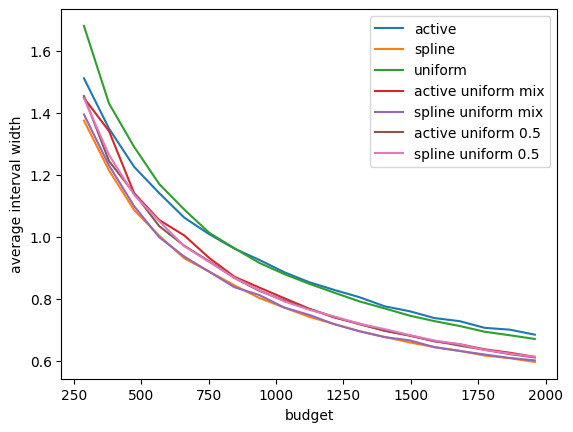

In [107]:
# May 5
# analysis/summary of results
df_tuning_corrsampling['coverage'] = df_tuning_corrsampling['coverage'] * 1.0
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_b$']
active_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "active")][relevant_columns].groupby('$n_b$').mean()
varmin_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "var. min.")][relevant_columns].groupby('$n_b$').mean()
uniform_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "uniform")][relevant_columns].groupby('$n_b$').mean()
activetune_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "active uniform mix")][relevant_columns].groupby('$n_b$').mean()
varmintune_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "spline uniform mix")][relevant_columns].groupby('$n_b$').mean()
active05_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "active uniform 0.5")][relevant_columns].groupby('$n_b$').mean()
varmin05_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "spline uniform 0.5")][relevant_columns].groupby('$n_b$').mean()

plt.plot(np.array(active_df.index)[1:], np.array(active_df["interval width"])[1:], label = "active")
plt.plot(np.array(varmin_df.index)[1:], np.array(varmin_df["interval width"])[1:], label = "spline")
plt.plot(np.array(uniform_df.index)[1:], np.array(uniform_df["interval width"])[1:], label = "uniform")
plt.plot(np.array(activetune_df.index)[1:], np.array(activetune_df["interval width"])[1:], label = "active uniform mix")
plt.plot(np.array(varmintune_df.index)[1:], np.array(varmintune_df["interval width"])[1:], label = "spline uniform mix")
plt.plot(np.array(active05_df.index)[1:], np.array(active05_df["interval width"])[1:], label = "active uniform 0.5")
plt.plot(np.array(varmin05_df.index)[1:], np.array(varmin05_df["interval width"])[1:], label = "spline uniform 0.5")

#plt.axhline(1, color= "black")
plt.xlabel("budget")
plt.ylabel("average interval width")
plt.legend()
plt.show()



In [113]:
uniform_df.index[1:]

Index([ 288.0,  381.0,  474.0,  567.0,  660.0,  753.0,  846.0,  938.0, 1031.0,
       1124.0, 1217.0, 1310.0, 1403.0, 1496.0, 1588.0, 1681.0, 1774.0, 1867.0,
       1960.0],
      dtype='float64', name='$n_b$')

In [115]:
np.array(uniform_df["interval width"])[1:]

array([1.67946262, 1.42947699, 1.28997846, 1.17036682, 1.08805004,
       1.01276834, 0.96340407, 0.91640927, 0.87997599, 0.84861217,
       0.82016071, 0.79201238, 0.76946476, 0.74625507, 0.72853478,
       0.71296566, 0.69443398, 0.68306121, 0.67119131])

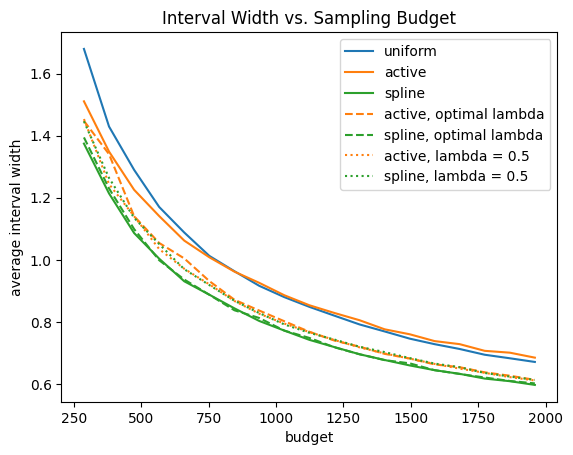

In [117]:
# May 5
# Define colors for the base methods
color_map = {
    "uniform": "tab:blue",
    "active": "tab:orange",
    "spline": "tab:green"
}

# Define linetypes for variations
linestyle_map = {
    "lambda = 0": "solid",
    "optimal lambda": "dashed",
    "lambda = 0.5": "dotted"
}

# Plotting each line with appropriate color and linestyle
plt.plot(uniform_df.index[1:], np.array(uniform_df["interval width"])[1:], 
         label="uniform", color=color_map["uniform"], linestyle=linestyle_map["lambda = 0"])

plt.plot(active_df.index[1:], np.array(active_df["interval width"])[1:], 
         label="active", color=color_map["active"], linestyle=linestyle_map["lambda = 0"])

plt.plot(varmin_df.index[1:], np.array(varmin_df["interval width"])[1:], 
         label="spline", color=color_map["spline"], linestyle=linestyle_map["lambda = 0"])

plt.plot(activetune_df.index[1:], np.array(activetune_df["interval width"])[1:], 
         label="active, optimal lambda", color=color_map["active"], linestyle=linestyle_map["optimal lambda"])

plt.plot(varmintune_df.index[1:], np.array(varmintune_df["interval width"])[1:], 
         label="spline, optimal lambda", color=color_map["spline"], linestyle=linestyle_map["optimal lambda"])

plt.plot(active05_df.index[1:], np.array(active05_df["interval width"])[1:], 
         label="active, lambda = 0.5", color=color_map["active"], linestyle=linestyle_map["lambda = 0.5"])

plt.plot(varmin05_df.index[1:], np.array(varmin05_df["interval width"])[1:], 
         label="spline, lambda = 0.5", color=color_map["spline"], linestyle=linestyle_map["lambda = 0.5"])

# Final plot setup
plt.xlabel("budget")
plt.ylabel("average interval width")
plt.legend()
plt.title("Interval Width vs. Sampling Budget")
plt.show()

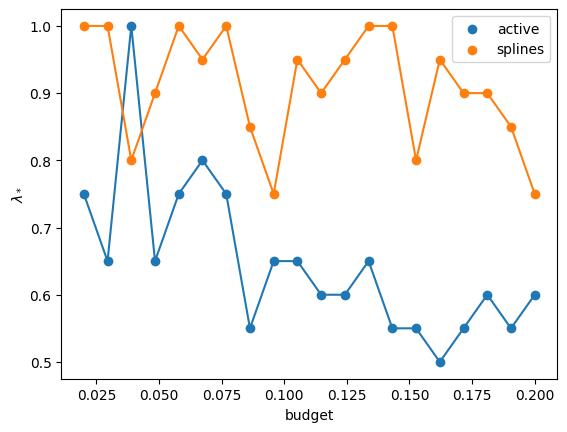

In [105]:
# May 5
plt.scatter(budgets, lambdas_active, label = "active")
plt.plot(budgets, lambdas_active)
plt.scatter(budgets, lambdas_varmin, label = "splines")
plt.plot(budgets, lambdas_varmin)

plt.xlabel("budget")
plt.ylabel(r'$\lambda_*$')
plt.legend()
plt.show()

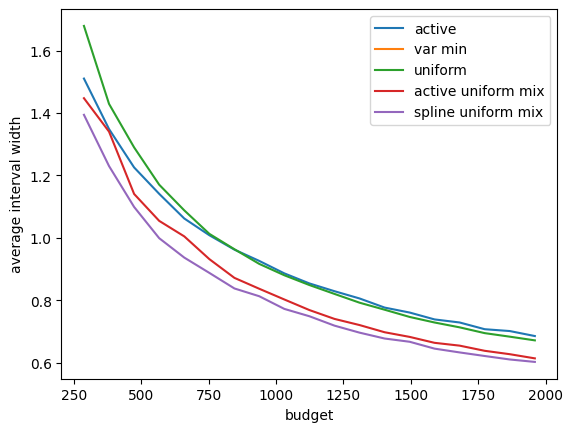

In [106]:
# May 4, older
# analysis/summary of results
df_tuning_corrsampling['coverage'] = df_tuning_corrsampling['coverage'] * 1.0
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_b$']
active_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "active")][relevant_columns].groupby('$n_b$').mean()
varmin_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "spline")][relevant_columns].groupby('$n_b$').mean()
uniform_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "uniform")][relevant_columns].groupby('$n_b$').mean()
activetune_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "active uniform mix")][relevant_columns].groupby('$n_b$').mean()
varmintune_df = df_tuning_corrsampling[(df_tuning_corrsampling["estimator"] == "spline uniform mix")][relevant_columns].groupby('$n_b$').mean()

plt.plot(np.array(active_df.index)[1:], np.array(active_df["interval width"])[1:], label = "active")
plt.plot(np.array(varmin_df.index)[1:], np.array(varmin_df["interval width"])[1:], label = "var min")
plt.plot(np.array(uniform_df.index)[1:], np.array(uniform_df["interval width"])[1:], label = "uniform")
plt.plot(np.array(activetune_df.index)[1:], np.array(activetune_df["interval width"])[1:], label = "active uniform mix")
plt.plot(np.array(varmintune_df.index)[1:], np.array(varmintune_df["interval width"])[1:], label = "spline uniform mix")

#plt.axhline(1, color= "black")
plt.xlabel("budget")
plt.ylabel("average interval width")
plt.legend()
plt.show()



#### spline probabilities

In [44]:
budget = 0.2
n = len(Yhat0_test) + len(Yhat1_test)
total_budget = n * budget
u0_test = Yhat0_test * (1 - Yhat0_test)
u1_test = Yhat1_test * (1 - Yhat1_test)
probs1_spline_inv, probs0_spline_inv, params1_inv, params0_inv = sampling_probs_spline_inv(
        u1_test, u0_test, mu1_init, mu0_init, total_budget, num_knots=5, degree=3
    )

Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.008599242468060314
Total Time: 0.5987 seconds


In [49]:
p1_bin, p0_bin = sampling_probs_constant(u1s, u0s, mu1_init, mu0_init, Ns, budget * n)
p1_constant = p1_bin[labels1]
p0_constant = p0_bin[labels0]

In [45]:
uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
eta0 = budget / np.mean(uncertainty0)
eta1 = budget / np.mean(uncertainty1)
p0_active = eta0 * uncertainty0
p1_active = eta1 * uncertainty1

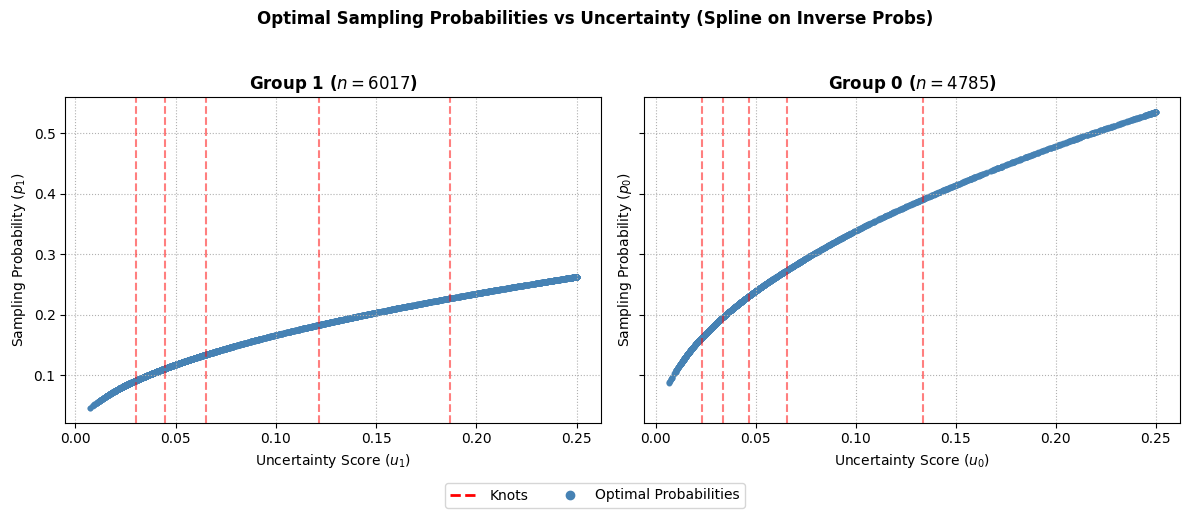

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        
if len(u1_test)>0:
    order1 = np.argsort(u1_test)
    axs[0].scatter(u1_test[order1], probs1_spline_inv[order1], s=10, alpha=0.7, label='Calculated Probs', color="steelblue")
    axs[0].set_title(f'Group 1 ($n={n1}$)', fontweight = "bold")
    axs[0].set_xlabel('Uncertainty Score ($u_1$)')
    axs[0].set_ylabel('Sampling Probability ($p_1$)')
    axs[0].grid(True, linestyle=':')
    if params1_inv and params1_inv['knots'] is not None:
            for knot in params1_inv['knots']:
                axs[0].axvline(knot, color='red', linestyle='--', alpha=0.5, label='knot' if 'knot' not in axs[0].get_legend_handles_labels()[1] else "")
    # axs[0].legend()

if len(u0_test)>0:
    order0 = np.argsort(u0_test)
    axs[1].scatter(u0_test[order0], probs0_spline_inv[order0], s=10, alpha=0.7, label='Calculated Probs', color="steelblue")
    axs[1].set_title(f'Group 0 ($n={n0}$)', fontweight = "bold")
    axs[1].set_xlabel('Uncertainty Score ($u_0$)')
    axs[1].set_ylabel('Sampling Probability ($p_0$)')
    axs[1].grid(True, linestyle=':')
    if params0_inv and params0_inv['knots'] is not None:
            for knot in params0_inv['knots']:
                axs[1].axvline(knot, color='red', linestyle='--', alpha=0.5, label='knot' if 'knot' not in axs[1].get_legend_handles_labels()[1] else "")
    #axs[1].legend()

custom_lines = [
    Line2D([0], [0], color="red", linewidth=2.0, alpha=1.0, linestyle="--", label="Knots"),
    Line2D([0], [0], color="steelblue", marker="o", linestyle="None", label="Optimal Probabilities"),
]
fig.legend(handles=custom_lines, loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.03))


plt.suptitle('Optimal Sampling Probabilities vs Uncertainty (Spline on Inverse Probs)', fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()


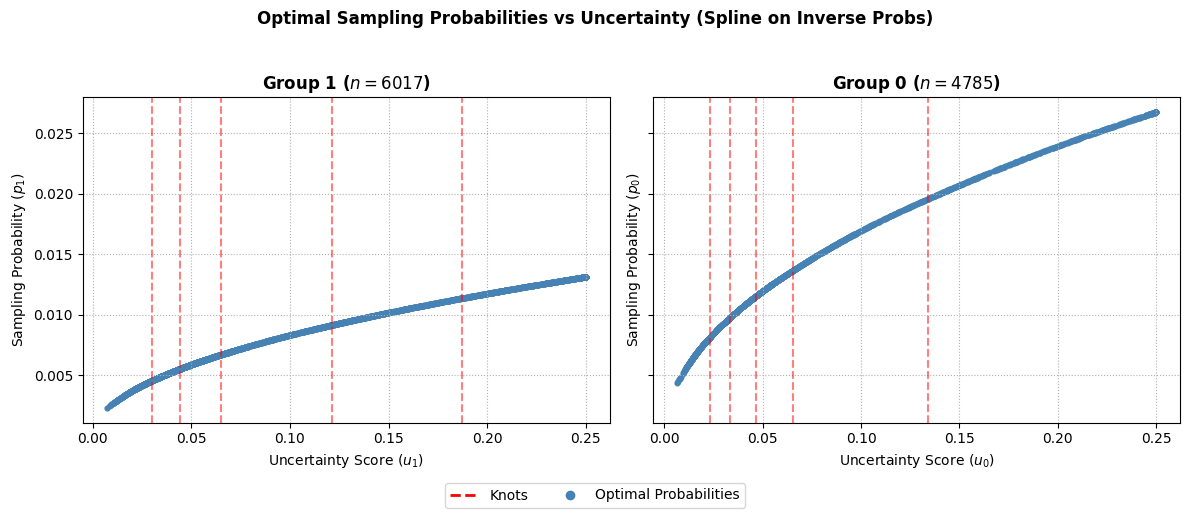

In [40]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        
if len(u1_test)>0:
    order1 = np.argsort(u1_test)
    axs[0].scatter(u1_test[order1], probs1_spline_inv[order1], s=10, alpha=0.7, label='Calculated Probs', color="steelblue")
    axs[0].set_title(f'Group 1 ($n={n1}$)', fontweight = "bold")
    axs[0].set_xlabel('Uncertainty Score ($u_1$)')
    axs[0].set_ylabel('Sampling Probability ($p_1$)')
    axs[0].grid(True, linestyle=':')
    if params1_inv and params1_inv['knots'] is not None:
            for knot in params1_inv['knots']:
                axs[0].axvline(knot, color='red', linestyle='--', alpha=0.5, label='knot' if 'knot' not in axs[0].get_legend_handles_labels()[1] else "")
    # axs[0].legend()

if len(u0_test)>0:
    order0 = np.argsort(u0_test)
    axs[1].scatter(u0_test[order0], probs0_spline_inv[order0], s=10, alpha=0.7, label='Calculated Probs', color="steelblue")
    axs[1].set_title(f'Group 0 ($n={n0}$)', fontweight = "bold")
    axs[1].set_xlabel('Uncertainty Score ($u_0$)')
    axs[1].set_ylabel('Sampling Probability ($p_0$)')
    axs[1].grid(True, linestyle=':')
    if params0_inv and params0_inv['knots'] is not None:
            for knot in params0_inv['knots']:
                axs[1].axvline(knot, color='red', linestyle='--', alpha=0.5, label='knot' if 'knot' not in axs[1].get_legend_handles_labels()[1] else "")
    #axs[1].legend()

custom_lines = [
    Line2D([0], [0], color="red", linewidth=2.0, alpha=1.0, linestyle="--", label="Knots"),
    Line2D([0], [0], color="steelblue", marker="o", linestyle="None", label="Optimal Probabilities"),
]
fig.legend(handles=custom_lines, loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.03))


plt.suptitle('Optimal Sampling Probabilities vs Uncertainty (Spline on Inverse Probs)', fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()


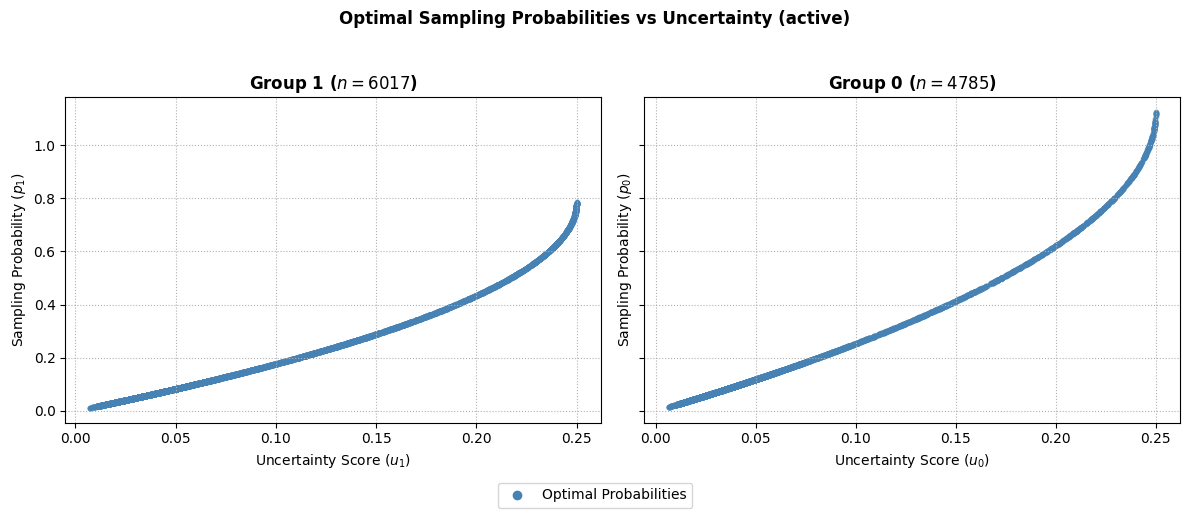

In [51]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        
if len(u1_test)>0:
    order1 = np.argsort(u1_test)
    axs[0].scatter(u1_test[order1], p1_active[order1], s=10, alpha=0.7, label='Calculated Probs', color="steelblue")
    axs[0].set_title(f'Group 1 ($n={n1}$)', fontweight = "bold")
    axs[0].set_xlabel('Uncertainty Score ($u_1$)')
    axs[0].set_ylabel('Sampling Probability ($p_1$)')
    axs[0].grid(True, linestyle=':')
    
if len(u0_test)>0:
    order0 = np.argsort(u0_test)
    axs[1].scatter(u0_test[order0], p0_active[order0], s=10, alpha=0.7, label='Calculated Probs', color="steelblue")
    axs[1].set_title(f'Group 0 ($n={n0}$)', fontweight = "bold")
    axs[1].set_xlabel('Uncertainty Score ($u_0$)')
    axs[1].set_ylabel('Sampling Probability ($p_0$)')
    axs[1].grid(True, linestyle=':')

custom_lines = [
    #Line2D([0], [0], color="red", linewidth=2.0, alpha=1.0, linestyle="--", label="Knots"),
    Line2D([0], [0], color="steelblue", marker="o", linestyle="None", label="Optimal Probabilities"),
]
fig.legend(handles=custom_lines, loc="lower center", ncol=1, fontsize=10, bbox_to_anchor=(0.5, -0.03))


plt.suptitle('Optimal Sampling Probabilities vs Uncertainty (active)', fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()


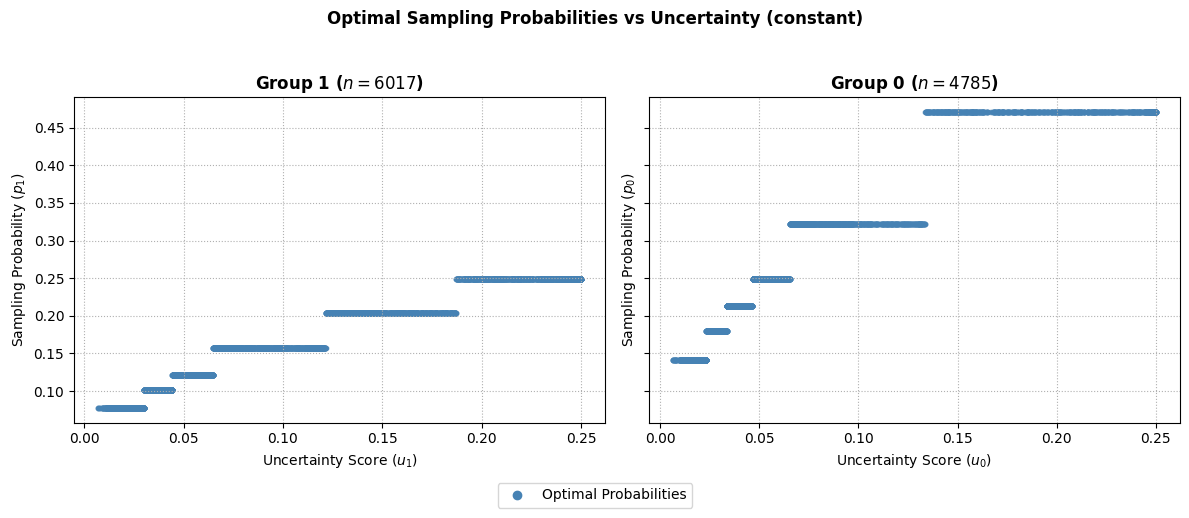

In [54]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        
if len(u1_test)>0:
    order1 = np.argsort(u1_test)
    axs[0].scatter(u1_test[order1], p1_constant[order1], s=10, alpha=0.7, label='Calculated Probs', color="steelblue")
    axs[0].set_title(f'Group 1 ($n={n1}$)', fontweight = "bold")
    axs[0].set_xlabel('Uncertainty Score ($u_1$)')
    axs[0].set_ylabel('Sampling Probability ($p_1$)')
    axs[0].grid(True, linestyle=':')
    
if len(u0_test)>0:
    order0 = np.argsort(u0_test)
    axs[1].scatter(u0_test[order0], p0_constant[order0], s=10, alpha=0.7, label='Calculated Probs', color="steelblue")
    axs[1].set_title(f'Group 0 ($n={n0}$)', fontweight = "bold")
    axs[1].set_xlabel('Uncertainty Score ($u_0$)')
    axs[1].set_ylabel('Sampling Probability ($p_0$)')
    axs[1].grid(True, linestyle=':')

custom_lines = [
    #Line2D([0], [0], color="red", linewidth=2.0, alpha=1.0, linestyle="--", label="Knots"),
    Line2D([0], [0], color="steelblue", marker="o", linestyle="None", label="Optimal Probabilities"),
]
fig.legend(handles=custom_lines, loc="lower center", ncol=1, fontsize=10, bbox_to_anchor=(0.5, -0.03))


plt.suptitle('Optimal Sampling Probabilities vs Uncertainty (constant)', fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()


In [27]:
np.sum(probs1_spline_inv) + np.sum(probs0_spline_inv)

980.1996091831116

In [20]:
np.sum(probs1_spline_inv) + np.sum(probs0_spline_inv)

1960.5376972115328

In [21]:
total_budget

1960.4

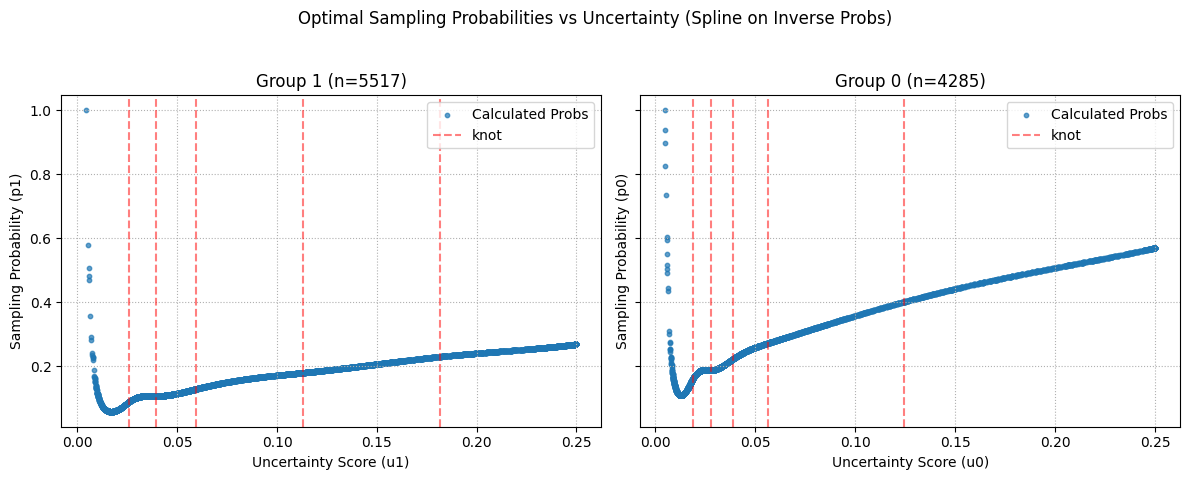

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
        
if len(u1_test)>0:
    order1 = np.argsort(u1_test)
    axs[0].scatter(u1_test[order1], probs1_spline_inv[order1], s=10, alpha=0.7, label='Calculated Probs')
    axs[0].set_title(f'Group 1 (n={n1})')
    axs[0].set_xlabel('Uncertainty Score (u1)')
    axs[0].set_ylabel('Sampling Probability (p1)')
    axs[0].grid(True, linestyle=':')
    if params1_inv and params1_inv['knots'] is not None:
            for knot in params1_inv['knots']:
                axs[0].axvline(knot, color='red', linestyle='--', alpha=0.5, label='knot' if 'knot' not in axs[0].get_legend_handles_labels()[1] else "")
    axs[0].legend()

if len(u0_test)>0:
    order0 = np.argsort(u0_test)
    axs[1].scatter(u0_test[order0], probs0_spline_inv[order0], s=10, alpha=0.7, label='Calculated Probs')
    axs[1].set_title(f'Group 0 (n={n0})')
    axs[1].set_xlabel('Uncertainty Score (u0)')
    axs[1].set_ylabel('Sampling Probability (p0)')
    axs[1].grid(True, linestyle=':')
    if params0_inv and params0_inv['knots'] is not None:
            for knot in params0_inv['knots']:
                axs[1].axvline(knot, color='red', linestyle='--', alpha=0.5, label='knot' if 'knot' not in axs[1].get_legend_handles_labels()[1] else "")
    axs[1].legend()

plt.suptitle('Optimal Sampling Probabilities vs Uncertainty (Spline on Inverse Probs)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()


In [51]:
lambda_star, vars_avg = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, probs0_spline_inv, probs1_spline_inv,
                                    alpha, budget, 1, 1)

Best λ = 0.55 with Avg Var = 0.007283


In [53]:
budget = 0.1
n1, n0 = len(Yhat1_test), len(Yhat0_test)
n = n1 + n0
uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
eta0 = budget / np.mean(uncertainty0)
eta1 = budget / np.mean(uncertainty1)
p0_active = eta0 * uncertainty0
p1_active = eta1 * uncertainty1
p1_bin, p0_bin = sampling_probs_constant(u1s, u0s, mu1_init, mu0_init, Ns, budget * n)
p1_constant = p1_bin[labels1]
p0_constant = p0_bin[labels0]
lambda_star, vars_avg = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_constant, p1_constant,
                                    alpha, budget, 1, 1)

Best λ = 0.45 with Avg Var = 0.012601


In [56]:
budgets

array([0.02      , 0.02947368, 0.03894737, 0.04842105, 0.05789474,
       0.06736842, 0.07684211, 0.08631579, 0.09578947, 0.10526316,
       0.11473684, 0.12421053, 0.13368421, 0.14315789, 0.15263158,
       0.16210526, 0.17157895, 0.18105263, 0.19052632, 0.2       ])

In [78]:
# trying with much larger budget
#budgets = np.array([0.05, 0.1, 0.15, 0.2])
budgets = np.linspace(0.02, 0.2, 20)
#budgets = np.array([0.2])
#budget = 0.05
#fracs = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
#fracs = np.array([0.1, 0.2])
alpha = 0.1
num_trials = 1000
results = []
results_corrsampling = []
#columns = ["estimate", "lb", "ub", "interval width", "coverage", "estimator", "$n_b$"]
columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_b$"] # number labeled in group 1
#columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_{\mathrm{human}}$", "$n_{\mathrm{eff}}$"] # number labeled in group 1
#temp_df = pd.DataFrame(np.zeros((3, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
temp_df_corrsampling = pd.DataFrame(np.zeros((5, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
#temp_df = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
n1, n0 = Yhat1_test.shape[0], Yhat0_test.shape[0]
n = n1 + n0
p1_G_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_G_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_T_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_T_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_M_sim1  = np.zeros((len(budgets), ce1_test.shape[0])) #mixture
p0_M_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
lambdas = np.ones(len(budgets))

for j in range(len(budgets)):
    budget = budgets[j]
    # active
    uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
    uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
    eta0 = budget / np.mean(uncertainty0)
    eta1 = budget / np.mean(uncertainty1)
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1

    p1_spline, p0_spline, params1_inv, params0_inv = sampling_probs_spline_inv(
        u1_test, u0_test, mu1_init, mu0_init, n * budget, num_knots=5, degree=3
    )
    #lambda_star, vars_avg = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_constant, p1_constant,
    #                                alpha, budget, 1, 1)
    lambda_star, vars_avg = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_spline, p1_spline,
                                    alpha, budget, 1, 1)
    lambdas[j] = lambda_star
    tau = 0.5

    for k in tqdm(range(num_trials)):
        l_A, u_A, v_A, p0_a, p1_a, label0_A, label1_A, l_S, u_S, v_S, p0_m, p1_m, label0_V, label1_V  = sample_ci(Y0_test.ravel(), Yhat0_test.ravel(), Y1_test.ravel(), Yhat1_test.ravel(), p0_active, p1_active, p0_spline, p1_spline, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l_A)*(OR_true <= u_A)   
        temp_df_corrsampling.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(budget*n)  
        coverage_var = (OR_true >= l_S)*(OR_true <= u_S)   
        temp_df_corrsampling.loc[1] = l_S, u_S, u_S-l_S, coverage_var, "var. min.", int(budget*n)  

        l_M, u_M, var_M = sample_ci_mixture(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_spline, p1_spline, alpha, budget, 1, 1, lambda_star)
        coverage_mix = (OR_true >= l_M) * (OR_true <= u_M)
        temp_df_corrsampling.loc[2] = l_M, u_M, u_M - l_M, coverage_mix, "power tuning", int(budget * n)

        p1_unif, p0_unif = budget * np.ones(n1), budget * np.ones(n0)
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l)*(OR_true <= u)  
        temp_df_corrsampling.loc[3] = l, u, u-l, coverage_active, "uniform", int(budget*n)  
        
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=0, lhat1=0)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        temp_df_corrsampling.loc[4] = l, u, u-l, coverage_active, "classical", int(budget*n)  
        results_corrsampling += [temp_df_corrsampling.copy()]
        
        #if ((k+1) % 10) == 0:
            #clear_output(wait=True)
            #print(f"Finished Iteration {k + 1}")
#df_sim3 = pd.concat(results, ignore_index = True)
df_spline_corrsampling = pd.concat(results_corrsampling, ignore_index = True)

Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.08599241298204988
Total Time: 0.6458 seconds
Best λ = 0.90 with Avg Var = 0.054246


100%|██████████| 1000/1000 [00:03<00:00, 272.78it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.05835199502969416
Total Time: 0.6299 seconds
Best λ = 0.75 with Avg Var = 0.037791


100%|██████████| 1000/1000 [00:02<00:00, 350.12it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.04415828266756351
Total Time: 0.6645 seconds
Best λ = 0.55 with Avg Var = 0.029415


...

100%|██████████| 1000/1000 [00:03<00:00, 297.87it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.009026829488484869
Total Time: 0.5181 seconds
Best λ = 0.50 with Avg Var = 0.007579


100%|██████████| 1000/1000 [00:03<00:00, 330.89it/s]


Attempting to solve with MOSEK...
Passing kwargs to MOSEK: {'gp': False, 'verbose': False}
MOSEK finished with status: optimal
Optimization successful (Final Status: optimal). Objective value: 0.008599242468060314
Total Time: 0.5347 seconds
Best λ = 0.50 with Avg Var = 0.007307


100%|██████████| 1000/1000 [00:03<00:00, 312.06it/s]


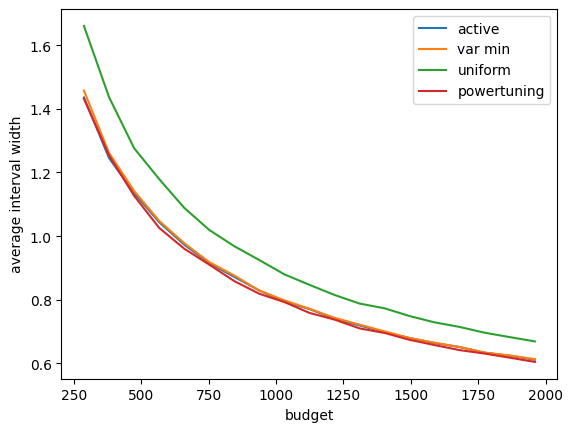

In [79]:
# April 27
# analysis/summary of results
df_spline_corrsampling['coverage'] = df_spline_corrsampling['coverage'] * 1.0
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_b$']
active_df = df_spline_corrsampling[(df_spline_corrsampling["estimator"] == "active")][relevant_columns].groupby('$n_b$').mean()
varmin_df = df_spline_corrsampling[(df_spline_corrsampling["estimator"] == "var. min.")][relevant_columns].groupby('$n_b$').mean()
uniform_df = df_spline_corrsampling[(df_spline_corrsampling["estimator"] == "uniform")][relevant_columns].groupby('$n_b$').mean()
powertune_df = df_spline_corrsampling[(df_spline_corrsampling["estimator"] == "power tuning")][relevant_columns].groupby('$n_b$').mean()

plt.plot(np.array(active_df.index)[1:], np.array(active_df["interval width"])[1:], label = "active")
plt.plot(np.array(varmin_df.index)[1:], np.array(varmin_df["interval width"])[1:], label = "var min")
plt.plot(np.array(uniform_df.index)[1:], np.array(uniform_df["interval width"])[1:], label = "uniform")
plt.plot(np.array(powertune_df.index)[1:], np.array(powertune_df["interval width"])[1:], label = "powertuning")

#plt.axhline(1, color= "black")
plt.xlabel("budget")
plt.ylabel("average interval width")
plt.legend()
plt.show()


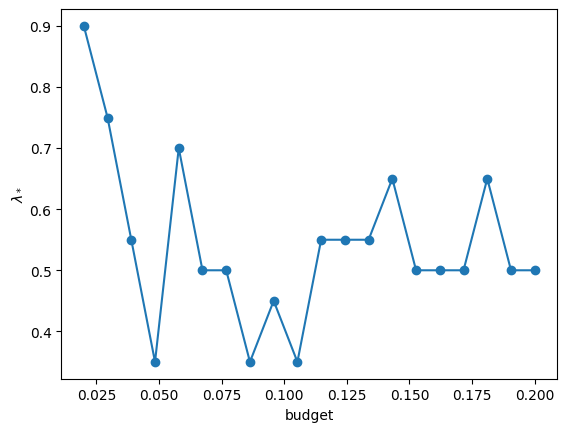

In [80]:
# April 28
plt.scatter(budgets, lambdas)
plt.plot(budgets, lambdas)
plt.xlabel("budget")
plt.ylabel(r'$\lambda_*$')
plt.show()

In [43]:
# trying with much larger budget
#budgets = np.array([0.05, 0.1, 0.15, 0.2])
budgets = np.linspace(0.02, 0.2, 20)
#budgets = np.array([0.2])
#budget = 0.05
#fracs = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
#fracs = np.array([0.1, 0.2])
alpha = 0.1
num_trials = 1000
results = []
results_corrsampling = []
#columns = ["estimate", "lb", "ub", "interval width", "coverage", "estimator", "$n_b$"]
columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_b$"] # number labeled in group 1
#columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_{\mathrm{human}}$", "$n_{\mathrm{eff}}$"] # number labeled in group 1
#temp_df = pd.DataFrame(np.zeros((3, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
temp_df_corrsampling = pd.DataFrame(np.zeros((5, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
#temp_df = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
n1, n0 = Yhat1_test.shape[0], Yhat0_test.shape[0]
n = n1 + n0
p1_G_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_G_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_T_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_T_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_M_sim1  = np.zeros((len(budgets), ce1_test.shape[0])) #mixture
p0_M_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))

for j in range(len(budgets)):
    budget = budgets[j]
    # active
    uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
    uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
    eta0 = budget / np.mean(uncertainty0)
    eta1 = budget / np.mean(uncertainty1)
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1

    p1_spline, p0_spline, params1_inv, params0_inv = sampling_probs_spline_inv(
        u1_test, u0_test, mu1_init, mu0_init, n * budget, num_knots=5, degree=3
    )
    #lambda_star, vars_avg = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_constant, p1_constant,
    #                                alpha, budget, 1, 1)
    lambda_star, vars_avg = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_spline, p1_spline,
                                    alpha, budget, 1, 1)
    
    tau = 0.5

    for k in tqdm(range(num_trials)):
        l_A, u_A, v_A, p0_a, p1_a, label0_A, label1_A, l_S, u_S, v_S, p0_m, p1_m, label0_V, label1_V  = sample_ci(Y0_test.ravel(), Yhat0_test.ravel(), Y1_test.ravel(), Yhat1_test.ravel(), p0_active, p1_active, p0_spline, p1_spline, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l_A)*(OR_true <= u_A)   
        temp_df_corrsampling.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(budget*n)  
        coverage_var = (OR_true >= l_S)*(OR_true <= u_S)   
        temp_df_corrsampling.loc[1] = l_S, u_S, u_S-l_S, coverage_var, "var. min.", int(budget*n)  

        l_M, u_M, var_M = sample_ci_mixture(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_spline, p1_spline, alpha, budget, 1, 1, lambda_star)
        coverage_mix = (OR_true >= l_M) * (OR_true <= u_M)
        temp_df_corrsampling.loc[2] = l_M, u_M, u_M - l_M, coverage_mix, "power tuning", int(budget * n)

        p1_unif, p0_unif = budget * np.ones(n1), budget * np.ones(n0)
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l)*(OR_true <= u)  
        temp_df_corrsampling.loc[3] = l, u, u-l, coverage_active, "uniform", int(budget*n)  
        
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=0, lhat1=0)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        temp_df_corrsampling.loc[4] = l, u, u-l, coverage_active, "classical", int(budget*n)  
        results_corrsampling += [temp_df_corrsampling.copy()]
        
        #if ((k+1) % 10) == 0:
            #clear_output(wait=True)
            #print(f"Finished Iteration {k + 1}")
#df_sim3 = pd.concat(results, ignore_index = True)
df_spline_corrsampling = pd.concat(results_corrsampling, ignore_index = True)

Failure:interrupted
SCS solver failed (Solver 'SCS' failed. Try another solver, or solve with verbose=True for more information.), trying ECOS...
Optimization successful (Status: optimal_inaccurate). Objective value: 0.08471988006318762
Best λ = 1.00 with Avg Var = 0.054005


100%|██████████| 1000/1000 [00:04<00:00, 221.61it/s]


Optimization successful (Status: optimal). Objective value: 0.054777313284880974
Best λ = 0.65 with Avg Var = 0.037982


100%|██████████| 1000/1000 [00:04<00:00, 225.64it/s]


Optimization successful (Status: optimal). Objective value: 0.04108384938483895
Best λ = 0.80 with Avg Var = 0.029406


...

100%|██████████| 1000/1000 [00:02<00:00, 348.98it/s]


Optimization successful (Status: optimal). Objective value: 0.008182738692635071
Best λ = 0.35 with Avg Var = 0.007539


100%|██████████| 1000/1000 [00:02<00:00, 357.35it/s]


Optimization successful (Status: optimal). Objective value: 0.007791284568359336
Best λ = 0.50 with Avg Var = 0.007276


100%|██████████| 1000/1000 [00:02<00:00, 346.22it/s]


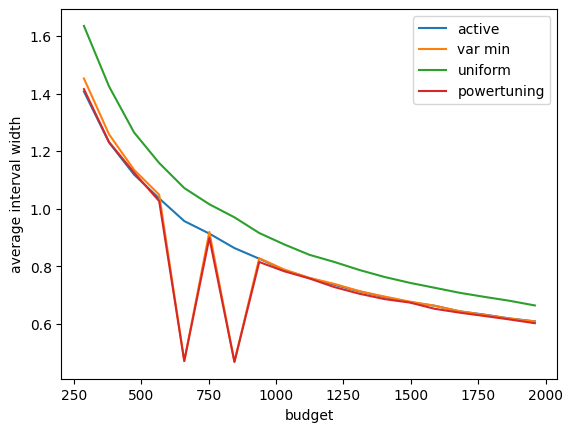

In [44]:
# April 27
# analysis/summary of results
df_spline_corrsampling['coverage'] = df_spline_corrsampling['coverage'] * 1.0
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_b$']
active_df = df_spline_corrsampling[(df_spline_corrsampling["estimator"] == "active")][relevant_columns].groupby('$n_b$').mean()
varmin_df = df_spline_corrsampling[(df_spline_corrsampling["estimator"] == "var. min.")][relevant_columns].groupby('$n_b$').mean()
uniform_df = df_spline_corrsampling[(df_spline_corrsampling["estimator"] == "uniform")][relevant_columns].groupby('$n_b$').mean()
powertune_df = df_spline_corrsampling[(df_spline_corrsampling["estimator"] == "power tuning")][relevant_columns].groupby('$n_b$').mean()

plt.plot(np.array(active_df.index)[1:], np.array(active_df["interval width"])[1:], label = "active")
plt.plot(np.array(varmin_df.index)[1:], np.array(varmin_df["interval width"])[1:], label = "var min")
plt.plot(np.array(uniform_df.index)[1:], np.array(uniform_df["interval width"])[1:], label = "uniform")
plt.plot(np.array(powertune_df.index)[1:], np.array(powertune_df["interval width"])[1:], label = "powertuning")

#plt.axhline(1, color= "black")
plt.xlabel("budget")
plt.ylabel("average interval width")
plt.legend()
plt.show()


In [69]:
budget = 0.2
p1_linear, p0_linear = sampling_probs_linear(Yhat1_test, Yhat0_test, labels1, labels0, mu1_init, mu0_init, Ns, budget)

In [ ]:
np.sum(p1_linear) + np.sum(p0_linear)

In [ ]:
# p(Z1) = 0.9
# trying with much larger budget
#budgets = np.array([0.05, 0.1, 0.15, 0.2])
budgets = np.linspace(0.02, 0.2, 20)
#budgets = np.array([0.2])
#budget = 0.05
#fracs = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
#fracs = np.array([0.1, 0.2])
alpha = 0.1
num_trials = 1000
results = []
results_corrsampling = []
#columns = ["estimate", "lb", "ub", "interval width", "coverage", "estimator", "$n_b$"]
columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_b$"] # number labeled in group 1
#columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_{\mathrm{human}}$", "$n_{\mathrm{eff}}$"] # number labeled in group 1
#temp_df = pd.DataFrame(np.zeros((3, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
temp_df_corrsampling = pd.DataFrame(np.zeros((5, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
#temp_df = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
n1, n0 = Yhat1_test.shape[0], Yhat0_test.shape[0]
n = n1 + n0
p1_G_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_G_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_T_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_T_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_M_sim1  = np.zeros((len(budgets), ce1_test.shape[0])) #mixture
p0_M_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))

for j in range(len(budgets)):
    budget = budgets[j]
    # active
    uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
    uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
    eta0 = budget / np.mean(uncertainty0)
    eta1 = budget / np.mean(uncertainty1)
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1

    p1_bin, p0_bin = sampling_probs_constant(u1s, u0s, mu1_init, mu0_init, Ns, budget * n)
    p1_constant = p1_bin[labels1]
    p0_constant = p0_bin[labels0]
    lambda_star, vars_avg = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_constant, p1_constant,
                                    alpha, budget, 1, 1)
    
    tau = 0.5
    # p1_G_sim1[j, :] = np.clip(tau * p1_spline + (1-tau)*budget, 0, 1)
    # p1_T_sim1[j, :] = np.clip(tau * p1_active + (1-tau)*budget, 0, 1)
    # p0_G_sim1[j, :] = np.clip(tau * p0_spline + (1-tau)*budget, 0, 1)
    # p0_T_sim1[j, :] = np.clip(tau * p0_active + (1-tau)*budget, 0, 1)
    # p1_M_sim1[j, :] = np.clip(tau * p1_mix + (1 - tau) * budget, 0, 1)
    # p0_M_sim1[j, :] = np.clip(tau * p0_mix + (1 - tau) * budget, 0, 1)

    for k in tqdm(range(num_trials)):
        l_A, u_A, v_A, p0_a, p1_a, label0_A, label1_A, l_S, u_S, v_S, p0_m, p1_m, label0_V, label1_V  = sample_ci(Y0_test.ravel(), Yhat0_test.ravel(), Y1_test.ravel(), Yhat1_test.ravel(), p0_active, p1_active, p0_constant, p1_constant, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l_A)*(OR_true <= u_A)   
        temp_df_corrsampling.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(budget*n)  
        coverage_var = (OR_true >= l_S)*(OR_true <= u_S)   
        temp_df_corrsampling.loc[1] = l_S, u_S, u_S-l_S, coverage_var, "var. min.", int(budget*n)  

        l_M, u_M, var_M = sample_ci_mixture(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_constant, p1_constant, alpha, budget, 1, 1, lambda_star)
        coverage_mix = (OR_true >= l_M) * (OR_true <= u_M)
        temp_df_corrsampling.loc[2] = l_M, u_M, u_M - l_M, coverage_mix, "power tuning", int(budget * n)

        p1_unif, p0_unif = budget * np.ones(n1), budget * np.ones(n0)
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l)*(OR_true <= u)  
        temp_df_corrsampling.loc[3] = l, u, u-l, coverage_active, "uniform", int(budget*n)  
        
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=0, lhat1=0)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        temp_df_corrsampling.loc[4] = l, u, u-l, coverage_active, "classical", int(budget*n)  
        results_corrsampling += [temp_df_corrsampling.copy()]
        
        #if ((k+1) % 10) == 0:
            #clear_output(wait=True)
            #print(f"Finished Iteration {k + 1}")
#df_sim3 = pd.concat(results, ignore_index = True)
df_sim1_corrsampling = pd.concat(results_corrsampling, ignore_index = True)

In [36]:
# trying with much larger budget
#budgets = np.array([0.05, 0.1, 0.15, 0.2])
budgets = np.linspace(0.02, 0.2, 20)
#budgets = np.array([0.2])
#budget = 0.05
#fracs = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
#fracs = np.array([0.1, 0.2])
alpha = 0.1
num_trials = 1000
results = []
results_corrsampling = []
#columns = ["estimate", "lb", "ub", "interval width", "coverage", "estimator", "$n_b$"]
columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_b$"] # number labeled in group 1
#columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_{\mathrm{human}}$", "$n_{\mathrm{eff}}$"] # number labeled in group 1
#temp_df = pd.DataFrame(np.zeros((3, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
temp_df_corrsampling = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
#temp_df = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
n = ce1_test.shape[0] + ce0_test.shape[0]
p1_G_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_G_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_T_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_T_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))

for j in range(len(budgets)):
    budget = budgets[j]
    # active
    uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
    uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
    eta0 = budget / np.mean(uncertainty0)
    eta1 = budget / np.mean(uncertainty1)
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1

    p1_spline, p0_spline, v1, v0, a1, a0 = sampling_probs_spline(Yhat1_test, Yhat0_test, Yhat1_test, Yhat0_test, mu1_init, mu0_init, budget, 10)
    
    tau = 0.5
    p1_G_sim1[j, :] = np.clip(tau * p1_spline + (1-tau)*budget, 0, 1)
    p1_T_sim1[j, :] = np.clip(tau * p1_active + (1-tau)*budget, 0, 1)
    p0_G_sim1[j, :] = np.clip(tau * p0_spline + (1-tau)*budget, 0, 1)
    p0_T_sim1[j, :] = np.clip(tau * p0_active + (1-tau)*budget, 0, 1)
    for k in tqdm(range(num_trials)):
        l_A, u_A, v_A, p0_a, p1_a, label0_A, label1_A, l_S, u_S, v_S, p0_m, p1_m, label0_V, label1_V  = sample_ci(Y0_test.ravel(), Yhat0_test.ravel(), Y1_test.ravel(), Yhat1_test.ravel(), p0_active, p1_active, p0_spline, p1_spline, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l_A)*(OR_true <= u_A)   
        temp_df_corrsampling.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(budget*n)  
        coverage_var = (OR_true >= l_S)*(OR_true <= u_S)   
        temp_df_corrsampling.loc[1] = l_S, u_S, u_S-l_S, coverage_var, "var. min.", int(budget*n)  

        p1_unif, p0_unif = budget * np.ones(ce1_test.shape[0]), budget * np.ones(ce0_test.shape[0])
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l)*(OR_true <= u)  
        temp_df_corrsampling.loc[2] = l, u, u-l, coverage_active, "uniform", int(budget*n)  
        
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=0, lhat1=0)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        temp_df_corrsampling.loc[3] = l, u, u-l, coverage_active, "classical", int(budget*n)  
        results_corrsampling += [temp_df_corrsampling.copy()]
        
        #if ((k+1) % 10) == 0:
            #clear_output(wait=True)
            #print(f"Finished Iteration {k + 1}")
#df_sim3 = pd.concat(results, ignore_index = True)
df_sim1_corrsampling = pd.concat(results_corrsampling, ignore_index = True)

100%|██████████| 1000/1000 [00:02<00:00, 344.94it/s]


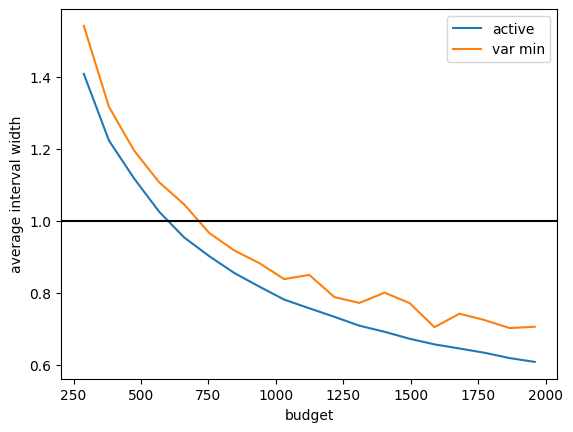

In [38]:
# analysis/summary of results
df_sim1_corrsampling['coverage'] = df_sim1_corrsampling['coverage'] * 1.0
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_b$']
active_df = df_sim1_corrsampling[(df_sim1_corrsampling["estimator"] == "active")][relevant_columns].groupby('$n_b$').mean()
varmin_df = df_sim1_corrsampling[(df_sim1_corrsampling["estimator"] == "var. min.")][relevant_columns].groupby('$n_b$').mean()
plt.plot(np.array(active_df.index)[1:], np.array(active_df["interval width"])[1:], label = "active")
plt.plot(np.array(varmin_df.index)[1:], np.array(varmin_df["interval width"])[1:], label = "var min")
plt.axhline(1, color= "black")
plt.xlabel("budget")
plt.ylabel("average interval width")
plt.legend()
plt.show()


In [25]:
lambdas = np.linspace(0, 1, 21) # grid of tuning parameters
variances = []

budget = 0.2
alpha = 0.1
# active
uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
eta0 = budget / np.mean(uncertainty0)
eta1 = budget / np.mean(uncertainty1)
p0_active = eta0 * uncertainty0
p1_active = eta1 * uncertainty1

p1_spline, p0_spline, v1, v0, a1, a0 = sampling_probs_spline(Yhat1_test, Yhat0_test, Yhat1_test, Yhat0_test, mu1_init, mu0_init, budget, 10)
p1_spline, p0_spline = rescale_probs(p1_spline, p0_spline, budget)


In [27]:
np.sum(p1_spline) + np.sum(p0_spline)

1960.4

In [26]:
np.sum(p1_active) + np.sum(p0_active)

1960.4

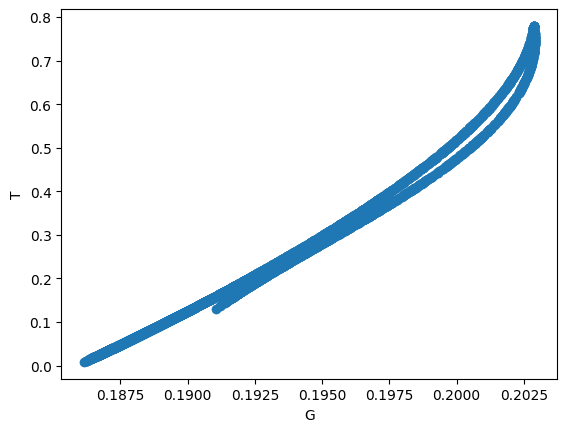

In [29]:
plt.scatter(p1_spline, p1_active)
plt.xlabel("G")
plt.ylabel("T")
plt.show()

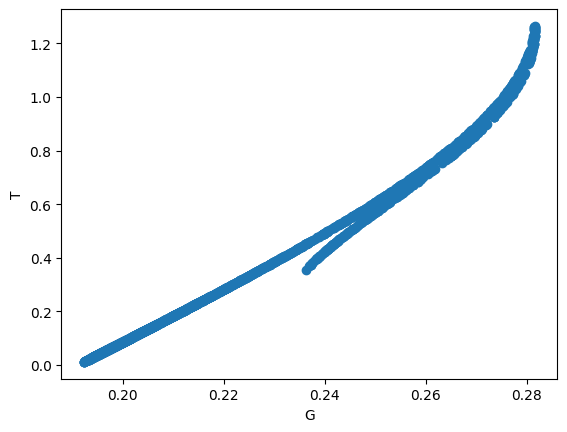

In [30]:
plt.scatter(p0_spline, p0_active)
plt.xlabel("G")
plt.ylabel("T")
plt.show()

In [ ]:
tau = 0.5
for lam in lambdas:
    _, _, var = sample_ci_mixture(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active,
                                  p0_spline, p1_spline, alpha, budget, 1, 1, lam)
    variances.append(var)

best_lambda = lambdas[np.argmin(variances)]


In [32]:
def tune_lambda(Y0, Yhat0, Y1, Yhat1, probs0_A, probs1_A, probs0_B, probs1_B,
                alpha, budget, lhat0, lhat1, lambdas=np.linspace(0, 1, 21), K=1000):
    avg_vars = []
    for lam in lambdas:
        vars_lam = []
        for _ in range(K):
            _, _, var = sample_ci_mixture(Y0, Yhat0, Y1, Yhat1, probs0_A, probs1_A, probs0_B, probs1_B, alpha, budget, lhat0, lhat1, lam)
            vars_lam.append(var)
        avg_var = np.mean(vars_lam)
        avg_vars.append(avg_var)
        #print(f"λ = {lam:.2f}, Avg Var = {avg_var:.6f}")
    
    best_idx = np.argmin(avg_vars)
    best_lambda = lambdas[best_idx]
    print(f"Best λ = {best_lambda:.2f} with Avg Var = {avg_vars[best_idx]:.6f}")
    
    return best_lambda, avg_vars


In [ ]:
budget = 0.05
lambda_star, var_avgs = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_spline, p1_spline, 
                                    alpha, budget, 1, 1)

In [ ]:
budget = 0.2
alpha = 0.1
# active
uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
eta0 = budget / np.mean(uncertainty0)
eta1 = budget / np.mean(uncertainty1)
p0_active = eta0 * uncertainty0
p1_active = eta1 * uncertainty1

p1_spline, p0_spline, v1, v0, a1, a0 = sampling_probs_spline(Yhat1_test, Yhat0_test, Yhat1_test, Yhat0_test, mu1_init, mu0_init, budget, 10)
p1_spline, p0_spline = rescale_probs(p1_spline, p0_spline, budget)

Best λ = 0.45 with Avg Var = 0.010628


In [36]:
budget = 0.1
lambda_star, var_avgs = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_spline, p1_spline, 
                                    alpha, budget, 1, 1)

Best λ = 0.60 with Avg Var = 0.009165


In [35]:
budget = 0.2
lambda_star, var_avgs = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_spline, p1_spline, 
                                    alpha, budget, 1, 1)

Best λ = 0.85 with Avg Var = 0.007382


In [49]:
alpha

0.1

In [ ]:
budget = 0.2
budget = budgets[j]
# active
uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
eta0 = budget / np.mean(uncertainty0)
eta1 = budget / np.mean(uncertainty1)
p0_active = eta0 * uncertainty0
p1_active = eta1 * uncertainty1

p1_spline, p0_spline, v1, v0, a1, a0 = sampling_probs_spline(Yhat1_test, Yhat0_test, Yhat1_test, Yhat0_test, mu1_init, mu0_init, budget, 10)

In [60]:
budget = 0.05
lambda_star, var_avgs = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_spline, p1_spline, 
                                    alpha, budget, 1, 1)

Best λ = 0.90 with Avg Var = 0.011200


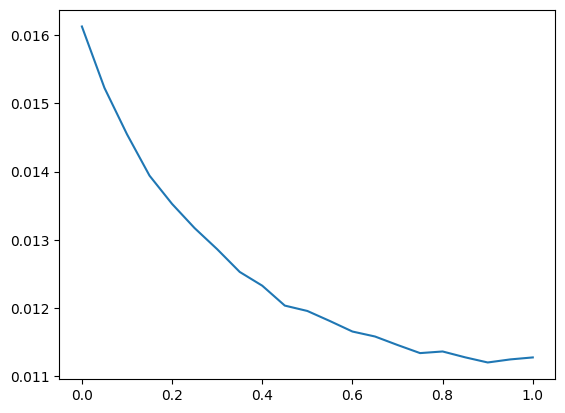

In [61]:
plt.plot(lambdas, var_avgs)
plt.show()

In [39]:
# trying with much larger budget
#budgets = np.array([0.05, 0.1, 0.15, 0.2])
budgets = np.linspace(0.02, 0.2, 20)
#budgets = np.array([0.2])
#budget = 0.05
#fracs = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
#fracs = np.array([0.1, 0.2])
alpha = 0.1
num_trials = 1000
results = []
results_corrsampling = []
#columns = ["estimate", "lb", "ub", "interval width", "coverage", "estimator", "$n_b$"]
columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_b$"] # number labeled in group 1
#columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_{\mathrm{human}}$", "$n_{\mathrm{eff}}$"] # number labeled in group 1
#temp_df = pd.DataFrame(np.zeros((3, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
temp_df_corrsampling = pd.DataFrame(np.zeros((5, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
#temp_df = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
n = ce1_test.shape[0] + ce0_test.shape[0]
p1_G_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_G_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_T_sim1  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_T_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_M_sim1  = np.zeros((len(budgets), ce1_test.shape[0])) #mixture
p0_M_sim1  = np.zeros((len(budgets), ce0_test.shape[0]))

for j in range(len(budgets)):
    budget = budgets[j]
    # active
    uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
    uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
    eta0 = budget / np.mean(uncertainty0)
    eta1 = budget / np.mean(uncertainty1)
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1

    p1_spline, p0_spline, v1, v0, a1, a0 = sampling_probs_spline(Yhat1_test, Yhat0_test, Yhat1_test, Yhat0_test, mu1_init, mu0_init, budget, 10)
    p1_spline, p0_spline = rescale_probs(p1_spline, p0_spline, budget)
    lambda_star, var_avgs = tune_lambda(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_spline, p1_spline, 
                                        alpha, budget, 1, 1)
    p1_mix = p1_active * lambda_star + (1 - lambda_star) * p1_spline
    p0_mix = p0_active * lambda_star + (1 - lambda_star) * p0_spline

    tau = 0.5
    p1_G_sim1[j, :] = np.clip(tau * p1_spline + (1-tau)*budget, 0, 1)
    p1_T_sim1[j, :] = np.clip(tau * p1_active + (1-tau)*budget, 0, 1)
    p0_G_sim1[j, :] = np.clip(tau * p0_spline + (1-tau)*budget, 0, 1)
    p0_T_sim1[j, :] = np.clip(tau * p0_active + (1-tau)*budget, 0, 1)
    p1_M_sim1[j, :] = np.clip(tau * p1_mix + (1 - tau) * budget, 0, 1)
    p0_M_sim1[j, :] = np.clip(tau * p0_mix + (1 - tau) * budget, 0, 1)

    for k in tqdm(range(num_trials)):
        l_A, u_A, v_A, p0_a, p1_a, label0_A, label1_A, l_S, u_S, v_S, p0_m, p1_m, label0_V, label1_V  = sample_ci(Y0_test.ravel(), Yhat0_test.ravel(), Y1_test.ravel(), Yhat1_test.ravel(), p0_active, p1_active, p0_spline, p1_spline, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l_A)*(OR_true <= u_A)   
        temp_df_corrsampling.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(budget*n)  
        coverage_var = (OR_true >= l_S)*(OR_true <= u_S)   
        temp_df_corrsampling.loc[1] = l_S, u_S, u_S-l_S, coverage_var, "var. min.", int(budget*n)  

        l_M, u_M, var_M = sample_ci_mixture(Y0_test, Yhat0_test, Y1_test, Yhat1_test, p0_active, p1_active, p0_spline, p1_spline, alpha, budget, 1, 1, lambda_star)
        coverage_mix = (OR_true >= l_M) * (OR_true <= u_M)
        temp_df_corrsampling.loc[2] = l_M, u_M, u_M - l_M, coverage_mix, "power tuning", int(budget * n)

        p1_unif, p0_unif = budget * np.ones(ce1_test.shape[0]), budget * np.ones(ce0_test.shape[0])
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l)*(OR_true <= u)  
        temp_df_corrsampling.loc[3] = l, u, u-l, coverage_active, "uniform", int(budget*n)  
        
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=0, lhat1=0)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        temp_df_corrsampling.loc[4] = l, u, u-l, coverage_active, "classical", int(budget*n)  
        results_corrsampling += [temp_df_corrsampling.copy()]
        
        #if ((k+1) % 10) == 0:
            #clear_output(wait=True)
            #print(f"Finished Iteration {k + 1}")
#df_sim3 = pd.concat(results, ignore_index = True)
df_sim1_corrsampling = pd.concat(results_corrsampling, ignore_index = True)

Best λ = 0.90 with Avg Var = 0.054235


100%|██████████| 1000/1000 [00:05<00:00, 183.72it/s]


Best λ = 0.80 with Avg Var = 0.038029


100%|██████████| 1000/1000 [00:06<00:00, 154.70it/s]


Best λ = 0.75 with Avg Var = 0.029346


...

100%|██████████| 1000/1000 [00:05<00:00, 168.83it/s]


Best λ = 0.95 with Avg Var = 0.007645


100%|██████████| 1000/1000 [00:05<00:00, 182.15it/s]


Best λ = 0.90 with Avg Var = 0.007383


100%|██████████| 1000/1000 [00:05<00:00, 179.81it/s]


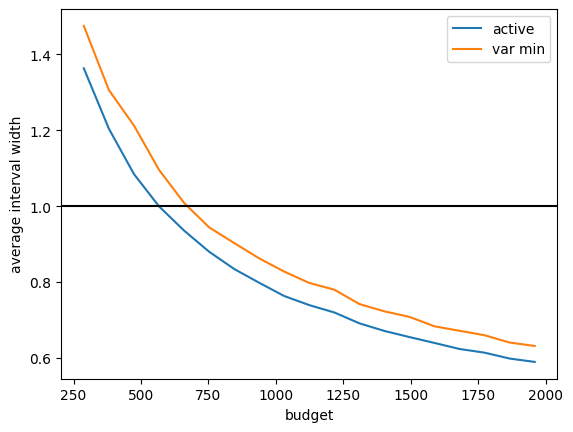

In [38]:
# analysis/summary of results
df_sim1_corrsampling['coverage'] = df_sim1_corrsampling['coverage'] * 1.0
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_b$']
active_df = df_sim1_corrsampling[(df_sim1_corrsampling["estimator"] == "active")][relevant_columns].groupby('$n_b$').mean()
varmin_df = df_sim1_corrsampling[(df_sim1_corrsampling["estimator"] == "var. min.")][relevant_columns].groupby('$n_b$').mean()
plt.plot(np.array(active_df.index)[1:], np.array(active_df["interval width"])[1:], label = "active")
plt.plot(np.array(varmin_df.index)[1:], np.array(varmin_df["interval width"])[1:], label = "var min")
plt.axhline(1, color= "black")
plt.xlabel("budget")
plt.ylabel("average interval width")
plt.legend()
plt.show()


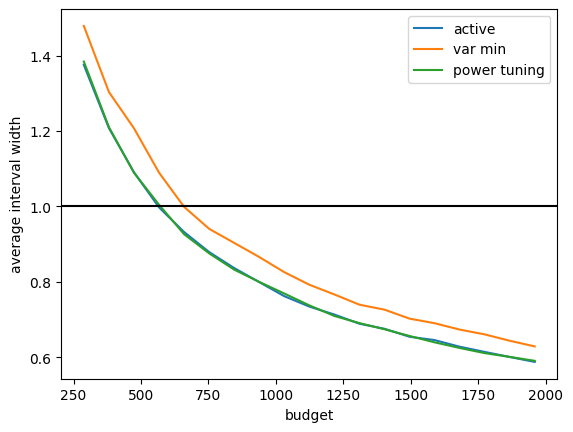

In [40]:
# analysis/summary of results
df_sim1_corrsampling['coverage'] = df_sim1_corrsampling['coverage'] * 1.0
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_b$']
active_df = df_sim1_corrsampling[(df_sim1_corrsampling["estimator"] == "active")][relevant_columns].groupby('$n_b$').mean()
varmin_df = df_sim1_corrsampling[(df_sim1_corrsampling["estimator"] == "var. min.")][relevant_columns].groupby('$n_b$').mean()
powertune_df = df_sim1_corrsampling[(df_sim1_corrsampling["estimator"] == "power tuning")][relevant_columns].groupby('$n_b$').mean()
plt.plot(np.array(active_df.index)[1:], np.array(active_df["interval width"])[1:], label = "active")
plt.plot(np.array(varmin_df.index)[1:], np.array(varmin_df["interval width"])[1:], label = "var min")
plt.plot(np.array(powertune_df.index)[1:], np.array(powertune_df["interval width"])[1:], label = "power tuning")
plt.axhline(1, color= "black")
plt.xlabel("budget")
plt.ylabel("average interval width")
plt.legend()
plt.show()


In [13]:
# trying with much larger budget
#budgets = np.array([0.05, 0.1, 0.15, 0.2])
budgets = np.linspace(0.02, 0.2, 20)
#budgets = np.array([0.2])
#budget = 0.05
#fracs = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
#fracs = np.array([0.1, 0.2])
alpha = 0.1
num_trials = 1000
results = []
results_corrsampling = []
#columns = ["estimate", "lb", "ub", "interval width", "coverage", "estimator", "$n_b$"]
columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_b$"] # number labeled in group 1
#columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_{\mathrm{human}}$", "$n_{\mathrm{eff}}$"] # number labeled in group 1
#temp_df = pd.DataFrame(np.zeros((3, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
temp_df_corrsampling = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
#temp_df = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
n = ce1_test.shape[0] + ce0_test.shape[0]
p1_G_sim3  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_G_sim3  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_T_sim3  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_T_sim3  = np.zeros((len(budgets), ce0_test.shape[0]))

for j in range(len(budgets)):
    budget = budgets[j]
    # active
    uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
    uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
    eta0 = budget / np.mean(uncertainty0)
    eta1 = budget / np.mean(uncertainty1)
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1

    p1_spline, p0_spline, v1, v0, a1, a0 = sampling_probs_spline(Yhat1_test, Yhat0_test, Yhat1_test, Yhat0_test, mu1_init, mu0_init, budget, 10)
    
    tau = 0.5
    p1_G_sim3[j, :] = np.clip(tau * p1_spline + (1-tau)*budget, 0, 1)
    p1_T_sim3[j, :] = np.clip(tau * p1_active + (1-tau)*budget, 0, 1)
    p0_G_sim3[j, :] = np.clip(tau * p0_spline + (1-tau)*budget, 0, 1)
    p0_T_sim3[j, :] = np.clip(tau * p0_active + (1-tau)*budget, 0, 1)
    for k in tqdm(range(num_trials)):
        l_A, u_A, v_A, p0_a, p1_a, label0_A, label1_A, l_S, u_S, v_S, p0_m, p1_m, label0_V, label1_V  = sample_ci_cross(X0_train.ravel(), Y0_train.ravel(), X0_test.ravel(), Y0_test.ravel(), X1_train.ravel(), Y1_train.ravel(), X1_test.ravel(), Y1_test.ravel(), p0_active, p1_active, p0_spline, p1_spline, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l_A)*(OR_true <= u_A)   
        temp_df_corrsampling.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(budget*n)  
        coverage_var = (OR_true >= l_S)*(OR_true <= u_S)   
        temp_df_corrsampling.loc[1] = l_S, u_S, u_S-l_S, coverage_var, "var. min.", int(budget*n)  

        p1_unif, p0_unif = budget * np.ones(ce1_test.shape[0]), budget * np.ones(ce0_test.shape[0])
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l)*(OR_true <= u)  
        temp_df_corrsampling.loc[2] = l, u, u-l, coverage_active, "uniform", int(budget*n)  
        
        l, u, v, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=0, lhat1=0)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        temp_df_corrsampling.loc[3] = l, u, u-l, coverage_active, "classical", int(budget*n)  
        results_corrsampling += [temp_df_corrsampling.copy()]
        
        #if ((k+1) % 10) == 0:
            #clear_output(wait=True)
            #print(f"Finished Iteration {k + 1}")
#df_sim3 = pd.concat(results, ignore_index = True)
df_sim3_corrsampling = pd.concat(results_corrsampling, ignore_index = True)

100%|██████████| 1000/1000 [00:14<00:00, 69.04it/s]


In [28]:
probs1_G[sorted_idx]

array([0.10406401, 0.10408587, 0.10409149, ..., 0.10879125, 0.10879154,
       0.10879316])

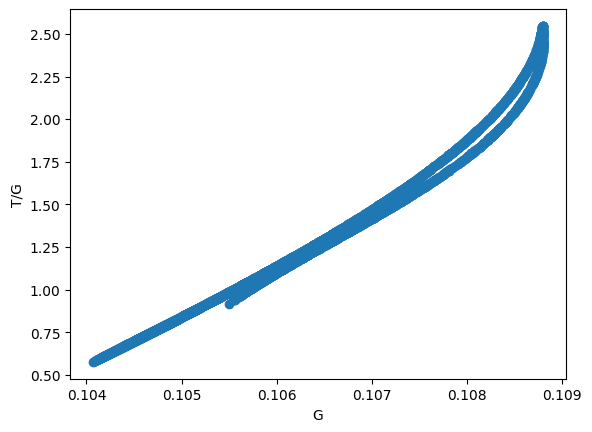

In [29]:
# budget = 1124
probs1_G = p1_G_sim3[10,:]
probs1_T = p1_T_sim3[10,:]
sorted_idx = np.argsort(probs1_T)
plt.scatter(probs1_G[sorted_idx], probs1_T[sorted_idx] / probs1_G[sorted_idx])
plt.xlabel("G")
plt.ylabel("T/G")
plt.show()

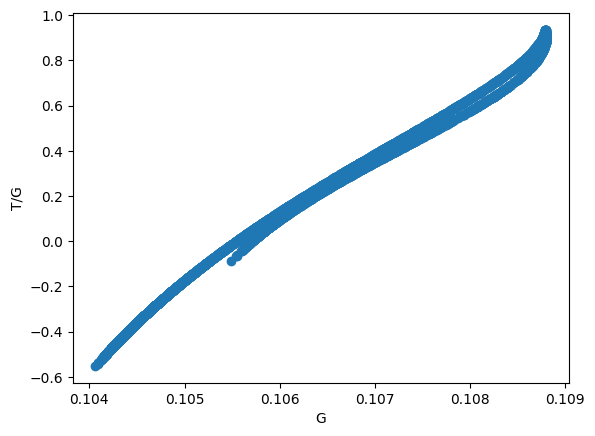

In [34]:
# budget = 1124
probs1_G = p1_G_sim3[10,:]
probs1_T = p1_T_sim3[10,:]
sorted_idx = np.argsort(probs1_T)
plt.scatter(probs1_G[sorted_idx], np.log(probs1_T[sorted_idx]/ probs1_G[sorted_idx]))
plt.xlabel("G")
plt.ylabel("T/G")
plt.show()

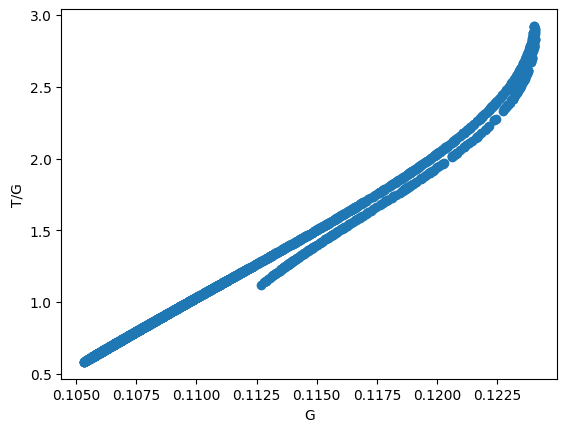

In [31]:
# budget = 1124
probs0_G = p0_G_sim3[10,:]
probs0_T = p0_T_sim3[10,:]
sorted_idx = np.argsort(probs0_G)
plt.scatter(probs0_G[sorted_idx], probs0_T[sorted_idx] / probs0_G[sorted_idx])
plt.xlabel("G")
plt.ylabel("T/G")
plt.show()

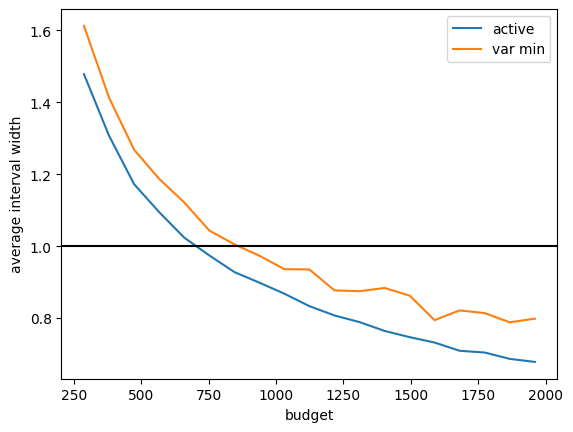

In [16]:
# analysis/summary of results
df_sim3_corrsampling['coverage'] = df_sim3_corrsampling['coverage'] * 1.0
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_b$']
active_df = df_sim3_corrsampling[(df_sim3_corrsampling["estimator"] == "active")][relevant_columns].groupby('$n_b$').mean()
varmin_df = df_sim3_corrsampling[(df_sim3_corrsampling["estimator"] == "var. min.")][relevant_columns].groupby('$n_b$').mean()
plt.plot(np.array(active_df.index)[1:], np.array(active_df["interval width"])[1:], label = "active")
plt.plot(np.array(varmin_df.index)[1:], np.array(varmin_df["interval width"])[1:], label = "var min")
plt.axhline(1, color= "black")
plt.xlabel("budget")
plt.ylabel("average interval width")
plt.legend()
plt.show()


In [18]:
varmin_df

,lb,ub,interval width,coverage
$n_b$,,,,
196.0,1.444980,3.566101,2.121121,0.908
288.0,1.537087,3.149819,1.612732,0.92
381.0,1.613513,3.026932,1.413418,0.916
474.0,1.636356,2.904602,1.268246,0.921
567.0,1.670473,2.857640,1.187168,0.907
660.0,1.677818,2.799357,1.121539,0.916
753.0,1.698516,2.741865,1.043349,0.921
846.0,1.723079,2.728003,1.004924,0.933
938.0,1.742441,2.715937,0.973496,0.916


In [17]:
active_df

,lb,ub,interval width,coverage
$n_b$,,,,
196.0,1.515757,3.304891,1.789134,0.891
288.0,1.592726,3.071215,1.478489,0.897
381.0,1.636551,2.943797,1.307246,0.915
474.0,1.667314,2.839694,1.172380,0.911
567.0,1.698270,2.792838,1.094568,0.918
660.0,1.713408,2.736948,1.023540,0.937
753.0,1.734599,2.708624,0.974025,0.935
846.0,1.750940,2.678674,0.927734,0.938
938.0,1.771173,2.669706,0.898533,0.936


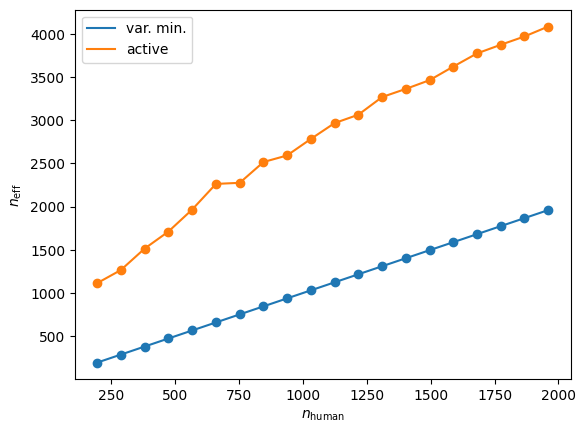

In [ ]:
classical_df = varmin_df = df_sim3_corrsampling[(df_sim3_corrsampling["estimator"] == "classical")][relevant_columns].groupby('$n_b$').mean()
n_baseline = np.array(classical_df.index) #classical
n_G = np.array((np.square(classical_df["interval width"] / varmin_df["interval width"]))) * n_baseline
n_T = np.array((np.square(classical_df["interval width"] / active_df["interval width"]))) * n_baseline
plt.plot(n_baseline, n_G, label = "var. min.")
plt.scatter(n_baseline, n_G)
plt.plot(n_baseline, n_T, label = "active")
plt.scatter(n_baseline, n_T)
plt.plot(n_baseline, n_baseline, label = "human")
plt.scatter(n_baseline, n_baseline)
plt.xlabel("$n_{\mathrm{human}}$")
plt.legend()
plt.ylabel("$n_{\mathrm{eff}}$")
plt.show()

In [16]:
# trying with much larger budget
#budgets = np.array([0.05, 0.1, 0.15, 0.2])
budgets = np.linspace(0.02, 0.2, 20)
#budget = 0.05
#fracs = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
#fracs = np.array([0.1, 0.2])
alpha = 0.1
num_trials = 1000
results = []
results_corrsampling = []
#columns = ["estimate", "lb", "ub", "interval width", "coverage", "estimator", "$n_b$"]
columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_{\mathrm{human}}$", "$n_{\mathrm{eff}}$"] # number labeled in group 1
#temp_df = pd.DataFrame(np.zeros((3, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
temp_df_corrsampling = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
temp_df = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
n = ce1_test.shape[0] + ce0_test.shape[0]
p1_G_sim6  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_G_sim6  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_T_sim6  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_T_sim6  = np.zeros((len(budgets), ce0_test.shape[0]))
match1 = np.zeros((len(budgets), num_trials))
match0 = np.zeros((len(budgets), num_trials))
match1_corrsampling = np.zeros((len(budgets), num_trials))
match0_corrsampling = np.zeros((len(budgets), num_trials))
tot_labelT = np.zeros((len(budgets), num_trials))
tot_labelG = np.zeros((len(budgets), num_trials))
tot_labelT_corrsampling = np.zeros((len(budgets), num_trials))
tot_labelG_corrsampling = np.zeros((len(budgets), num_trials))

for j in range(len(budgets)):
    budget = budgets[j]
    # active
    uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
    uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
    eta0 = budget / np.mean(uncertainty0)
    eta1 = budget / np.mean(uncertainty1)
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1

    p1_spline, p0_spline, v1, v0, a1, a0 = sampling_probs_spline(Yhat1_test, Yhat0_test, Yhat1_test, Yhat0_test, mu1_init, mu0_init, budget, 10)
    
    tau = 0.5
    p1_G_sim6[j, :] = np.clip(tau * p1_spline + (1-tau)*budget, 0, 1)
    p1_T_sim6[j, :] = np.clip(tau * p1_active + (1-tau)*budget, 0, 1)
    p0_G_sim6[j, :] = np.clip(tau * p0_spline + (1-tau)*budget, 0, 1)
    p0_T_sim6[j, :] = np.clip(tau * p0_active + (1-tau)*budget, 0, 1)
    for k in tqdm(range(num_trials)):
        l_A, u_A, v_A, p0_a, p1_a, label0_A, label1_A, l_S, u_S, v_S, p0_m, p1_m, label0_V, label1_V  = sample_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_active, p1_active, p0_spline, p1_spline, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l_A)*(OR_true <= u_A)   
        temp_df_corrsampling.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(budget*n), (true_var / v_A) * n 
        coverage_var = (OR_true >= l_S)*(OR_true <= u_S)   
        temp_df_corrsampling.loc[1] = l_S, u_S, u_S-l_S, coverage_var, "var. min.", int(budget*n), (true_var / v_S) * n  
        match1_corrsampling[j, k] = len(np.intersect1d(label1_A, label1_V))
        match0_corrsampling[j, k] = len(np.intersect1d(label0_A, label0_V))
        tot_labelT_corrsampling[j, k] = label1_A[0].shape[0] + label0_A[0].shape[0]
        tot_labelG_corrsampling[j, k] = label1_V[0].shape[0] + label0_V[0].shape[0]
        
        p1_unif, p0_unif = budget * np.ones(ce1_test.shape[0]), budget * np.ones(ce0_test.shape[0])
        l, u, v_unif, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        # temp_df.loc[2] = l, u, u-l, coverage_active, "uniform", int(budget*n), (true_var / v_unif) * n
        temp_df_corrsampling.loc[2] = l, u, u-l, coverage_active, "uniform", int(budget*n), (true_var / v_unif) * n  
        
        l, u, v_class, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=0, lhat1=0)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        #temp_df.loc[3] = l, u, u-l, coverage_active, "classical", int(budget*n)
        temp_df_corrsampling.loc[3] = l, u, u-l, coverage_active, "classical", int(budget*n), int(budget * n)  
        results += [temp_df.copy()]
        results_corrsampling += [temp_df_corrsampling.copy()]

        tot_labelT[j, k] = label1_A[0].shape[0] + label0_A[0].shape[0]
        tot_labelG[j, k] = label1_V[0].shape[0] + label0_V[0].shape[0]
df_sim9 = pd.concat(results, ignore_index = True)
df_sim9_corrsampling = pd.concat(results_corrsampling, ignore_index = True)

100%|██████████| 1000/1000 [00:03<00:00, 269.00it/s]


In [30]:
df_sim9_corrsampling["coverage"] = df_sim9_corrsampling["coverage"] * 1.0

In [31]:
active_df = df_sim9_corrsampling[df_sim9_corrsampling["estimator"] == "active"]


In [33]:
print(active_df.columns)
print(active_df.select_dtypes(include=['float64']).head())  # Check any that may be problematic

Index(['lb', 'ub', 'interval width', 'coverage', 'estimator',
       '$n_{\mathrm{human}}$', '$n_{\mathrm{eff}}$'],
      dtype='object')
          lb        ub  interval width  coverage  $n_{\mathrm{human}}$  \
0   1.535253  3.576834        2.041582       1.0                 196.0   
4   1.718033  3.009481        1.291448       1.0                 196.0   
8   1.187684  2.398732        1.211047       1.0                 196.0   
12  0.925619  2.040343        1.114723       0.0                 196.0   
16  1.498212  3.205202        1.706990       1.0                 196.0   

    $n_{\mathrm{eff}}$  
0           481.865423  
4          1096.874137  
8           697.611969  
12          551.745958  
16          595.994707  


In [38]:
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_{\mathrm{eff}}$', '$n_{\mathrm{human}}$']
active_df_subset = active_df[relevant_columns]
active_df_grouped = active_df_subset.groupby('$n_{\mathrm{human}}$').mean()

In [39]:
active_df_grouped

,lb,ub,interval width,coverage,$n_{\mathrm{eff}}$
$n_{\mathrm{human}}$,,,,,
196.0,1.532588,3.293861,1.761274,0.905,615.854598
288.0,1.615343,3.055303,1.439960,0.884,875.567742
381.0,1.661296,2.919718,1.258422,0.908,1107.714041
474.0,1.694352,2.816018,1.121666,0.898,1357.047301
567.0,1.725051,2.762783,1.037733,0.906,1574.211600
660.0,1.737288,2.696878,0.959590,0.917,1800.428390
753.0,1.763132,2.673932,0.910800,0.932,2003.946414
846.0,1.786722,2.654308,0.867585,0.935,2214.877076
938.0,1.781978,2.604081,0.822103,0.932,2410.228471


In [41]:
df_sim9_corrsampling['coverage'] = df_sim9_corrsampling['coverage'] * 1.0
relevant_columns = ['lb', 'ub', 'interval width', 'coverage', '$n_{\mathrm{eff}}$', '$n_{\mathrm{human}}$']
active_df = df_sim9_corrsampling[(df_sim9_corrsampling["estimator"] == "active")][relevant_columns].groupby('$n_{\mathrm{human}}$').mean()
varmin_df = df_sim9_corrsampling[(df_sim9_corrsampling["estimator"] == "var. min.")][relevant_columns].groupby('$n_{\mathrm{human}}$').mean()

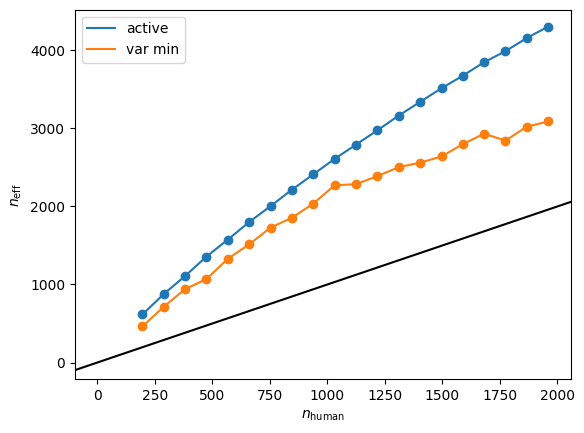

In [44]:
plt.plot(np.array(active_df.index), np.array(active_df["$n_{\mathrm{eff}}$"]), label = "active")
plt.scatter(np.array(active_df.index), np.array(active_df["$n_{\mathrm{eff}}$"]))
plt.plot(np.array(varmin_df.index), np.array(varmin_df["$n_{\mathrm{eff}}$"]), label = "var min")
plt.scatter(np.array(varmin_df.index), np.array(varmin_df["$n_{\mathrm{eff}}$"]))
plt.axline((0,0), slope = 1, color = "black")
plt.xlabel("$n_{\mathrm{human}}$")
plt.ylabel("$n_{\mathrm{eff}}$")
plt.legend()
plt.show()

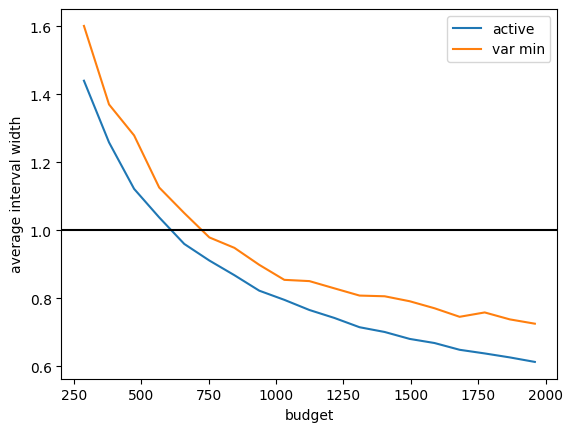

In [43]:
plt.plot(np.array(active_df.index)[1:], np.array(active_df["interval width"])[1:], label = "active")
plt.plot(np.array(varmin_df.index)[1:], np.array(varmin_df["interval width"])[1:], label = "var min")
plt.axhline(1, color= "black")
plt.xlabel("budget")
plt.ylabel("average interval width")
plt.legend()
plt.show()

In [40]:
# trying with much larger budget
budgets = np.array([0.05, 0.1, 0.15, 0.2])
#budget = 0.05
#fracs = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
#fracs = np.array([0.1, 0.2])
alpha = 0.1
num_trials = 1000
results = []
results_corrsampling = []
#columns = ["estimate", "lb", "ub", "interval width", "coverage", "estimator", "$n_b$"]
columns = ["lb", "ub", "interval width", "coverage", "estimator", "$n_b$"] # number labeled in group 1
#temp_df = pd.DataFrame(np.zeros((3, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
temp_df_corrsampling = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
#temp_df = pd.DataFrame(np.zeros((4, len(columns))), columns = columns) # active inference vs optimal sampling vs uniform sampling rule
n = ce1_test.shape[0] + ce0_test.shape[0]
p1_G_sim4  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_G_sim4  = np.zeros((len(budgets), ce0_test.shape[0]))
p1_T_sim4  = np.zeros((len(budgets), ce1_test.shape[0]))
p0_T_sim4  = np.zeros((len(budgets), ce0_test.shape[0]))
match1 = np.zeros((len(budgets), num_trials))
match0 = np.zeros((len(budgets), num_trials))
match1_corrsampling = np.zeros((len(budgets), num_trials))
match0_corrsampling = np.zeros((len(budgets), num_trials))
tot_labelT = np.zeros((len(budgets), num_trials))
tot_labelG = np.zeros((len(budgets), num_trials))
tot_labelT_corrsampling = np.zeros((len(budgets), num_trials))
tot_labelG_corrsampling = np.zeros((len(budgets), num_trials))

for j in range(len(budgets)):
    budget = budgets[j]
    # active
    uncertainty0 = np.minimum(Yhat0_test, 1-Yhat0_test)
    uncertainty1 = np.minimum(Yhat1_test, 1-Yhat1_test)
    #uncertainty = np.minimum(Yhat_test, 1  - Yhat_test)
    #eta = budget / np.mean(uncertainty)
    eta0 = budget / np.mean(uncertainty0)
    eta1 = budget / np.mean(uncertainty1)
    p0_active = eta0 * uncertainty0
    p1_active = eta1 * uncertainty1
    #p0_active = eta * uncertainty[Z_test == 0]
    #p1_active = eta * uncertainty[Z_test == 1]
    

    p1_spline, p0_spline, v1, v0, a1, a0 = sampling_probs_spline(ce1_test, ce0_test, Yhat1_test, Yhat0_test, mu1_init, mu0_init, budget, 10)
    
    tau = 0.5
    p1_G_sim4[j, :] = np.clip(tau * p1_spline + (1-tau)*budget, 0, 1)
    p1_T_sim4[j, :] = np.clip(tau * p1_active + (1-tau)*budget, 0, 1)
    p0_G_sim4[j, :] = np.clip(tau * p0_spline + (1-tau)*budget, 0, 1)
    p0_T_sim4[j, :] = np.clip(tau * p0_active + (1-tau)*budget, 0, 1)
    for k in tqdm(range(num_trials)):
        l_A, u_A, p0_a, p1_a, label0_A, label1_A, l_S, u_S, p0_m, p1_m, label0_V, label1_V  = sample_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_active, p1_active, p0_spline, p1_spline, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l_A)*(OR_true <= u_A)   
        temp_df_corrsampling.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(budget*n)  
        coverage_var = (OR_true >= l_S)*(OR_true <= u_S)   
        temp_df_corrsampling.loc[1] = l_S, u_S, u_S-l_S, coverage_var, "var. min.", int(budget*n)  
        match1_corrsampling[j, k] = len(np.intersect1d(label1_A, label1_V))
        match0_corrsampling[j, k] = len(np.intersect1d(label0_A, label0_V))
        tot_labelT_corrsampling[j, k] = label1_A[0].shape[0] + label0_A[0].shape[0]
        tot_labelG_corrsampling[j, k] = label1_V[0].shape[0] + label0_V[0].shape[0]

        # l_A, u_A, p0_a, p1_a, label0_A, label1_A = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_active, p1_active, alpha, budget, lhat0=1, lhat1=1)
        # l_S, u_S, p0_linear, p1_linear, label0_S, label1_S = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_spline, p1_spline, alpha, budget, lhat0=1, lhat1=1)
        # coverage_active = (OR_true >= l_A)*(OR_true <= u_A)   
        # temp_df.loc[0] = l_A, u_A, u_A-l_A, coverage_active, "active", int(budget*n)  
        # coverage_var = (OR_true >= l_S)*(OR_true <= u_S)   
        # temp_df.loc[1] = l_S, u_S, u_S-l_S, coverage_var, "var. min.", int(budget*n)  
        # match1[j, k] = len(np.intersect1d(label1_A, label1_V))
        # match0[j, k] = len(np.intersect1d(label0_A, label0_V))
        
        p1_unif, p0_unif = budget * np.ones(ce1_test.shape[0]), budget * np.ones(ce0_test.shape[0])
        l, u, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=1, lhat1=1)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        #temp_df.loc[2] = l, u, u-l, coverage_active, "uniform", int(budget*n)
        temp_df_corrsampling.loc[2] = l, u, u-l, coverage_active, "uniform", int(budget*n)  
        
        l, u, p0_unif, p1_unif, label0, label1 = odds_ratio_ci(Y0_test.ravel(), Yhat0_test, Y1_test.ravel(), Yhat1_test, p0_unif, p1_unif, alpha, budget, lhat0=0, lhat1=0)
        coverage_active = (OR_true >= l)*(OR_true <= u)   
        #temp_df.loc[3] = l, u, u-l, coverage_active, "classical", int(budget*n)
        temp_df_corrsampling.loc[3] = l, u, u-l, coverage_active, "classical", int(budget*n)  
        #results += [temp_df.copy()]
        results_corrsampling += [temp_df_corrsampling.copy()]

        tot_labelT[j, k] = label1_A[0].shape[0] + label0_A[0].shape[0]
        tot_labelG[j, k] = label1_V[0].shape[0] + label0_V[0].shape[0]
        
        #if ((k+1) % 10) == 0:
            #clear_output(wait=True)
            #print(f"Finished Iteration {k + 1}")
#df_sim4 = pd.concat(results, ignore_index = True)
df_sim4_corrsampling = pd.concat(results_corrsampling, ignore_index = True)

100%|██████████| 1000/1000 [00:03<00:00, 295.12it/s]


In [52]:
df_sim4_corrsampling.shape #(4 x 4 x 1000)

(16000, 6)

In [41]:
# separate problems
# analysis/summary of results
#df_sim4['coverage'] = pd.to_numeric(df_sim4['coverage'], errors = 'coerce')
df_sim4_corrsampling['coverage'] = pd.to_numeric(df_sim4_corrsampling['coverage'], errors = 'coerce')

df_sim4_corrsampling[(df_sim4_corrsampling["estimator"] == "active")].groupby('$n_b$').mean()

,lb,ub,interval width,coverage
$n_b$,,,,
490.0,1.660461,2.743045,1.082584,0.918
980.0,1.773618,2.569839,0.796221,0.942
1470.0,1.816059,2.487053,0.670993,0.963
1960.0,1.838640,2.436667,0.598027,0.960


In [42]:
df_sim4_corrsampling[(df_sim4_corrsampling["estimator"] == "var. min.")].groupby('$n_b$').mean()

,lb,ub,interval width,coverage
$n_b$,,,,
490.0,1.636143,2.798765,1.162622,0.924
980.0,1.757323,2.602544,0.845221,0.937
1470.0,1.784468,2.545590,0.761123,0.943
1960.0,1.805870,2.476482,0.670611,0.943


In [ ]:
# combined uncertainties
# analysis/summary of results
#df_sim4['coverage'] = pd.to_numeric(df_sim4['coverage'], errors = 'coerce')
df_sim4_corrsampling['coverage'] = pd.to_numeric(df_sim4_corrsampling['coverage'], errors = 'coerce')

df_sim4_corrsampling[(df_sim4_corrsampling["estimator"] == "active")].groupby('$n_b$').mean()

,lb,ub,interval width,coverage
$n_b$,,,,
490.0,1.655743,2.772142,1.116399,0.918
980.0,1.773088,2.591836,0.818748,0.922
1470.0,1.813778,2.500861,0.687083,0.943
1960.0,1.838002,2.449888,0.611886,0.970


In [24]:
df_sim4_corrsampling[(df_sim4_corrsampling["estimator"] == "var. min.")].groupby('$n_b$').mean()

,lb,ub,interval width,coverage
$n_b$,,,,
490.0,1.642068,2.804857,1.162789,0.921
980.0,1.759030,2.604649,0.845619,0.933
1470.0,1.788281,2.552394,0.764113,0.955
1960.0,1.814634,2.488276,0.673642,0.968


# labeled from group 1: 490.0


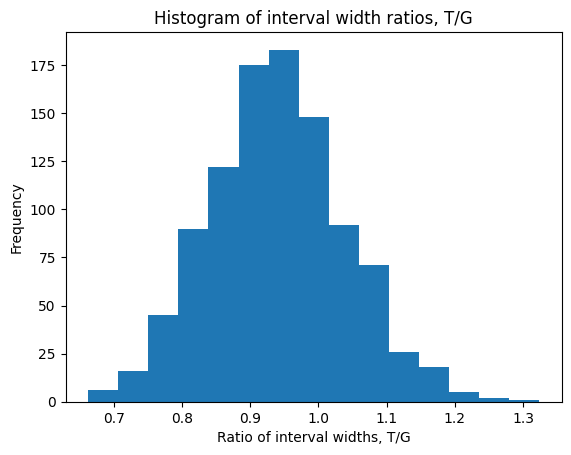

Avg ratio: 0.9400777978282818
Frac => 1: 0.253
# labeled from group 1: 980.0


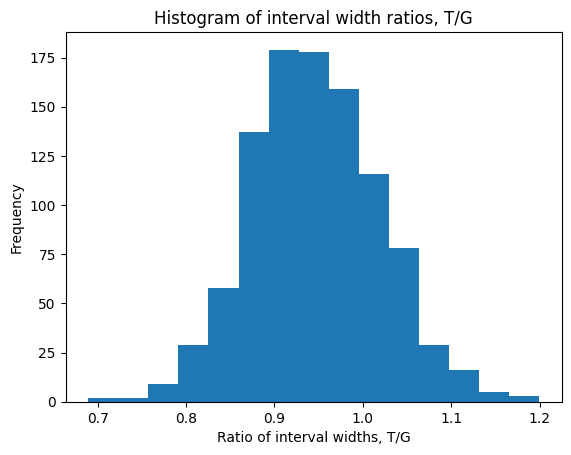

Avg ratio: 0.9465590623829555
Frac => 1: 0.233
# labeled from group 1: 1470.0


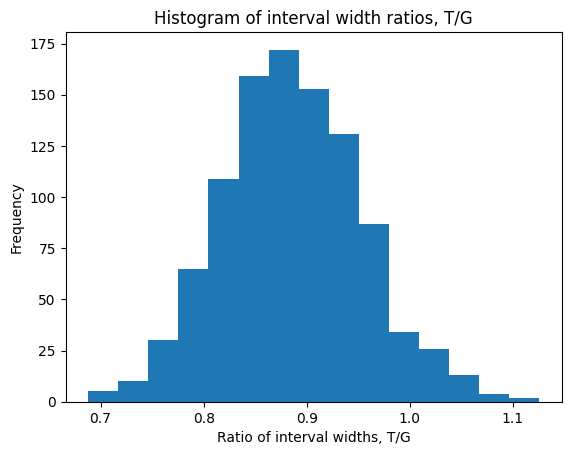

Avg ratio: 0.8862412934859838
Frac => 1: 0.057
# labeled from group 1: 1960.0


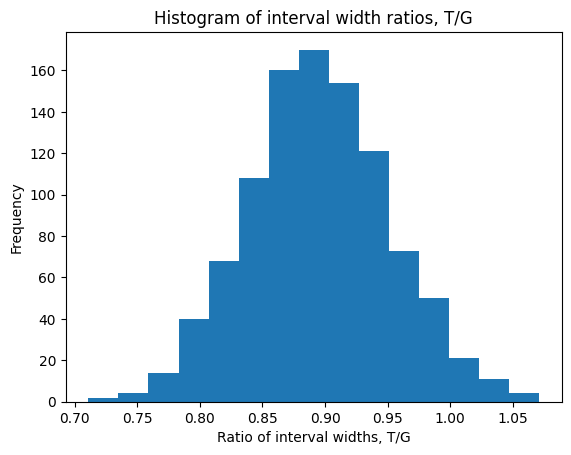

Avg ratio: 0.8953217866502926
Frac => 1: 0.036


In [43]:
for n in np.unique(df_sim4_corrsampling['$n_b$']):
    active_widths = df_sim4_corrsampling[df_sim4_corrsampling["estimator"] == "active"][df_sim4_corrsampling['$n_b$'] == n]["interval width"]
    varmin_widths = df_sim4_corrsampling[df_sim4_corrsampling["estimator"] == "var. min."][df_sim4_corrsampling['$n_b$'] == n]["interval width"]
    ratio_widths = np.array(np.round(active_widths, 4)) / np.array(np.round(varmin_widths, 4))
    plt.hist(ratio_widths, bins = 15)
    plt.xlabel("Ratio of interval widths, T/G")
    plt.ylabel("Frequency")
    plt.title("Histogram of interval width ratios, T/G")
    print(f"# labeled from group 1: {n}")
    plt.show()
    print(f"Avg ratio: {np.mean(ratio_widths)}")
    print(f"Frac => 1: {np.mean(ratio_widths >= 1)}")

# labeled from group 1: 490.0


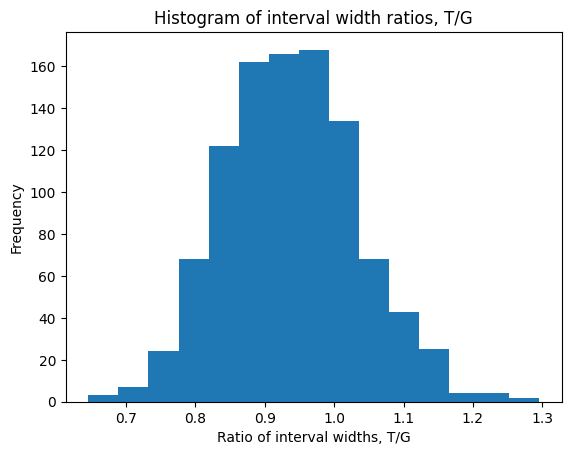

Avg ratio: 0.93804333380029
Frac => 1: 0.252
# labeled from group 1: 980.0


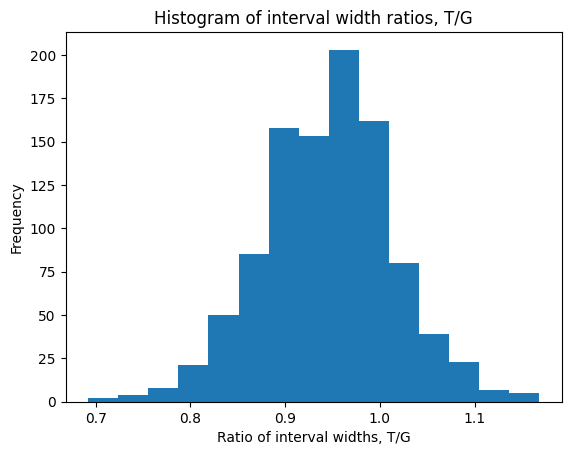

Avg ratio: 0.9454053008059339
Frac => 1: 0.2
# labeled from group 1: 1470.0


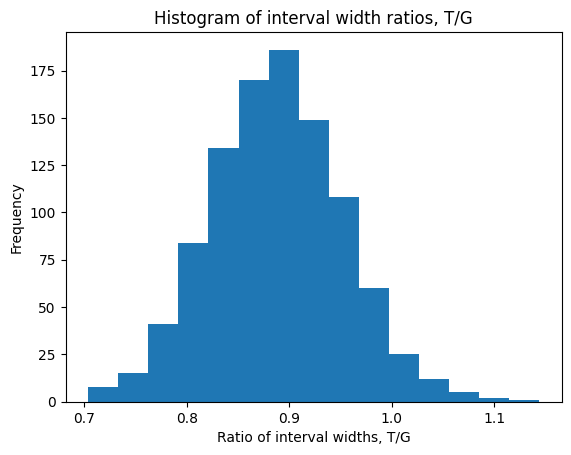

Avg ratio: 0.8876083241305356
Frac => 1: 0.042
# labeled from group 1: 1960.0


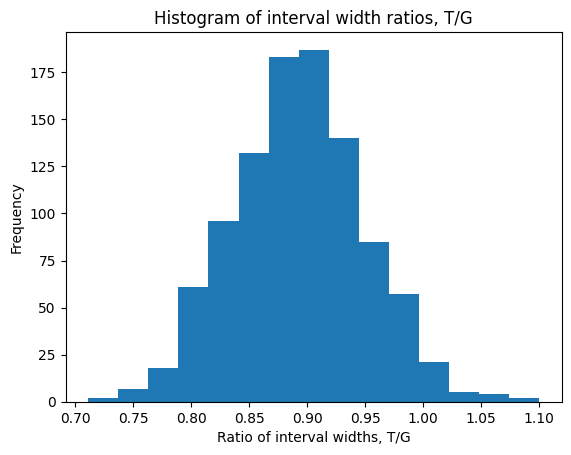

Avg ratio: 0.8929665641417159
Frac => 1: 0.03


In [29]:
for n in np.unique(df_sim4_corrsampling['$n_b$']):
    active_widths = df_sim4_corrsampling[df_sim4_corrsampling["estimator"] == "active"][df_sim4_corrsampling['$n_b$'] == n]["interval width"]
    varmin_widths = df_sim4_corrsampling[df_sim4_corrsampling["estimator"] == "var. min."][df_sim4_corrsampling['$n_b$'] == n]["interval width"]
    ratio_widths = np.array(np.round(active_widths, 4)) / np.array(np.round(varmin_widths, 4))
    #print(active_widths.shape)
    plt.hist(ratio_widths, bins = 15)
    # active_df = df_sim4_corrsampling[
    # (df_sim4_corrsampling["estimator"] == "active") & 
    # (df_sim4_corrsampling['$n_b$'] == n) &
    # (df_sim4_corrsampling["interval width"] <= 50)
    # ].reset_index(drop=True)
    # var_df = df_sim4_corrsampling[
    #     (df_sim4_corrsampling["estimator"] == "var. min.") & 
    #     (df_sim4_corrsampling['$n_b$'] == n)
    # ].reset_index(drop=True)
    # var_df = var_df.iloc[active_df.index]
    # ratio_widths = active_df["interval width"].values / var_df["interval width"].values
    # plt.hist(ratio_widths)
    plt.xlabel("Ratio of interval widths, T/G")
    plt.ylabel("Frequency")
    plt.title("Histogram of interval width ratios, T/G")
    print(f"# labeled from group 1: {n}")
    plt.show()
    print(f"Avg ratio: {np.mean(ratio_widths)}")
    print(f"Frac => 1: {np.mean(ratio_widths >= 1)}")

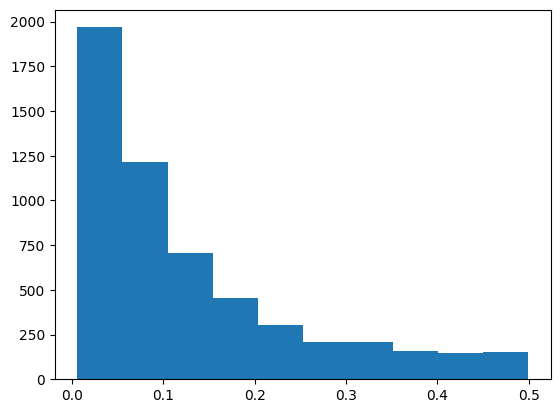

In [30]:
plt.hist(np.minimum(Yhat1_test, 1 - Yhat1_test))
plt.show()

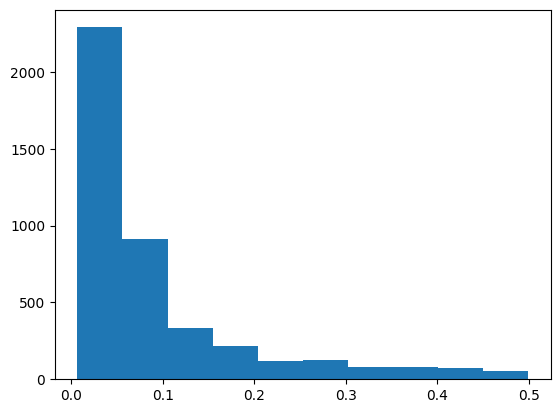

In [31]:
plt.hist(np.minimum(Yhat0_test, 1 - Yhat0_test))
plt.show()

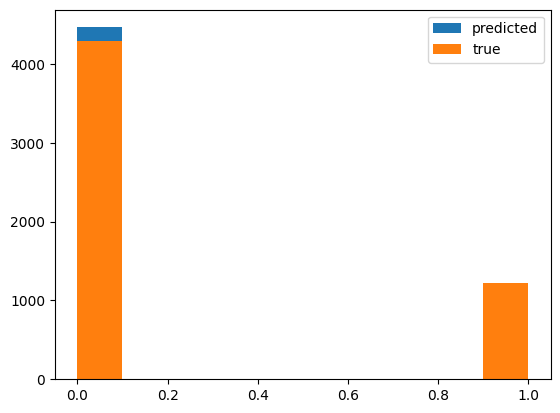

In [32]:
plt.hist((Yhat1_test > 0.5) * 1, label = "predicted")
plt.hist(Y1_test, label = "true")
plt.legend()
plt.show()

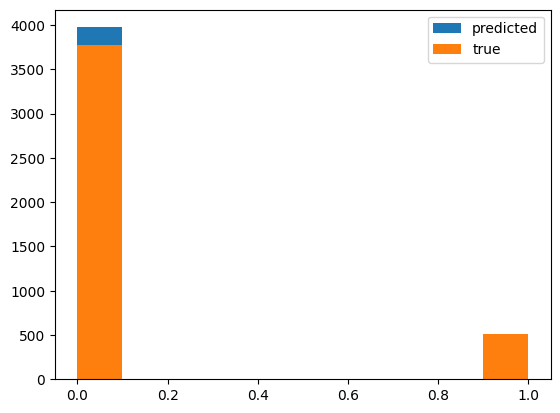

In [33]:
plt.hist((Yhat0_test > 0.5) * 1, label = "predicted")
plt.hist(Y0_test, label = "true")
plt.legend()
plt.show()

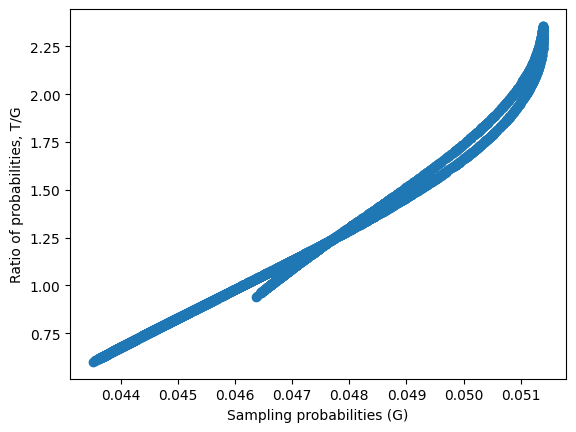

0.5921696574225123


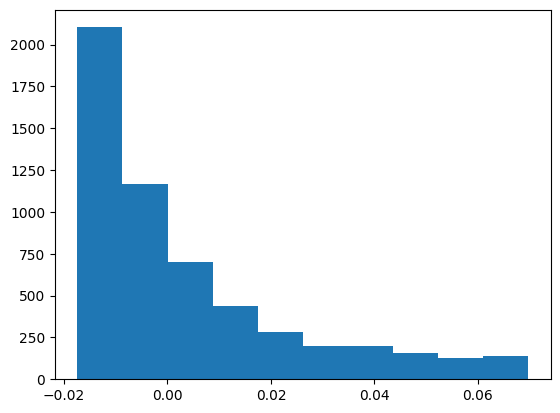

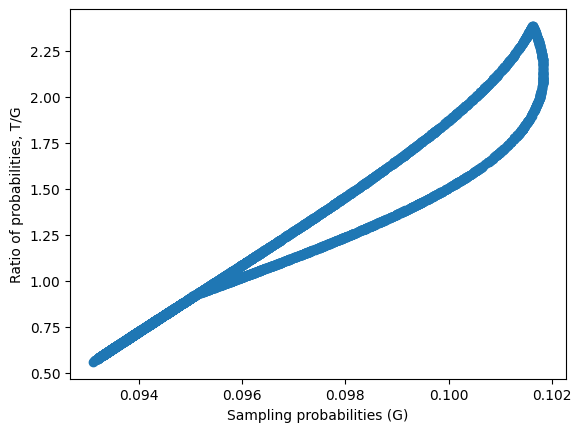

0.6173645096972993


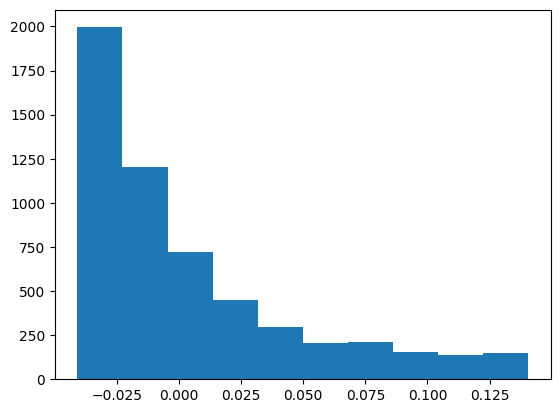

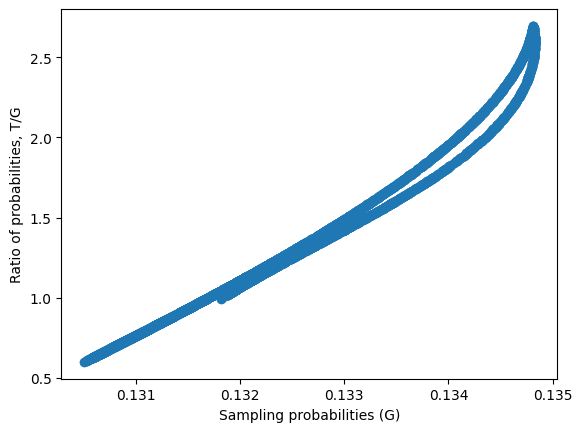

0.5635309044770709


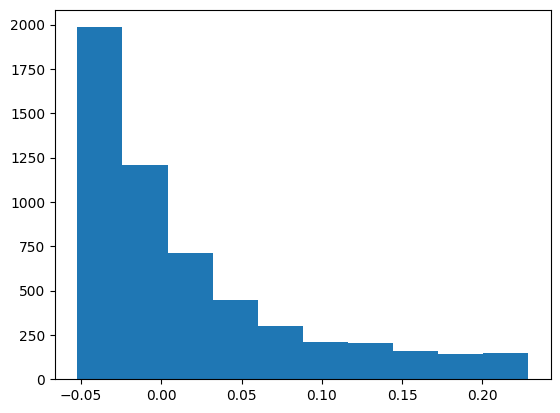

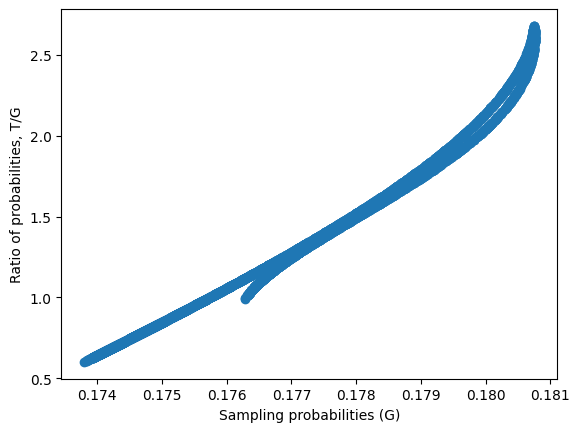

0.5638934203371397


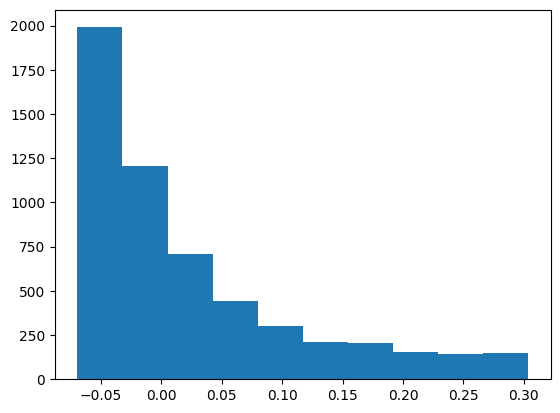

In [34]:
for i in range(p1_G_sim4.shape[0]):
    ratio_probs = p1_T_sim4[i, :] / p1_G_sim4[i, :]
    plt.scatter(p1_G_sim4[i, :], ratio_probs)
    plt.xlabel("Sampling probabilities (G)")
    plt.ylabel("Ratio of probabilities, T/G")
    #plt.title("Histogram of interval width ratios, T/G")
    #plt.hist(df[df["estimator"] == "active"]["interval width"], label = "active")
    #plt.hist(df[df["estimator"] == "var. min."]["interval width"], label = "var. min.")
    #plt.hist(df[df["estimator"] == "uniform"]["interval width"], label = "uniform")
    #plt.legend()
    #print(f"# labeled: {n}")
    plt.show()
    print(np.mean(ratio_probs < 1))
    plt.hist(p1_T_sim4[i, :] - p1_G_sim4[i, :])
    plt.show()
    #print(f"Frac > 1: {np.mean(ratio_widths > 1)}")

### Monte Carlo Variance estimation

#### Functions

In [35]:
def cond_exp(X, Z):
    Z1_part = np.multiply(Z, 1 / (1 + np.exp(-1.5 * X)))
    X_scaled = X * (1 - Z) / 2
    # Add moderate variations around the base probability
    variations = (0.08 * np.sin(3 * X_scaled)**2 * np.cos(2 * X_scaled) + 
                 0.05 * np.sin(5 * X_scaled) + 
                 0.03 * np.cos(7 * X_scaled))
    prob = 0.1 + variations
    prob = prob + 0.1 * (((X * (1 - Z)) > 1) & ((X * (1 - Z)) < 2))
    Z0_part = np.multiply(1 - Z, np.clip(prob, 0.02, 0.25))
    return Z0_part + Z1_part

In [36]:
def pi_G(ce1, ce0, preds1, preds0, n_spline):
    p1, p0, v1, v0, a1, a0 = sampling_probs_spline(ce1, ce0, preds1, preds0, mu1_true, mu0_true, budget, n_spline)
    return p1, p0

In [37]:
def pi_T(preds):
    #true_uncertainty = np.minimum(true_CE, 1 - true_CE)
    #true_eta1 = budget / np.mean(true_uncertainty[Z_samp == 1])
    #true_eta0 = budget / np.mean(true_uncertainty[Z_samp == 0])
    #true_p1_active = true_eta1 * true_uncertainty[Z_samp == 1]
    #true_p0_active = true_eta0 * true_uncertainty[Z_samp == 0]
    eta = budget / np.mean(preds)
    return eta * preds

In [16]:
# Single-run variance estimation
#setting = 1, 2, 3 (1 = true values, 2 = 1000 samples, 3 = 100 samples)
def single_run_variance(f, f1, f0, pi_G, pi_T, setting, tau, n_samples=10000):
    X, Y, Z = generate_uneven_data(n_samples)
    n1 = np.sum(Z == 1)
    n0 = np.sum(Z == 0)
    fX1 = f.predict_proba(np.column_stack([X[Z == 1], np.ones(n1)]))[:, 1]
    fX0 = f.predict_proba(np.column_stack([X[Z == 0], np.zeros(n0)]))[:, 1]
    n_spline = 10
    if setting > 1:
        # Compute terms
        ce1 = f1.predict_proba(np.column_stack([X[Z == 1], np.ones(n1)]))[:,1]
        ce0 = f0.predict_proba(np.column_stack([X[Z == 0], np.zeros(n0)]))[:,1]
        piX1, piX0 = pi_G(ce1, ce0, fX1, fX0, n_spline)
        piX1 = tau * piX1 + (1 - tau) * budget
        piX0 = tau * piX0 + (1 - tau) * budget
        pi_active1 = tau * pi_T(fX1) + (1 - tau) * budget
        pi_active0 = tau * pi_T(fX0) + (1 - tau) * budget
    else: #aka setting is 1
        true_CE = cond_exp(X, Z)
        piX1, piX0 = pi_G(true_CE[Z == 1], true_CE[Z == 0], true_CE[Z == 1], true_CE[Z == 0], n_spline)
        piX1 = tau * piX1 + (1 - tau) * budget
        piX0 = tau * piX0 + (1 - tau) * budget
        #piX1 = tau * pi_G(true_CE[Z == 1], n_spline, alpha1) + (1 - tau) * budget
        #piX0 = tau * pi_G(true_CE[Z == 0], n_spline, alpha0) + (1 - tau) * budget
        pi_active1 = tau * pi_T(true_CE[Z == 1]) + (1 - tau) * budget
        pi_active0 = tau * pi_T(true_CE[Z == 0]) + (1 - tau) * budget
    residuals_squared1 = (Y[Z == 1] - fX1) ** 2    
    residuals_squared0 = (Y[Z == 0] - fX0) ** 2
    var_Y_given_Z1 = np.var(Y[Z == 1], ddof=1)
    E_residuals_sq_given_Z1 = np.mean(residuals_squared1)
    E_residuals_sq_over_pi_given_Z1_G = np.mean(residuals_squared1 / piX1)
    
    var_Y_given_Z0 = np.var(Y[Z == 0], ddof = 1)
    E_residuals_sq_given_Z0 = np.mean(residuals_squared0)
    E_residuals_sq_over_pi_given_Z0_G = np.mean(residuals_squared0 / piX0)

    v1_G = var_Y_given_Z1 - E_residuals_sq_given_Z1 + E_residuals_sq_over_pi_given_Z1_G 
    v0_G = var_Y_given_Z0 - E_residuals_sq_given_Z0 + E_residuals_sq_over_pi_given_Z0_G
    v_G = v1_G / (n1 * (mu1_true * (1 - mu1_true))**2) + v0_G / (n0 * (mu0_true * (1 - mu0_true))**2)

    E_residuals_sq_over_pi_given_Z1_T = np.mean(residuals_squared1 / pi_active1)
    E_residuals_sq_over_pi_given_Z0_T = np.mean(residuals_squared0 / pi_active0)
    v1_T = var_Y_given_Z1 - E_residuals_sq_given_Z1 + E_residuals_sq_over_pi_given_Z1_T
    v0_T = var_Y_given_Z0 - E_residuals_sq_given_Z0 + E_residuals_sq_over_pi_given_Z0_T
    v_T = v1_T / (n1 * (mu1_true * (1 - mu1_true))**2) + v0_T / (n0 * (mu0_true * (1 - mu0_true))**2)

    return v_G, v_T

# Monte Carlo Estimation
def monte_carlo_asymptotic_variance(f, f1, f0, pi_G, pi_T, setting, tau, n_runs=100, n_samples=10000):
    estimates = np.array([single_run_variance(f, f1, f0, pi_G, pi_T, setting, tau, n_samples) for _ in tqdm(range(n_runs))])
    return np.mean(estimates[:, 0]), np.std(estimates[:, 0]) / np.sqrt(n_runs), np.mean(estimates[:, 1]), np.std(estimates[:, 1])  # Mean and standard error


#### First results

In [17]:
# using true conditional expectation to get the appropriate sampling probabilities; Ginnie's
budget = 0.1
mean_varG, std_errG, mean_varT, std_errT = monte_carlo_asymptotic_variance(model, model, model, pi_G, pi_T, setting = 2, tau = 0.5, n_runs=100, n_samples=10000)

100%|██████████| 100/100 [05:06<00:00,  3.07s/it]


In [18]:
# knowing true conditional expectation
mean_varG, std_errG, mean_varT, std_errT
    

(0.06913936546604782,
 0.000537451826194901,
 0.0956082754631557,
 0.0058033883842281)

In [19]:
z = norm.ppf(1-alpha/2)
width_G = np.exp(z * np.sqrt(mean_varG)) - np.exp(-z * np.sqrt(mean_varG))
width_T = np.exp(z * np.sqrt(mean_varT)) - np.exp(-z * np.sqrt(mean_varT))
width_T/width_G

1.189852564541239

In [20]:
# using true conditional expectation to get the appropriate sampling probabilities; Ginnie's
budget = 0.05
mean_varG, std_errG, mean_varT, std_errT = monte_carlo_asymptotic_variance(model, model, model, pi_G, pi_T, setting = 2, tau = 0.5, n_runs=100, n_samples=10000)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [05:48<00:00,  3.49s/it]


In [21]:
# knowing true conditional expectation
mean_varG, std_errG, mean_varT, std_errT
    

(0.1307269000098697,
 0.000868474141196837,
 0.19425204196020981,
 0.011323856313207621)

In [22]:
z = norm.ppf(1-alpha/2)
width_G = np.exp(z * np.sqrt(mean_varG)) - np.exp(-z * np.sqrt(mean_varG))
width_T = np.exp(z * np.sqrt(mean_varT)) - np.exp(-z * np.sqrt(mean_varT))
width_T/width_G

1.2534034115757668

In [23]:
# using true conditional expectation to get the appropriate sampling probabilities; Ginnie's
budget = 0.15
mean_varG, std_errG, mean_varT, std_errT = monte_carlo_asymptotic_variance(model, model, model, pi_G, pi_T, setting = 2, tau = 0.5, n_runs=100, n_samples=10000)

100%|██████████| 100/100 [05:06<00:00,  3.07s/it]


In [24]:
mean_varG, std_errG, mean_varT, std_errT


(0.04987455981737679,
 0.00048220257242467406,
 0.06171321318575699,
 0.0038122174889224166)

In [25]:
z = norm.ppf(1-alpha/2)
width_G = np.exp(z * np.sqrt(mean_varG)) - np.exp(-z * np.sqrt(mean_varG))
width_T = np.exp(z * np.sqrt(mean_varT)) - np.exp(-z * np.sqrt(mean_varT))
width_T/width_G

1.118265560633933

In [41]:
# using true conditional expectation to get the appropriate sampling probabilities; Ginnie's
budget = 0.1
mean_varG, std_errG, mean_varT, std_errT = monte_carlo_asymptotic_variance(model, model, model, pi_G, pi_T, setting = 1, tau = 0.5, n_runs=1, n_samples=10000)



100%|██████████| 1/1 [00:03<00:00,  3.57s/it]


In [42]:
mean_varG, std_errG, mean_varT, std_errT


(0.1135248921767265, 0.0, 0.13349866932815097, 0.0)

In [43]:
z = norm.ppf(1-alpha/2)
width_G = np.exp(z * np.sqrt(mean_varG)) - np.exp(-z * np.sqrt(mean_varG))
width_T = np.exp(z * np.sqrt(mean_varT)) - np.exp(-z * np.sqrt(mean_varT))
width_T/width_G

1.0940067663469297

#### (n = 50) Estimated uncertainty

In [48]:
n_tr = 50
cov_train, cov_test, Y_train, Y_test = train_test_split(X_with_Z, Y, train_size=n_tr, random_state=42)
Z_train, Z_test = cov_train[:, 1], cov_test[:, 1]
X_train, X_test = cov_train[:, 0], cov_test[:, 0]
mu1_init = np.mean(Y_train[Z_train==1])
mu0_init = np.mean(Y_train[Z_train==0])
Y1_test = Y_test[Z_test == 1]
Y0_test = Y_test[Z_test == 0]
model = LogisticRegression(random_state = 0).fit(cov_train, Y_train)

In [49]:
budget = 0.1
mean_varG, std_errG, mean_varT, std_errT = monte_carlo_asymptotic_variance(model, model, model, pi_G, pi_T, setting = 2, tau = 0.5, n_runs=100, n_samples=10000)

100%|██████████| 100/100 [05:32<00:00,  3.33s/it]


In [51]:
mean_varG, std_errG, mean_varT, std_errT


(0.06504260816557168,
 0.0006590706735677908,
 0.1085085368809294,
 0.005238063622619638)

In [52]:
z = norm.ppf(1-alpha/2)
width_G = np.exp(z * np.sqrt(mean_varG)) - np.exp(-z * np.sqrt(mean_varG))
width_T = np.exp(z * np.sqrt(mean_varT)) - np.exp(-z * np.sqrt(mean_varT))
width_T/width_G

1.3167848356981984

#### (n = 1000) Estimated uncertainty 

In [44]:
n_tr = 1000
cov_train, cov_test, Y_train, Y_test = train_test_split(X_with_Z, Y, train_size=n_tr, random_state=42)
Z_train, Z_test = cov_train[:, 1], cov_test[:, 1]
X_train, X_test = cov_train[:, 0], cov_test[:, 0]
mu1_init = np.mean(Y_train[Z_train==1])
mu0_init = np.mean(Y_train[Z_train==0])
Y1_test = Y_test[Z_test == 1]
Y0_test = Y_test[Z_test == 0]
model = LogisticRegression(random_state = 0).fit(cov_train, Y_train)

In [45]:
budget = 0.1
mean_varG, std_errG, mean_varT, std_errT = monte_carlo_asymptotic_variance(model, model, model, pi_G, pi_T, setting = 2, tau = 0.5, n_runs=50, n_samples=10000)





















































  0%|          | 0/1 [04:37<?, ?it/s]


















































100%|██████████| 50/50 [02:33<00:00,  3.07s/it]


In [46]:
mean_varG, std_errG, mean_varT, std_errT

(0.06196432142384803,
 0.0007721980556788789,
 0.09809101689994773,
 0.0066940811067549046)

In [47]:
z = norm.ppf(1-alpha/2)
width_G = np.exp(z * np.sqrt(mean_varG)) - np.exp(-z * np.sqrt(mean_varG))
width_T = np.exp(z * np.sqrt(mean_varT)) - np.exp(-z * np.sqrt(mean_varT))
width_T/width_G

1.2785525094670958